In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from itertools import cycle
from scipy import stats

In [2]:
file_name = "_Results.pickle"

# 01.medgemma-4b-it

In [3]:
df_old_4b = pd.read_pickle(f'/Users/rodrigocarrillo/Documents/Natural Language Processing Projects/Examen Residentado Peru/02.LLMs Results/01.medgemma-4b-it/{file_name}')
df_old_4b = df_old_4b.rename(columns={"count_of_matches": "count_of_matches_old", "total_rows": "total_rows_old", "percent_correct": "percentage_correct_old"})
df_old_4b.head()

,source_file,year,count_of_matches_old,total_rows_old,percentage_correct_old,model_name
0,Anatomía Patológica & Patología,2018,46,99,46.46,medgemma-4b-it
1,Anatomía Patológica & Patología,2019,46,100,46.00,medgemma-4b-it
2,Anatomía Patológica & Patología,2020,41,100,41.00,medgemma-4b-it
3,Anatomía Patológica & Patología,2023,41,99,41.41,medgemma-4b-it
4,Anatomía Patológica & Patología,2024,46,100,46.00,medgemma-4b-it


In [4]:
df_new_4b = pd.read_pickle(f'/Users/rodrigocarrillo/Documents/Natural Language Processing Projects/Examen Residentado Peru/02.LLMs Results/Reorder Options/01.medgemma-4b-it/{file_name}')
df_new_4b = df_new_4b.rename(columns={"count_of_matches": "count_of_matches_new", "total_rows": "total_rows_new", "percent_correct": "percentage_correct_new"})
df_new_4b.head()

,source_file,year,count_of_matches_new,total_rows_new,percentage_correct_new,model_name
0,Anatomía Patológica & Patología,2018,46,100,46.00,medgemma-4b-it
1,Anatomía Patológica & Patología,2019,42,100,42.00,medgemma-4b-it
2,Anatomía Patológica & Patología,2020,43,99,43.43,medgemma-4b-it
3,Anatomía Patológica & Patología,2023,41,99,41.41,medgemma-4b-it
4,Anatomía Patológica & Patología,2024,46,100,46.00,medgemma-4b-it


In [5]:
df_old_new_4b = pd.merge(df_old_4b, df_new_4b, on=["source_file", "year", "model_name"], how="outer")
df_old_new_4b

,source_file,year,count_of_matches_old,total_rows_old,percentage_correct_old,model_name,count_of_matches_new,total_rows_new,percentage_correct_new
0,Anatomía Patológica & Patología,2018,46,99,46.46,medgemma-4b-it,46,100,46.00
1,Anatomía Patológica & Patología,2019,46,100,46.00,medgemma-4b-it,42,100,42.00
2,Anatomía Patológica & Patología,2020,41,100,41.00,medgemma-4b-it,43,99,43.43
3,Anatomía Patológica & Patología,2023,41,99,41.41,medgemma-4b-it,41,99,41.41
4,Anatomía Patológica & Patología,2024,46,100,46.00,medgemma-4b-it,46,100,46.00
...,...,...,...,...,...,...,...,...,...
78,Urología,2020,42,100,42.00,medgemma-4b-it,44,100,44.00
79,Urología,2022,41,100,41.00,medgemma-4b-it,45,100,45.00
80,Urología,2023,50,99,50.51,medgemma-4b-it,45,100,45.00
81,Urología,2024,37,100,37.00,medgemma-4b-it,40,100,40.00


/var/folders/0p/pq1qfwzj0bz0b4wsym558qgw0000gn/T/ipykernel_64895/3264305950.py:45: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


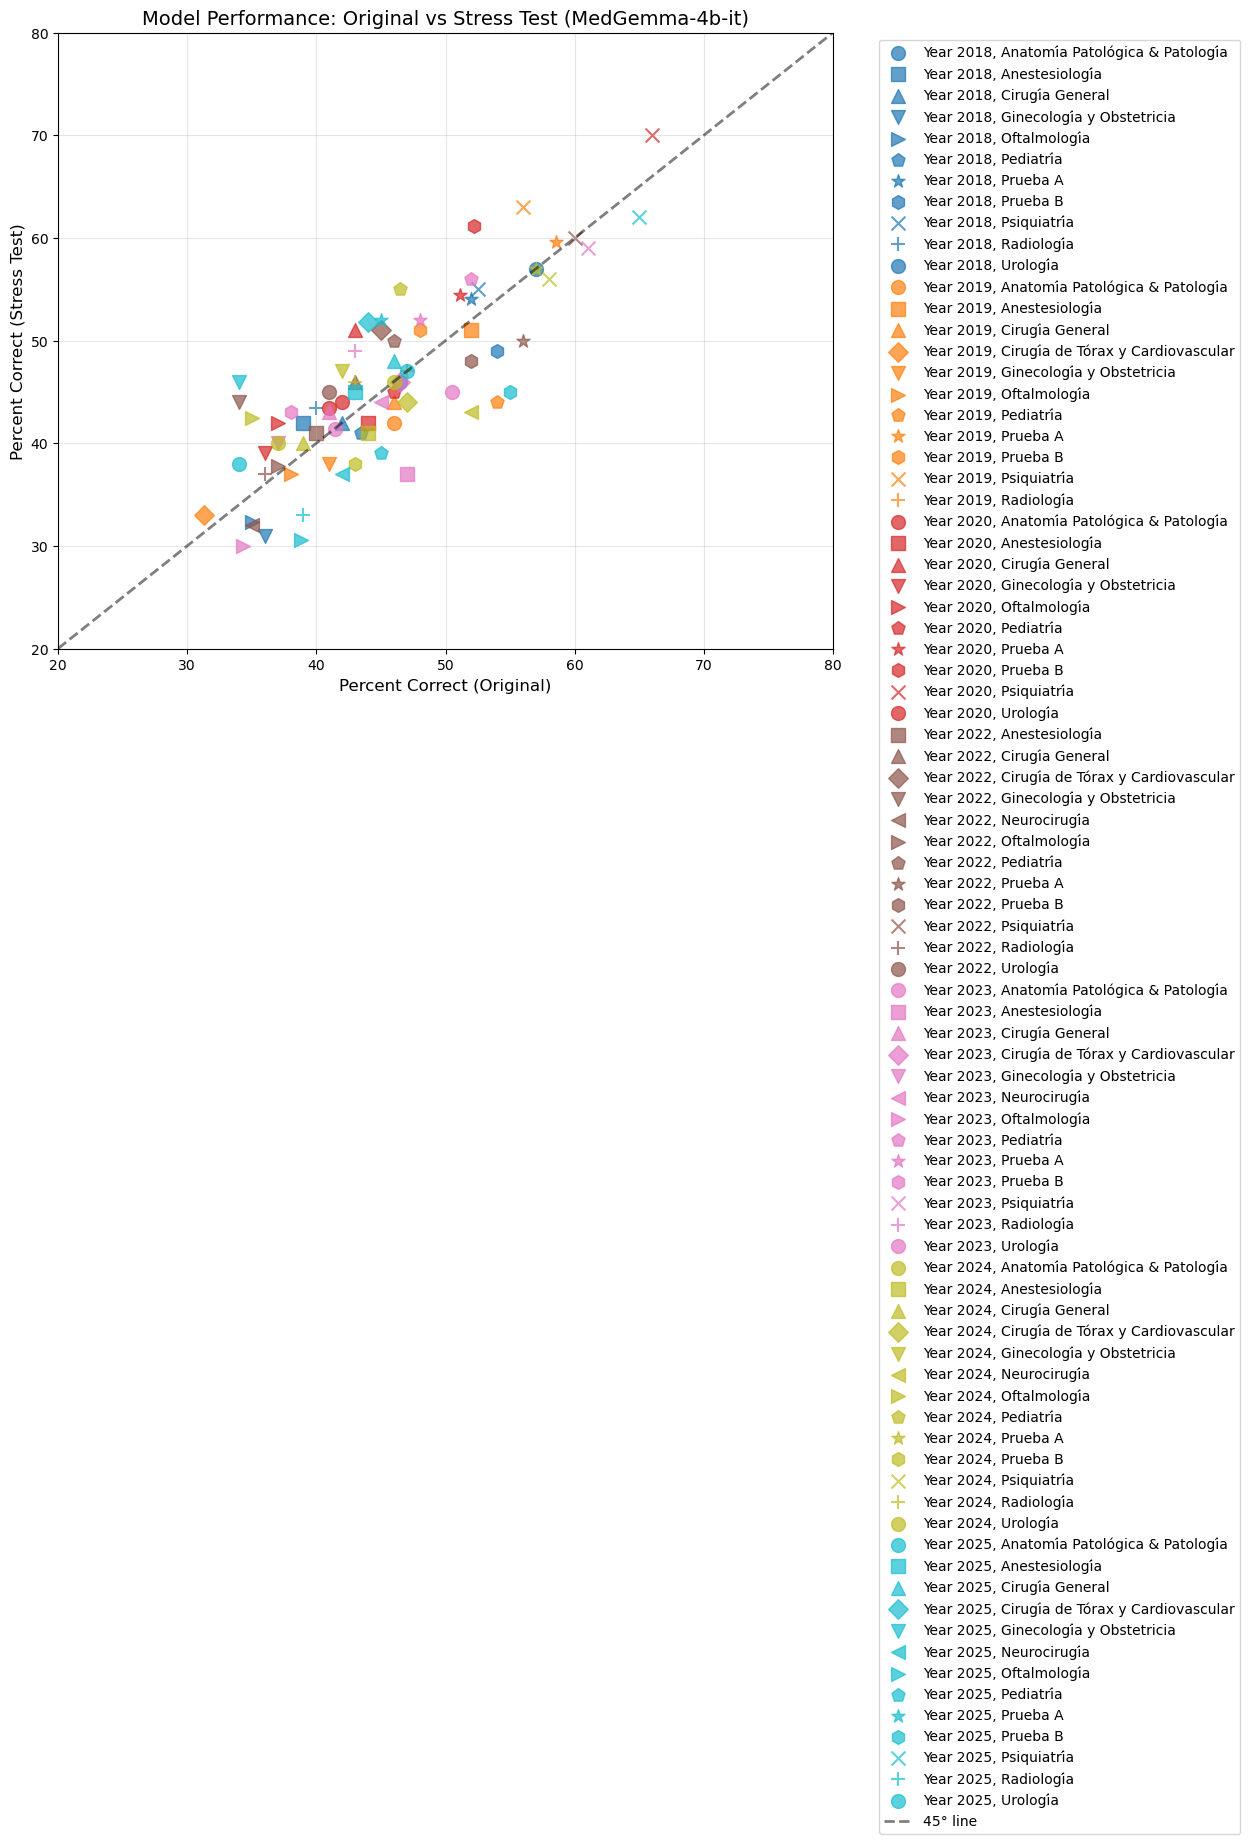

In [46]:
# Define marker styles for source_file
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h', 'x', '+']
marker_cycle = cycle(markers)
marker_map = {source: next(marker_cycle) for source in df_old_new_4b['source_file'].unique()}

# Get unique years and source files
years = sorted(df_old_new_4b['year'].unique())
source_files = sorted(df_old_new_4b['source_file'].unique())

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 8))

# Create a color map for years
colors = plt.cm.tab10(np.linspace(0, 1, len(years)))
color_map = {year: colors[i] for i, year in enumerate(years)}

# Plot points colored by year with markers by source_file
for year in years:
    for source_file in source_files:
        mask = (df_old_new_4b['year'] == year) & (df_old_new_4b['source_file'] == source_file)
        data = df_old_new_4b[mask]
        if len(data) > 0:
            ax.scatter(
                data['percentage_correct_old'],
                data['percentage_correct_new'],
                marker=marker_map[source_file],
                color=color_map[year],
                s=100,
                alpha=0.7,
                label=f"Year {year}, {source_file}"
            )

# Add 45-degree line
ax.plot([20, 100], [20, 100], 'k--', label='45° line', linewidth=2, alpha=0.5)

# Set axis limits and labels
ax.set_xlim(20, 80)
ax.set_ylim(20, 80)
ax.set_xlabel('Percent Correct (Original)', fontsize=12)
ax.set_ylabel('Percent Correct (Stress Test)', fontsize=12)
ax.set_title('Model Performance: Original vs Stress Test (MedGemma-4b-it)', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

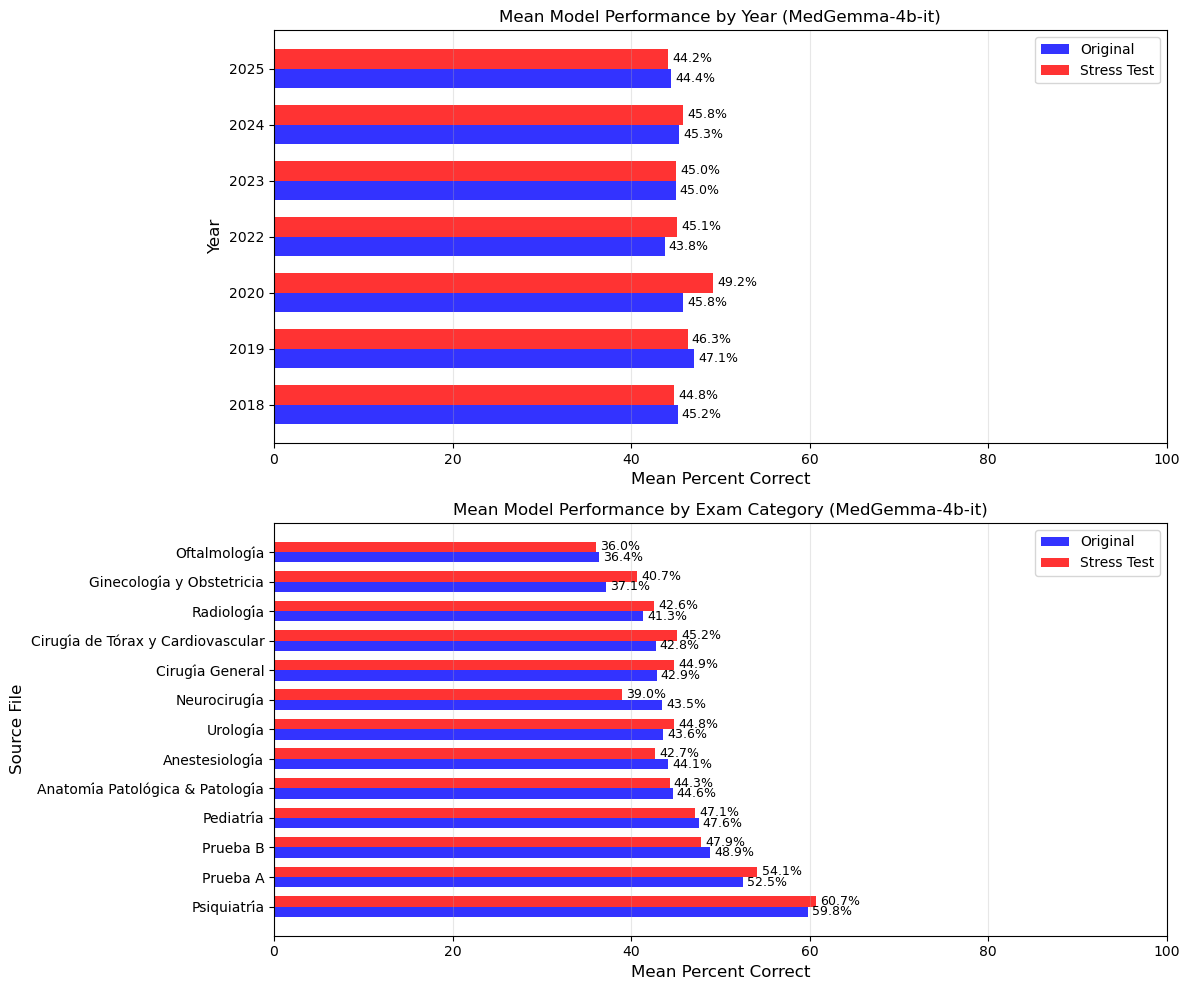

In [7]:
# Bar plot: Mean performance by year
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Group by year and calculate means
year_stats = df_old_new_4b.groupby('year')[['percentage_correct_old', 'percentage_correct_new']].mean()

# Bar plot 1: Mean performance by year
x_pos = np.arange(len(year_stats.index))
width = 0.35

bars_old_year = axes[0].barh(
    x_pos - width/2,
    year_stats['percentage_correct_old'],
    height=width,
    label='Original',
    color='blue',
    alpha=0.8
)
bars_new_year = axes[0].barh(
    x_pos + width/2,
    year_stats['percentage_correct_new'],
    height=width,
    label='Stress Test',
    color='red',
    alpha=0.8
)
axes[0].bar_label(bars_old_year, fmt='%.1f%%', padding=3, fontsize=9)
axes[0].bar_label(bars_new_year, fmt='%.1f%%', padding=3, fontsize=9)
axes[0].set_ylabel('Year', fontsize=12)
axes[0].set_xlabel('Mean Percent Correct', fontsize=12)
axes[0].set_xlim(0, 100)
axes[0].set_title('Mean Model Performance by Year (MedGemma-4b-it)', fontsize=12)
axes[0].set_yticks(x_pos)
axes[0].set_yticklabels(year_stats.index)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='x')

# Bar plot 2: Mean performance by source_file
source_stats = df_old_new_4b.groupby('source_file')[['percentage_correct_old', 'percentage_correct_new']].mean().sort_values('percentage_correct_old', ascending=False)

x_pos = np.arange(len(source_stats.index))
bars_old_source = axes[1].barh(
    x_pos - width/2,
    source_stats['percentage_correct_old'],
    height=width,
    label='Original',
    color='blue',
    alpha=0.8
)
bars_new_source = axes[1].barh(
    x_pos + width/2,
    source_stats['percentage_correct_new'],
    height=width,
    label='Stress Test',
    color='red',
    alpha=0.8
)
axes[1].bar_label(bars_old_source, fmt='%.1f%%', padding=3, fontsize=9)
axes[1].bar_label(bars_new_source, fmt='%.1f%%', padding=3, fontsize=9)
axes[1].set_ylabel('Source File', fontsize=12)
axes[1].set_xlabel('Mean Percent Correct', fontsize=12)
axes[1].set_xlim(0, 100)
axes[1].set_title('Mean Model Performance by Exam Category (MedGemma-4b-it)', fontsize=12)
axes[1].set_yticks(x_pos)
axes[1].set_yticklabels(source_stats.index)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

In [8]:
# Prepare data for paired tests
# Remove rows with missing values in either column
data_paired = df_old_new_4b[['percentage_correct_old', 'percentage_correct_new']].dropna()

print("=" * 70)
print("STATISTICAL TESTS: Original vs Stress Test Performance")
print("=" * 70)

# 1. Check normality of differences
differences = data_paired['percentage_correct_new'] - data_paired['percentage_correct_old']
stat_shapiro, p_shapiro = stats.shapiro(differences)
print(f"\n1. NORMALITY TEST (Shapiro-Wilk on differences):")
print(f"   Test Statistic: {stat_shapiro:.4f}")
print(f"   p-value: {p_shapiro:.6f}")
print(f"   Result: {'Data is normally distributed' if p_shapiro > 0.05 else 'Data deviates from normality'} (α=0.05)")

# 2. Paired t-test (parametric)
t_stat, p_ttest = stats.ttest_rel(data_paired['percentage_correct_new'], 
                                   data_paired['percentage_correct_old'])
mean_diff = differences.mean()
std_diff = differences.std()

print(f"\n2. PAIRED T-TEST (parametric):")
print(f"   Mean difference (Stress Test - Original): {mean_diff:.4f}%")
print(f"   Std deviation of differences: {std_diff:.4f}%")
print(f"   t-statistic: {t_stat:.4f}")
print(f"   p-value: {p_ttest:.6f}")
print(f"   Result: {'SIGNIFICANT difference' if p_ttest < 0.05 else 'No significant difference'} (α=0.05)")

# 3. Wilcoxon Signed-Rank Test (non-parametric alternative)
w_stat, p_wilcox = stats.wilcoxon(data_paired['percentage_correct_new'], 
                                    data_paired['percentage_correct_old'])
print(f"\n3. WILCOXON SIGNED-RANK TEST (non-parametric alternative):")
print(f"   W-statistic: {w_stat:.4f}")
print(f"   p-value: {p_wilcox:.6f}")
print(f"   Result: {'SIGNIFICANT difference' if p_wilcox < 0.05 else 'No significant difference'} (α=0.05)")

# 4. Effect size (Cohen's d for paired samples)
cohens_d = mean_diff / std_diff
print(f"\n4. EFFECT SIZE (Cohen's d):")
print(f"   Cohen's d: {cohens_d:.4f}")
if abs(cohens_d) < 0.2:
    effect_interpretation = "negligible"
elif abs(cohens_d) < 0.5:
    effect_interpretation = "small"
elif abs(cohens_d) < 0.8:
    effect_interpretation = "medium"
else:
    effect_interpretation = "large"
print(f"   Interpretation: {effect_interpretation.upper()} effect")

# 5. Descriptive statistics
print(f"\n5. DESCRIPTIVE STATISTICS:")
print(f"   N (paired observations): {len(data_paired)}")
print(f"   Original - Mean: {data_paired['percentage_correct_old'].mean():.2f}%, Std: {data_paired['percentage_correct_old'].std():.2f}%")
print(f"   Stress Test - Mean: {data_paired['percentage_correct_new'].mean():.2f}%, Std: {data_paired['percentage_correct_new'].std():.2f}%")

# Count improvements/declines
improvements = (differences > 0).sum()
declines = (differences < 0).sum()
no_change = (differences == 0).sum()

print(f"\n6. DIRECTION OF CHANGE:")
print(f"   Improved (Stress Test > Original): {improvements} ({100*improvements/len(data_paired):.1f}%)")
print(f"   Declined (Stress Test < Original): {declines} ({100*declines/len(data_paired):.1f}%)")
print(f"   No change: {no_change} ({100*no_change/len(data_paired):.1f}%)")

print("\n" + "=" * 70)
print("RECOMMENDATION:")
print("=" * 70)
if p_shapiro > 0.05:
    print("✓ Data appears normally distributed, paired t-test is appropriate.")
else:
    print("✗ Data deviates from normality. Consider using the Wilcoxon test.")
    print("  Both tests are shown above for comparison.")
print("=" * 70)

STATISTICAL TESTS: Original vs Stress Test Performance

1. NORMALITY TEST (Shapiro-Wilk on differences):
   Test Statistic: 0.9887
   p-value: 0.687136
   Result: Data is normally distributed (α=0.05)

2. PAIRED T-TEST (parametric):
   Mean difference (Stress Test - Original): 0.4901%
   Std deviation of differences: 4.7332%
   t-statistic: 0.9434
   p-value: 0.348258
   Result: No significant difference (α=0.05)

3. WILCOXON SIGNED-RANK TEST (non-parametric alternative):
   W-statistic: 1234.5000
   p-value: 0.313905
   Result: No significant difference (α=0.05)

4. EFFECT SIZE (Cohen's d):
   Cohen's d: 0.1035
   Interpretation: NEGLIGIBLE effect

5. DESCRIPTIVE STATISTICS:
   N (paired observations): 83
   Original - Mean: 45.19%, Std: 7.68%
   Stress Test - Mean: 45.68%, Std: 8.10%

6. DIRECTION OF CHANGE:
   Improved (Stress Test > Original): 42 (50.6%)
   Declined (Stress Test < Original): 33 (39.8%)
   No change: 8 (9.6%)

RECOMMENDATION:
✓ Data appears normally distributed, pai

In [9]:
# Stratified analysis by YEAR
print("\n" + "=" * 90)
print("STRATIFIED ANALYSIS BY YEAR")
print("=" * 90)

results_by_year = []

for year in sorted(df_old_new_4b['year'].unique()):
    year_data = df_old_new_4b[df_old_new_4b['year'] == year][['percentage_correct_old', 'percentage_correct_new']].dropna()
    
    if len(year_data) < 2:
        continue
    
    year_diff = year_data['percentage_correct_new'] - year_data['percentage_correct_old']
    t_stat_y, p_ttest_y = stats.ttest_rel(year_data['percentage_correct_new'], year_data['percentage_correct_old'])
    w_stat_y, p_wilcox_y = stats.wilcoxon(year_data['percentage_correct_new'], year_data['percentage_correct_old'])
    cohens_d_y = year_diff.mean() / year_diff.std() if year_diff.std() > 0 else 0
    
    results_by_year.append({
        'Year': year,
        'N': len(year_data),
        'Mean_Diff': year_diff.mean(),
        'Std_Diff': year_diff.std(),
        'T_stat': t_stat_y,
        'P_ttest': p_ttest_y,
        'P_wilcox': p_wilcox_y,
        'Cohens_d': cohens_d_y,
        'Original_Mean': year_data['percentage_correct_old'].mean(),
        'Stress_Mean': year_data['percentage_correct_new'].mean()
    })

results_by_year_df = pd.DataFrame(results_by_year)

print("\nYear-by-Year Summary:")
print("-" * 90)
for idx, row in results_by_year_df.iterrows():
    sig_ttest = "***" if row['P_ttest'] < 0.05 else ""
    sig_wilcox = "***" if row['P_wilcox'] < 0.05 else ""
    print(f"Year {int(row['Year'])} (N={int(row['N'])}):")
    print(f"  Original: {row['Original_Mean']:.2f}% → Stress: {row['Stress_Mean']:.2f}% (Δ = {row['Mean_Diff']:+.2f}%)")
    print(f"  T-test p-value: {row['P_ttest']:.4f} {sig_ttest}  |  Wilcoxon p-value: {row['P_wilcox']:.4f} {sig_wilcox}")
    print(f"  Cohen's d: {row['Cohens_d']:.4f}")
    print()

# Stratified analysis by SOURCE FILE
print("=" * 90)
print("STRATIFIED ANALYSIS BY SOURCE FILE (EXAM CATEGORY)")
print("=" * 90)

results_by_source = []

for source_file in sorted(df_old_new_4b['source_file'].unique()):
    source_data = df_old_new_4b[df_old_new_4b['source_file'] == source_file][['percentage_correct_old', 'percentage_correct_new']].dropna()
    
    if len(source_data) < 2:
        continue
    
    source_diff = source_data['percentage_correct_new'] - source_data['percentage_correct_old']
    t_stat_s, p_ttest_s = stats.ttest_rel(source_data['percentage_correct_new'], source_data['percentage_correct_old'])
    w_stat_s, p_wilcox_s = stats.wilcoxon(source_data['percentage_correct_new'], source_data['percentage_correct_old'])
    cohens_d_s = source_diff.mean() / source_diff.std() if source_diff.std() > 0 else 0
    
    results_by_source.append({
        'Source_File': source_file,
        'N': len(source_data),
        'Mean_Diff': source_diff.mean(),
        'Std_Diff': source_diff.std(),
        'T_stat': t_stat_s,
        'P_ttest': p_ttest_s,
        'P_wilcox': p_wilcox_s,
        'Cohens_d': cohens_d_s,
        'Original_Mean': source_data['percentage_correct_old'].mean(),
        'Stress_Mean': source_data['percentage_correct_new'].mean()
    })

results_by_source_df = pd.DataFrame(results_by_source).sort_values('Original_Mean', ascending=False)

print("\nSource File-by-Source File Summary:")
print("-" * 90)
for idx, row in results_by_source_df.iterrows():
    sig_ttest = "***" if row['P_ttest'] < 0.05 else ""
    sig_wilcox = "***" if row['P_wilcox'] < 0.05 else ""
    print(f"{row['Source_File']} (N={int(row['N'])}):")
    print(f"  Original: {row['Original_Mean']:.2f}% → Stress: {row['Stress_Mean']:.2f}% (Δ = {row['Mean_Diff']:+.2f}%)")
    print(f"  T-test p-value: {row['P_ttest']:.4f} {sig_ttest}  |  Wilcoxon p-value: {row['P_wilcox']:.4f} {sig_wilcox}")
    print(f"  Cohen's d: {row['Cohens_d']:.4f}")
    print()

print("=" * 90)
print("LEGEND: *** indicates p < 0.05 (statistically significant)")
print("=" * 90)


STRATIFIED ANALYSIS BY YEAR

Year-by-Year Summary:
------------------------------------------------------------------------------------------
Year 2018 (N=11):
  Original: 45.22% → Stress: 44.80% (Δ = -0.42%)
  T-test p-value: 0.6527   |  Wilcoxon p-value: 0.7070 
  Cohen's d: -0.1398

Year 2019 (N=11):
  Original: 47.08% → Stress: 46.33% (Δ = -0.75%)
  T-test p-value: 0.5752   |  Wilcoxon p-value: 0.6445 
  Cohen's d: -0.1747

Year 2020 (N=10):
  Original: 45.83% → Stress: 49.20% (Δ = +3.36%)
  T-test p-value: 0.0126 ***  |  Wilcoxon p-value: 0.0117 ***
  Cohen's d: 0.9815

Year 2022 (N=12):
  Original: 43.75% → Stress: 45.15% (Δ = +1.40%)
  T-test p-value: 0.2995   |  Wilcoxon p-value: 0.3105 
  Cohen's d: 0.3143

Year 2023 (N=13):
  Original: 44.98% → Stress: 45.03% (Δ = +0.05%)
  T-test p-value: 0.9679   |  Wilcoxon p-value: 0.8652 
  Cohen's d: 0.0114

Year 2024 (N=13):
  Original: 45.34% → Stress: 45.80% (Δ = +0.46%)
  T-test p-value: 0.7455   |  Wilcoxon p-value: 0.7832 
  Cohe

# 02.medgemma-1_5-4b-it

In [10]:
df_old_1_5_4b = pd.read_pickle(f'/Users/rodrigocarrillo/Documents/Natural Language Processing Projects/Examen Residentado Peru/02.LLMs Results/11.medgemma-1_5-4b-it/{file_name}')
df_old_1_5_4b = df_old_1_5_4b.rename(columns={"count_of_matches": "count_of_matches_old", "total_rows": "total_rows_old", "percent_correct": "percentage_correct_old"})
df_old_1_5_4b['model_name'] = "medgemma1.5-4b-it"
df_old_1_5_4b.head()

,source_file,year,count_of_matches_old,total_rows_old,percentage_correct_old,model_name
0,Anatomía Patológica & Patología,2018,63,96,65.62,medgemma1.5-4b-it
1,Anatomía Patológica & Patología,2019,51,96,53.12,medgemma1.5-4b-it
2,Anatomía Patológica & Patología,2020,54,99,54.55,medgemma1.5-4b-it
3,Anatomía Patológica & Patología,2023,64,99,64.65,medgemma1.5-4b-it
4,Anatomía Patológica & Patología,2024,61,99,61.62,medgemma1.5-4b-it


In [11]:
df_new_1_5_4b = pd.read_pickle(f'/Users/rodrigocarrillo/Documents/Natural Language Processing Projects/Examen Residentado Peru/02.LLMs Results/Reorder Options/02.medgemma-1_5-4b-it/{file_name}')
df_new_1_5_4b = df_new_1_5_4b.rename(columns={"count_of_matches": "count_of_matches_new", "total_rows": "total_rows_new", "percent_correct": "percentage_correct_new"})
df_new_1_5_4b.head()

,source_file,year,count_of_matches_new,total_rows_new,percentage_correct_new,model_name
0,Anatomía Patológica & Patología,2018,58,94,61.70,medgemma1.5-4b-it
1,Anatomía Patológica & Patología,2019,57,96,59.38,medgemma1.5-4b-it
2,Anatomía Patológica & Patología,2020,63,96,65.62,medgemma1.5-4b-it
3,Anatomía Patológica & Patología,2023,54,96,56.25,medgemma1.5-4b-it
4,Anatomía Patológica & Patología,2024,53,98,54.08,medgemma1.5-4b-it


In [12]:
df_old_new_1_5_4b = pd.merge(df_old_1_5_4b, df_new_1_5_4b, on=["source_file", "year", "model_name"], how="outer")
df_old_new_1_5_4b

,source_file,year,count_of_matches_old,total_rows_old,percentage_correct_old,model_name,count_of_matches_new,total_rows_new,percentage_correct_new
0,Anatomía Patológica & Patología,2018,63,96,65.62,medgemma1.5-4b-it,58,94,61.70
1,Anatomía Patológica & Patología,2019,51,96,53.12,medgemma1.5-4b-it,57,96,59.38
2,Anatomía Patológica & Patología,2020,54,99,54.55,medgemma1.5-4b-it,63,96,65.62
3,Anatomía Patológica & Patología,2023,64,99,64.65,medgemma1.5-4b-it,54,96,56.25
4,Anatomía Patológica & Patología,2024,61,99,61.62,medgemma1.5-4b-it,53,98,54.08
...,...,...,...,...,...,...,...,...,...
78,Urología,2020,57,100,57.00,medgemma1.5-4b-it,51,99,51.52
79,Urología,2022,53,100,53.00,medgemma1.5-4b-it,61,98,62.24
80,Urología,2023,59,98,60.20,medgemma1.5-4b-it,50,96,52.08
81,Urología,2024,52,99,52.53,medgemma1.5-4b-it,46,97,47.42


/var/folders/0p/pq1qfwzj0bz0b4wsym558qgw0000gn/T/ipykernel_64895/1927383813.py:45: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


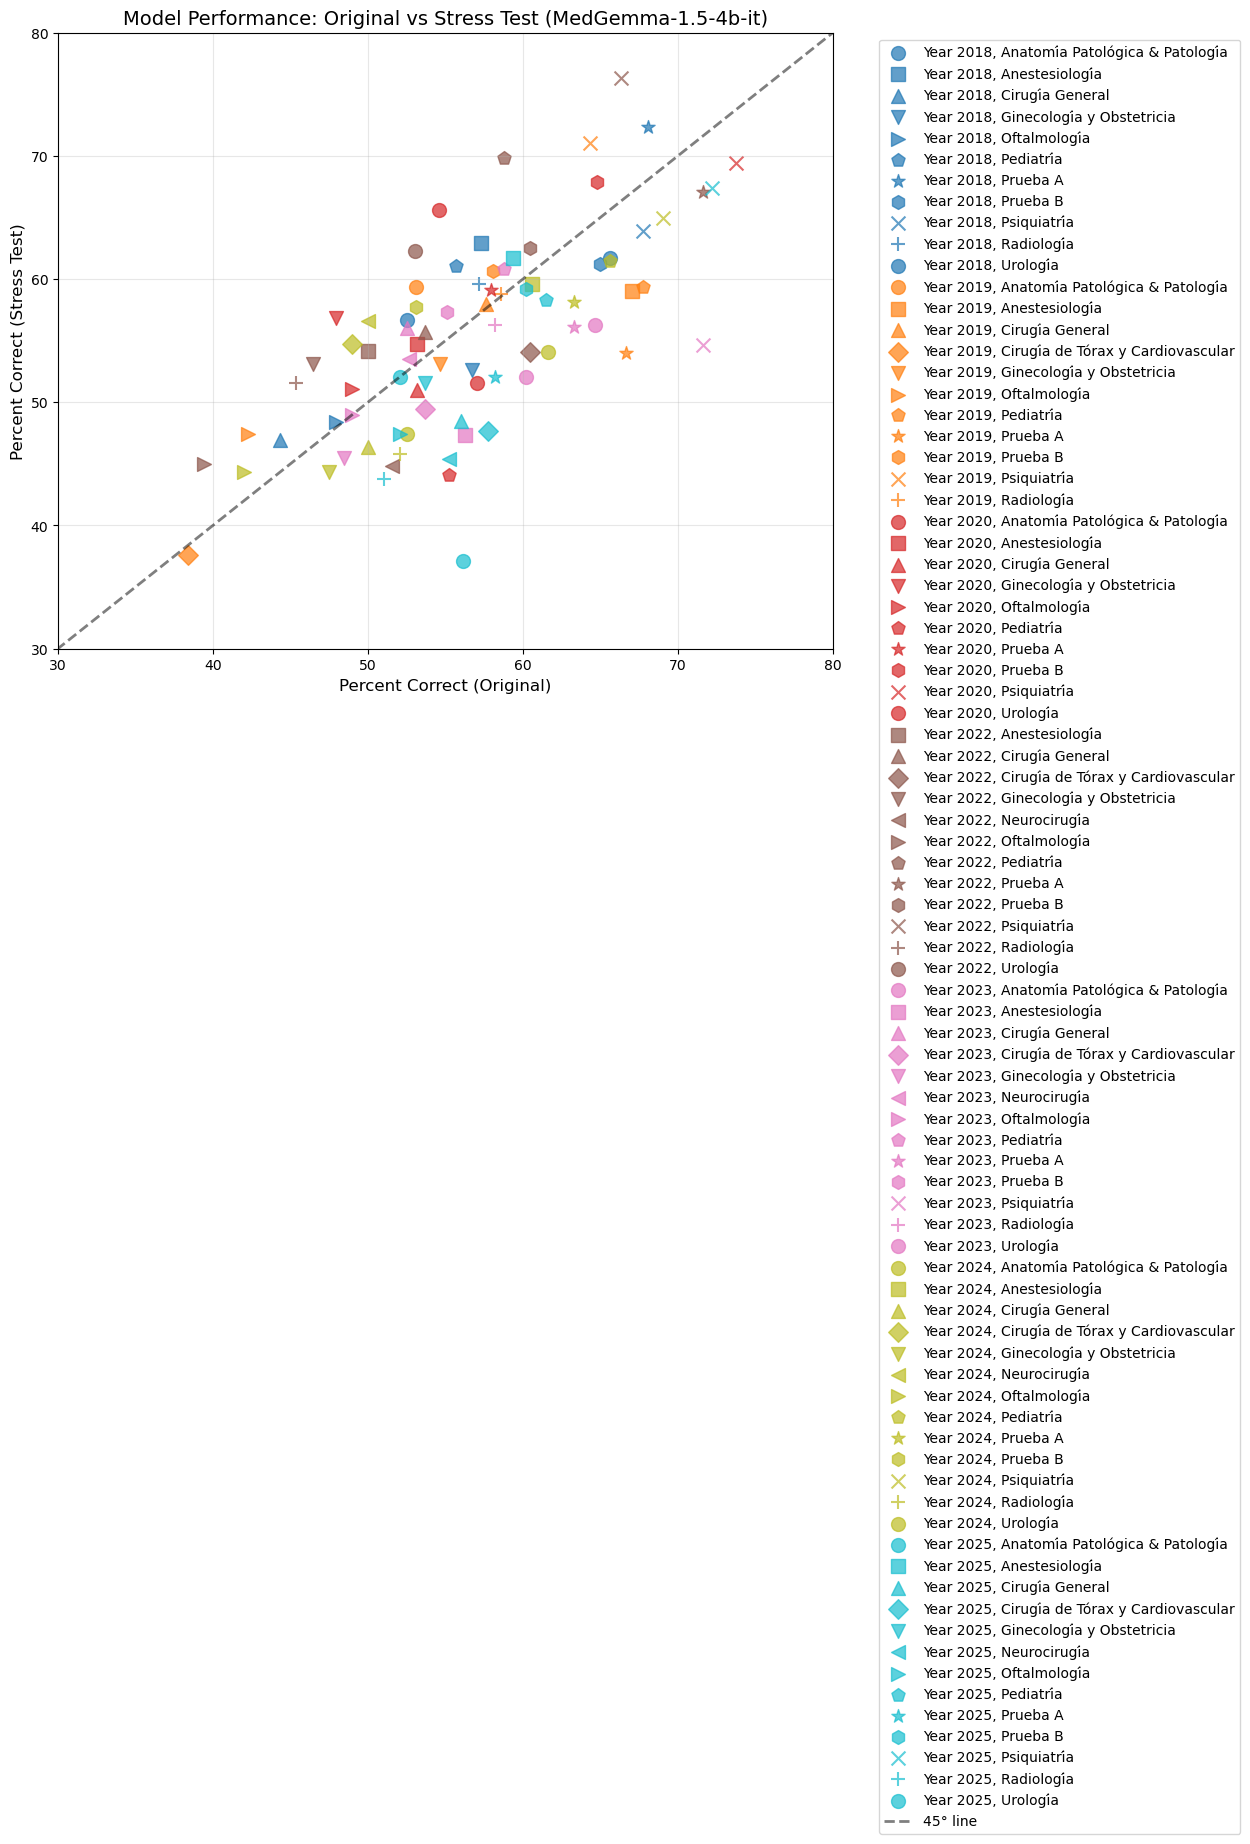

In [48]:
# Define marker styles for source_file
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h', 'x', '+']
marker_cycle = cycle(markers)
marker_map = {source: next(marker_cycle) for source in df_old_new_1_5_4b['source_file'].unique()}

# Get unique years and source files
years = sorted(df_old_new_1_5_4b['year'].unique())
source_files = sorted(df_old_new_1_5_4b['source_file'].unique())

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 8))

# Create a color map for years
colors = plt.cm.tab10(np.linspace(0, 1, len(years)))
color_map = {year: colors[i] for i, year in enumerate(years)}

# Plot points colored by year with markers by source_file
for year in years:
    for source_file in source_files:
        mask = (df_old_new_1_5_4b['year'] == year) & (df_old_new_1_5_4b['source_file'] == source_file)
        data = df_old_new_1_5_4b[mask]
        if len(data) > 0:
            ax.scatter(
                data['percentage_correct_old'],
                data['percentage_correct_new'],
                marker=marker_map[source_file],
                color=color_map[year],
                s=100,
                alpha=0.7,
                label=f"Year {year}, {source_file}"
            )

# Add 45-degree line
ax.plot([20, 100], [20, 100], 'k--', label='45° line', linewidth=2, alpha=0.5)

# Set axis limits and labels
ax.set_xlim(30, 80)
ax.set_ylim(30, 80)
ax.set_xlabel('Percent Correct (Original)', fontsize=12)
ax.set_ylabel('Percent Correct (Stress Test)', fontsize=12)
ax.set_title('Model Performance: Original vs Stress Test (MedGemma-1.5-4b-it)', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

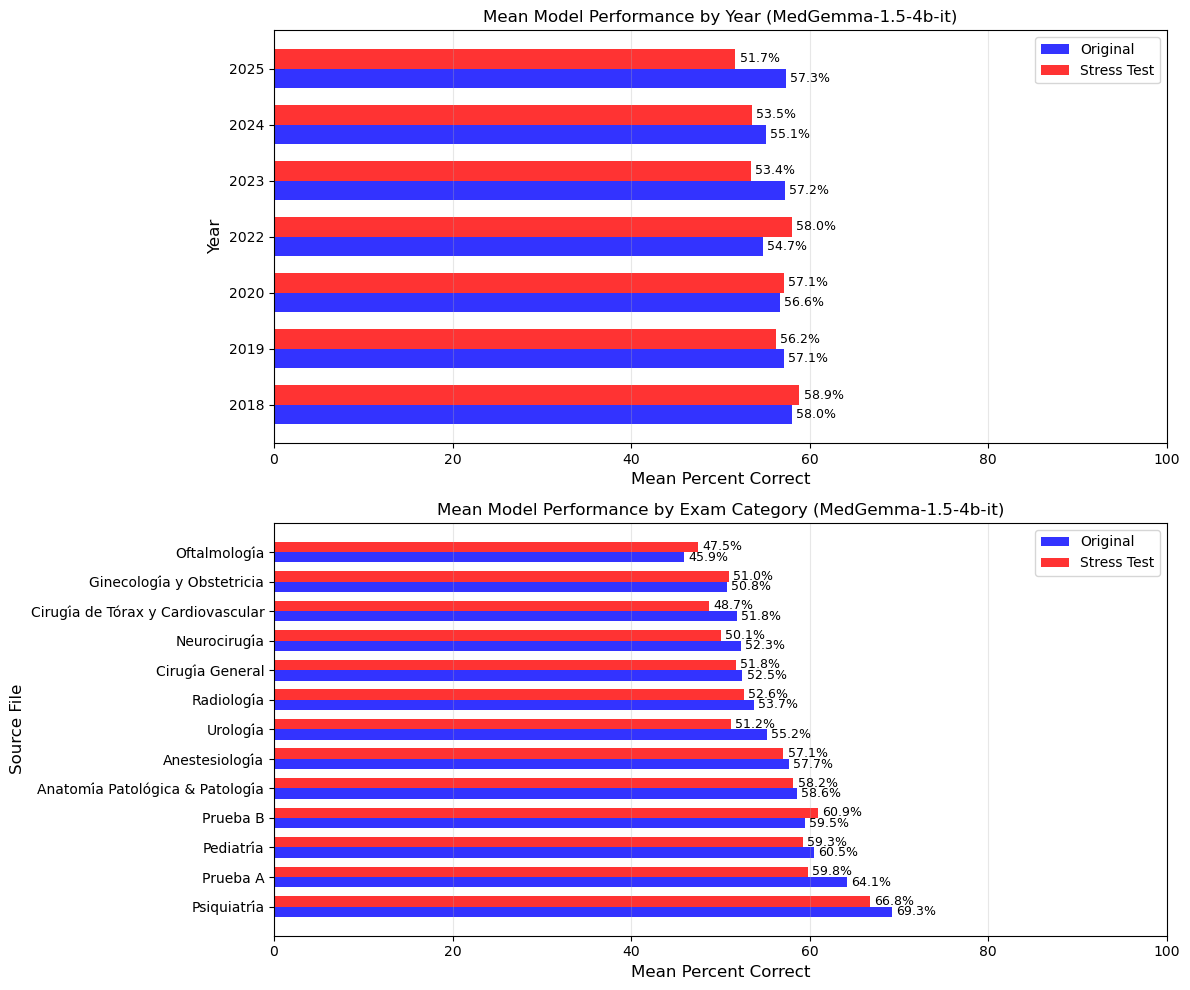

In [49]:
# Bar plot: Mean performance by year
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Group by year and calculate means
year_stats = df_old_new_1_5_4b.groupby('year')[['percentage_correct_old', 'percentage_correct_new']].mean()

# Bar plot 1: Mean performance by year
x_pos = np.arange(len(year_stats.index))
width = 0.35

bars_old_year = axes[0].barh(
    x_pos - width/2,
    year_stats['percentage_correct_old'],
    height=width,
    label='Original',
    color='blue',
    alpha=0.8
)
bars_new_year = axes[0].barh(
    x_pos + width/2,
    year_stats['percentage_correct_new'],
    height=width,
    label='Stress Test',
    color='red',
    alpha=0.8
)
axes[0].bar_label(bars_old_year, fmt='%.1f%%', padding=3, fontsize=9)
axes[0].bar_label(bars_new_year, fmt='%.1f%%', padding=3, fontsize=9)
axes[0].set_ylabel('Year', fontsize=12)
axes[0].set_xlabel('Mean Percent Correct', fontsize=12)
axes[0].set_xlim(0, 100)
axes[0].set_title('Mean Model Performance by Year (MedGemma-1.5-4b-it)', fontsize=12)
axes[0].set_yticks(x_pos)
axes[0].set_yticklabels(year_stats.index)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='x')

# Bar plot 2: Mean performance by source_file
source_stats = df_old_new_1_5_4b.groupby('source_file')[['percentage_correct_old', 'percentage_correct_new']].mean().sort_values('percentage_correct_old', ascending=False)

x_pos = np.arange(len(source_stats.index))
bars_old_source = axes[1].barh(
    x_pos - width/2,
    source_stats['percentage_correct_old'],
    height=width,
    label='Original',
    color='blue',
    alpha=0.8
)
bars_new_source = axes[1].barh(
    x_pos + width/2,
    source_stats['percentage_correct_new'],
    height=width,
    label='Stress Test',
    color='red',
    alpha=0.8
)
axes[1].bar_label(bars_old_source, fmt='%.1f%%', padding=3, fontsize=9)
axes[1].bar_label(bars_new_source, fmt='%.1f%%', padding=3, fontsize=9)
axes[1].set_ylabel('Source File', fontsize=12)
axes[1].set_xlabel('Mean Percent Correct', fontsize=12)
axes[1].set_xlim(0, 100)
axes[1].set_title('Mean Model Performance by Exam Category (MedGemma-1.5-4b-it)', fontsize=12)
axes[1].set_yticks(x_pos)
axes[1].set_yticklabels(source_stats.index)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

In [15]:
# Prepare data for paired tests
# Remove rows with missing values in either column
data_paired = df_old_new_1_5_4b[['percentage_correct_old', 'percentage_correct_new']].dropna()

print("=" * 70)
print("STATISTICAL TESTS: Original vs Stress Test Performance")
print("=" * 70)

# 1. Check normality of differences
differences = data_paired['percentage_correct_new'] - data_paired['percentage_correct_old']
stat_shapiro, p_shapiro = stats.shapiro(differences)
print(f"\n1. NORMALITY TEST (Shapiro-Wilk on differences):")
print(f"   Test Statistic: {stat_shapiro:.4f}")
print(f"   p-value: {p_shapiro:.6f}")
print(f"   Result: {'Data is normally distributed' if p_shapiro > 0.05 else 'Data deviates from normality'} (α=0.05)")

# 2. Paired t-test (parametric)
t_stat, p_ttest = stats.ttest_rel(data_paired['percentage_correct_new'], 
                                   data_paired['percentage_correct_old'])
mean_diff = differences.mean()
std_diff = differences.std()

print(f"\n2. PAIRED T-TEST (parametric):")
print(f"   Mean difference (Stress Test - Original): {mean_diff:.4f}%")
print(f"   Std deviation of differences: {std_diff:.4f}%")
print(f"   t-statistic: {t_stat:.4f}")
print(f"   p-value: {p_ttest:.6f}")
print(f"   Result: {'SIGNIFICANT difference' if p_ttest < 0.05 else 'No significant difference'} (α=0.05)")

# 3. Wilcoxon Signed-Rank Test (non-parametric alternative)
w_stat, p_wilcox = stats.wilcoxon(data_paired['percentage_correct_new'], 
                                    data_paired['percentage_correct_old'])
print(f"\n3. WILCOXON SIGNED-RANK TEST (non-parametric alternative):")
print(f"   W-statistic: {w_stat:.4f}")
print(f"   p-value: {p_wilcox:.6f}")
print(f"   Result: {'SIGNIFICANT difference' if p_wilcox < 0.05 else 'No significant difference'} (α=0.05)")

# 4. Effect size (Cohen's d for paired samples)
cohens_d = mean_diff / std_diff
print(f"\n4. EFFECT SIZE (Cohen's d):")
print(f"   Cohen's d: {cohens_d:.4f}")
if abs(cohens_d) < 0.2:
    effect_interpretation = "negligible"
elif abs(cohens_d) < 0.5:
    effect_interpretation = "small"
elif abs(cohens_d) < 0.8:
    effect_interpretation = "medium"
else:
    effect_interpretation = "large"
print(f"   Interpretation: {effect_interpretation.upper()} effect")

# 5. Descriptive statistics
print(f"\n5. DESCRIPTIVE STATISTICS:")
print(f"   N (paired observations): {len(data_paired)}")
print(f"   Original - Mean: {data_paired['percentage_correct_old'].mean():.2f}%, Std: {data_paired['percentage_correct_old'].std():.2f}%")
print(f"   Stress Test - Mean: {data_paired['percentage_correct_new'].mean():.2f}%, Std: {data_paired['percentage_correct_new'].std():.2f}%")

# Count improvements/declines
improvements = (differences > 0).sum()
declines = (differences < 0).sum()
no_change = (differences == 0).sum()

print(f"\n6. DIRECTION OF CHANGE:")
print(f"   Improved (Stress Test > Original): {improvements} ({100*improvements/len(data_paired):.1f}%)")
print(f"   Declined (Stress Test < Original): {declines} ({100*declines/len(data_paired):.1f}%)")
print(f"   No change: {no_change} ({100*no_change/len(data_paired):.1f}%)")

print("\n" + "=" * 70)
print("RECOMMENDATION:")
print("=" * 70)
if p_shapiro > 0.05:
    print("✓ Data appears normally distributed, paired t-test is appropriate.")
else:
    print("✗ Data deviates from normality. Consider using the Wilcoxon test.")
    print("  Both tests are shown above for comparison.")
print("=" * 70)

STATISTICAL TESTS: Original vs Stress Test Performance

1. NORMALITY TEST (Shapiro-Wilk on differences):
   Test Statistic: 0.9846
   p-value: 0.423393
   Result: Data is normally distributed (α=0.05)

2. PAIRED T-TEST (parametric):
   Mean difference (Stress Test - Original): -1.2128%
   Std deviation of differences: 6.1488%
   t-statistic: -1.7969
   p-value: 0.076031
   Result: No significant difference (α=0.05)

3. WILCOXON SIGNED-RANK TEST (non-parametric alternative):
   W-statistic: 1355.0000
   p-value: 0.109189
   Result: No significant difference (α=0.05)

4. EFFECT SIZE (Cohen's d):
   Cohen's d: -0.1972
   Interpretation: NEGLIGIBLE effect

5. DESCRIPTIVE STATISTICS:
   N (paired observations): 83
   Original - Mean: 56.57%, Std: 7.65%
   Stress Test - Mean: 55.36%, Std: 7.87%

6. DIRECTION OF CHANGE:
   Improved (Stress Test > Original): 38 (45.8%)
   Declined (Stress Test < Original): 44 (53.0%)
   No change: 1 (1.2%)

RECOMMENDATION:
✓ Data appears normally distributed, 

In [16]:
# Stratified analysis by YEAR
print("\n" + "=" * 90)
print("STRATIFIED ANALYSIS BY YEAR")
print("=" * 90)

results_by_year = []

for year in sorted(df_old_new_1_5_4b['year'].unique()):
    year_data = df_old_new_1_5_4b[df_old_new_1_5_4b['year'] == year][['percentage_correct_old', 'percentage_correct_new']].dropna()
    
    if len(year_data) < 2:
        continue
    
    year_diff = year_data['percentage_correct_new'] - year_data['percentage_correct_old']
    t_stat_y, p_ttest_y = stats.ttest_rel(year_data['percentage_correct_new'], year_data['percentage_correct_old'])
    w_stat_y, p_wilcox_y = stats.wilcoxon(year_data['percentage_correct_new'], year_data['percentage_correct_old'])
    cohens_d_y = year_diff.mean() / year_diff.std() if year_diff.std() > 0 else 0
    
    results_by_year.append({
        'Year': year,
        'N': len(year_data),
        'Mean_Diff': year_diff.mean(),
        'Std_Diff': year_diff.std(),
        'T_stat': t_stat_y,
        'P_ttest': p_ttest_y,
        'P_wilcox': p_wilcox_y,
        'Cohens_d': cohens_d_y,
        'Original_Mean': year_data['percentage_correct_old'].mean(),
        'Stress_Mean': year_data['percentage_correct_new'].mean()
    })

results_by_year_df = pd.DataFrame(results_by_year)

print("\nYear-by-Year Summary:")
print("-" * 90)
for idx, row in results_by_year_df.iterrows():
    sig_ttest = "***" if row['P_ttest'] < 0.05 else ""
    sig_wilcox = "***" if row['P_wilcox'] < 0.05 else ""
    print(f"Year {int(row['Year'])} (N={int(row['N'])}):")
    print(f"  Original: {row['Original_Mean']:.2f}% → Stress: {row['Stress_Mean']:.2f}% (Δ = {row['Mean_Diff']:+.2f}%)")
    print(f"  T-test p-value: {row['P_ttest']:.4f} {sig_ttest}  |  Wilcoxon p-value: {row['P_wilcox']:.4f} {sig_wilcox}")
    print(f"  Cohen's d: {row['Cohens_d']:.4f}")
    print()

# Stratified analysis by SOURCE FILE
print("=" * 90)
print("STRATIFIED ANALYSIS BY SOURCE FILE (EXAM CATEGORY)")
print("=" * 90)

results_by_source = []

for source_file in sorted(df_old_new_1_5_4b['source_file'].unique()):
    source_data = df_old_new_1_5_4b[df_old_new_1_5_4b['source_file'] == source_file][['percentage_correct_old', 'percentage_correct_new']].dropna()
    
    if len(source_data) < 2:
        continue
    
    source_diff = source_data['percentage_correct_new'] - source_data['percentage_correct_old']
    t_stat_s, p_ttest_s = stats.ttest_rel(source_data['percentage_correct_new'], source_data['percentage_correct_old'])
    w_stat_s, p_wilcox_s = stats.wilcoxon(source_data['percentage_correct_new'], source_data['percentage_correct_old'])
    cohens_d_s = source_diff.mean() / source_diff.std() if source_diff.std() > 0 else 0
    
    results_by_source.append({
        'Source_File': source_file,
        'N': len(source_data),
        'Mean_Diff': source_diff.mean(),
        'Std_Diff': source_diff.std(),
        'T_stat': t_stat_s,
        'P_ttest': p_ttest_s,
        'P_wilcox': p_wilcox_s,
        'Cohens_d': cohens_d_s,
        'Original_Mean': source_data['percentage_correct_old'].mean(),
        'Stress_Mean': source_data['percentage_correct_new'].mean()
    })

results_by_source_df = pd.DataFrame(results_by_source).sort_values('Original_Mean', ascending=False)

print("\nSource File-by-Source File Summary:")
print("-" * 90)
for idx, row in results_by_source_df.iterrows():
    sig_ttest = "***" if row['P_ttest'] < 0.05 else ""
    sig_wilcox = "***" if row['P_wilcox'] < 0.05 else ""
    print(f"{row['Source_File']} (N={int(row['N'])}):")
    print(f"  Original: {row['Original_Mean']:.2f}% → Stress: {row['Stress_Mean']:.2f}% (Δ = {row['Mean_Diff']:+.2f}%)")
    print(f"  T-test p-value: {row['P_ttest']:.4f} {sig_ttest}  |  Wilcoxon p-value: {row['P_wilcox']:.4f} {sig_wilcox}")
    print(f"  Cohen's d: {row['Cohens_d']:.4f}")
    print()

print("=" * 90)
print("LEGEND: *** indicates p < 0.05 (statistically significant)")
print("=" * 90)


STRATIFIED ANALYSIS BY YEAR

Year-by-Year Summary:
------------------------------------------------------------------------------------------
Year 2018 (N=11):
  Original: 57.99% → Stress: 58.85% (Δ = +0.86%)
  T-test p-value: 0.4963   |  Wilcoxon p-value: 0.3652 
  Cohen's d: 0.2129

Year 2019 (N=11):
  Original: 57.12% → Stress: 56.20% (Δ = -0.92%)
  T-test p-value: 0.6426   |  Wilcoxon p-value: 0.7646 
  Cohen's d: -0.1443

Year 2020 (N=10):
  Original: 56.65% → Stress: 57.12% (Δ = +0.47%)
  T-test p-value: 0.8264   |  Wilcoxon p-value: 1.0000 
  Cohen's d: 0.0714

Year 2022 (N=12):
  Original: 54.75% → Stress: 58.02% (Δ = +3.27%)
  T-test p-value: 0.0952   |  Wilcoxon p-value: 0.1514 
  Cohen's d: 0.5270

Year 2023 (N=13):
  Original: 57.25% → Stress: 53.40% (Δ = -3.85%)
  T-test p-value: 0.0360 ***  |  Wilcoxon p-value: 0.0681 
  Cohen's d: -0.6549

Year 2024 (N=13):
  Original: 55.10% → Stress: 53.51% (Δ = -1.59%)
  T-test p-value: 0.2547   |  Wilcoxon p-value: 0.3396 
  Cohen's

# 03.medgemma-27b-text-it

In [17]:
df_old_27b = pd.read_pickle(f'/Users/rodrigocarrillo/Documents/Natural Language Processing Projects/Examen Residentado Peru/02.LLMs Results/06.medgemma-27b-text-it/{file_name}')
df_old_27b = df_old_27b.rename(columns={"count_of_matches": "count_of_matches_old", "total_rows": "total_rows_old", "percent_correct": "percentage_correct_old"})
df_old_27b.head()

,source_file,year,count_of_matches_old,total_rows_old,percentage_correct_old,model_name
0,Anatomía Patológica & Patología,2018,82,100,82.0,medgemma-27b-text-it
1,Anatomía Patológica & Patología,2019,77,100,77.0,medgemma-27b-text-it
2,Anatomía Patológica & Patología,2020,88,100,88.0,medgemma-27b-text-it
3,Anatomía Patológica & Patología,2023,86,100,86.0,medgemma-27b-text-it
4,Anatomía Patológica & Patología,2024,92,100,92.0,medgemma-27b-text-it


In [18]:
df_new_27b = pd.read_pickle(f'/Users/rodrigocarrillo/Documents/Natural Language Processing Projects/Examen Residentado Peru/02.LLMs Results/Reorder Options/03.medgemma-27b-text-it/{file_name}')
df_new_27b = df_new_27b.rename(columns={"count_of_matches": "count_of_matches_new", "total_rows": "total_rows_new", "percent_correct": "percentage_correct_new"})
df_new_27b.head()

,source_file,year,count_of_matches_new,total_rows_new,percentage_correct_new,model_name
0,Anatomía Patológica & Patología,2018,84,100,84.0,medgemma-27b-text-it
1,Anatomía Patológica & Patología,2019,68,100,68.0,medgemma-27b-text-it
2,Anatomía Patológica & Patología,2020,86,100,86.0,medgemma-27b-text-it
3,Anatomía Patológica & Patología,2023,86,100,86.0,medgemma-27b-text-it
4,Anatomía Patológica & Patología,2024,89,100,89.0,medgemma-27b-text-it


In [19]:
df_old_new_27b = pd.merge(df_old_27b, df_new_27b, on=["source_file", "year", "model_name"], how="outer")
df_old_new_27b

,source_file,year,count_of_matches_old,total_rows_old,percentage_correct_old,model_name,count_of_matches_new,total_rows_new,percentage_correct_new
0,Anatomía Patológica & Patología,2018,82,100,82.0,medgemma-27b-text-it,84,100,84.0
1,Anatomía Patológica & Patología,2019,77,100,77.0,medgemma-27b-text-it,68,100,68.0
2,Anatomía Patológica & Patología,2020,88,100,88.0,medgemma-27b-text-it,86,100,86.0
3,Anatomía Patológica & Patología,2023,86,100,86.0,medgemma-27b-text-it,86,100,86.0
4,Anatomía Patológica & Patología,2024,92,100,92.0,medgemma-27b-text-it,89,100,89.0
...,...,...,...,...,...,...,...,...,...
78,Urología,2020,78,100,78.0,medgemma-27b-text-it,76,100,76.0
79,Urología,2022,82,100,82.0,medgemma-27b-text-it,83,100,83.0
80,Urología,2023,83,100,83.0,medgemma-27b-text-it,86,100,86.0
81,Urología,2024,72,100,72.0,medgemma-27b-text-it,74,100,74.0


/var/folders/0p/pq1qfwzj0bz0b4wsym558qgw0000gn/T/ipykernel_64895/2272952599.py:45: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


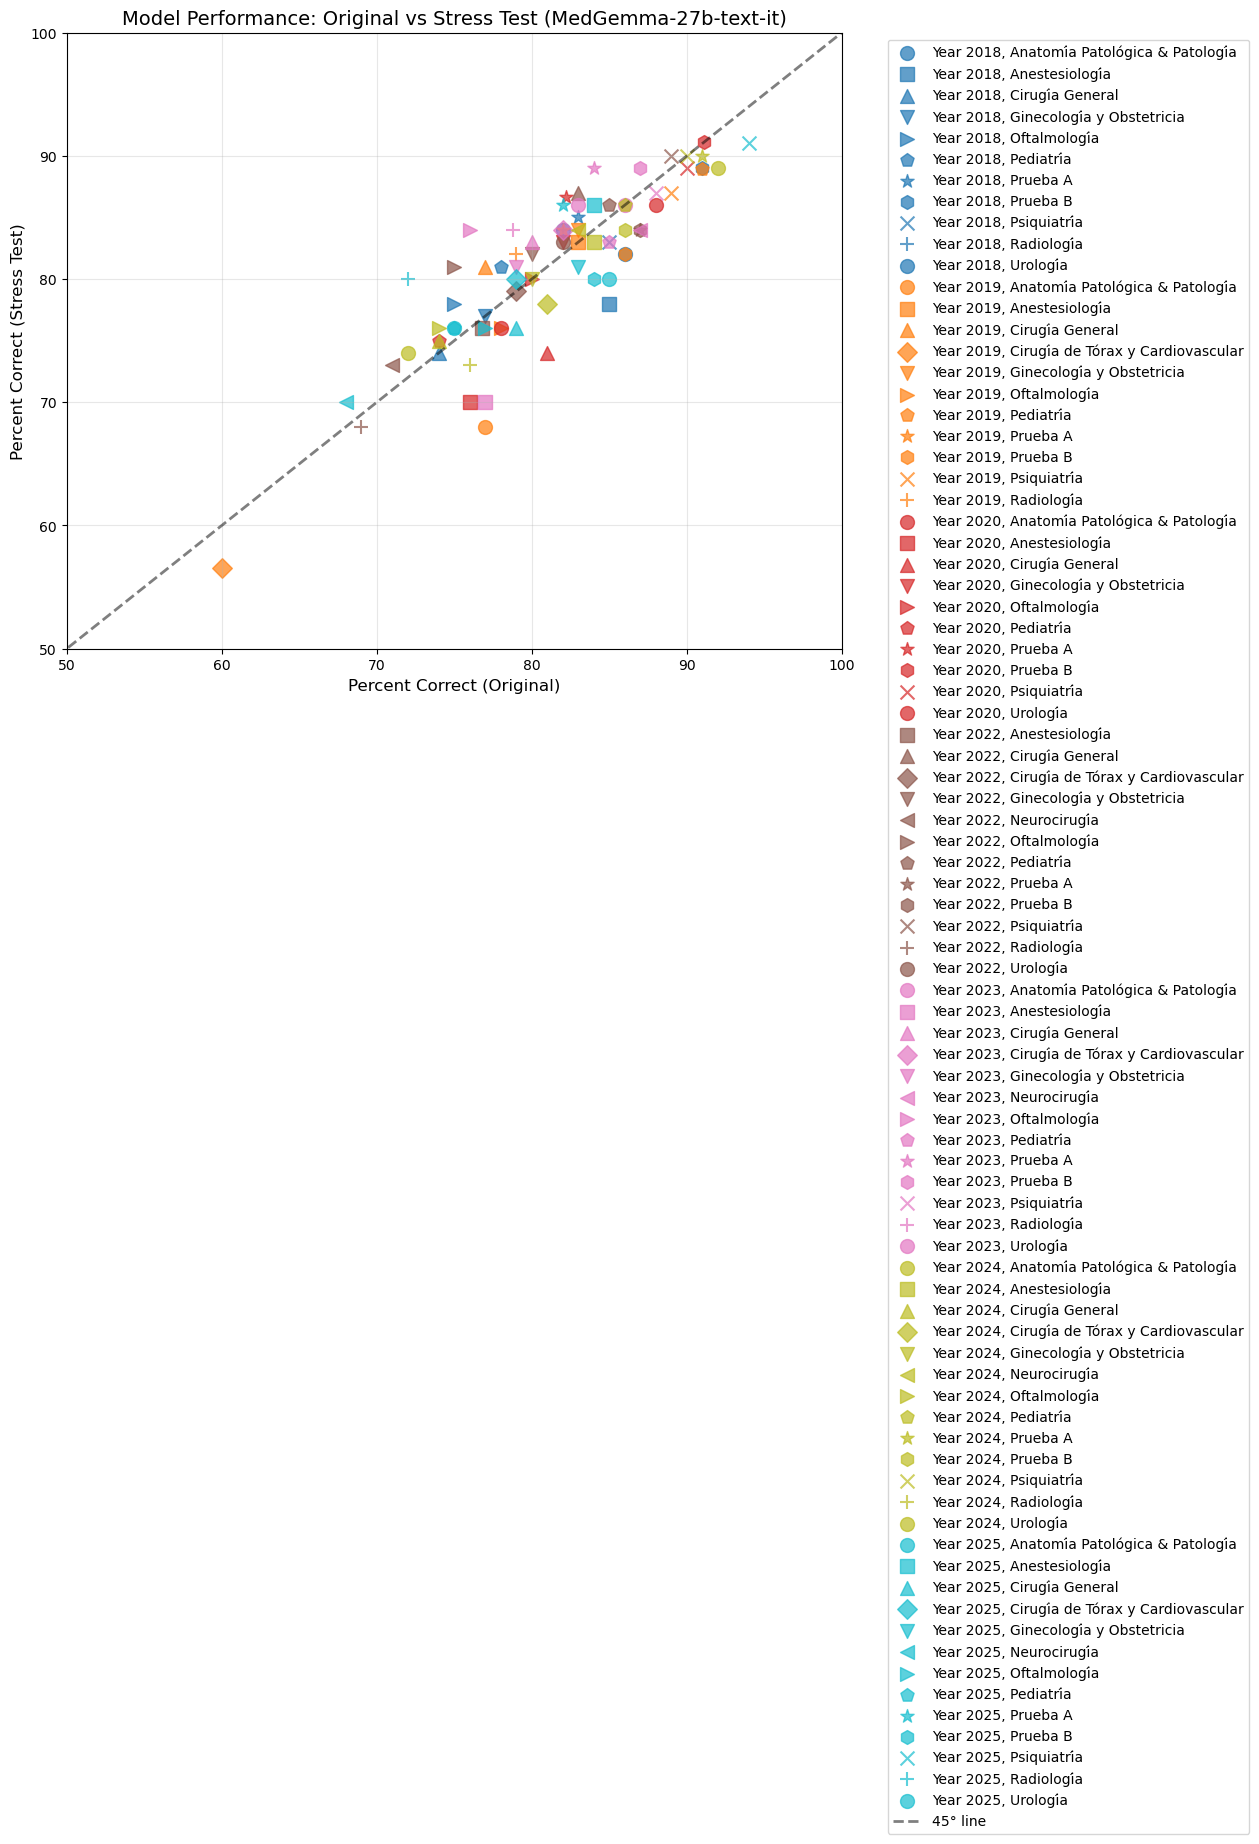

In [50]:
# Define marker styles for source_file
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h', 'x', '+']
marker_cycle = cycle(markers)
marker_map = {source: next(marker_cycle) for source in df_old_new_27b['source_file'].unique()}

# Get unique years and source files
years = sorted(df_old_new_27b['year'].unique())
source_files = sorted(df_old_new_27b['source_file'].unique())

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 8))

# Create a color map for years
colors = plt.cm.tab10(np.linspace(0, 1, len(years)))
color_map = {year: colors[i] for i, year in enumerate(years)}

# Plot points colored by year with markers by source_file
for year in years:
    for source_file in source_files:
        mask = (df_old_new_27b['year'] == year) & (df_old_new_27b['source_file'] == source_file)
        data = df_old_new_27b[mask]
        if len(data) > 0:
            ax.scatter(
                data['percentage_correct_old'],
                data['percentage_correct_new'],
                marker=marker_map[source_file],
                color=color_map[year],
                s=100,
                alpha=0.7,
                label=f"Year {year}, {source_file}"
            )

# Add 45-degree line
ax.plot([20, 100], [20, 100], 'k--', label='45° line', linewidth=2, alpha=0.5)

# Set axis limits and labels
ax.set_xlim(50, 100)
ax.set_ylim(50, 100)
ax.set_xlabel('Percent Correct (Original)', fontsize=12)
ax.set_ylabel('Percent Correct (Stress Test)', fontsize=12)
ax.set_title('Model Performance: Original vs Stress Test (MedGemma-27b-text-it)', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

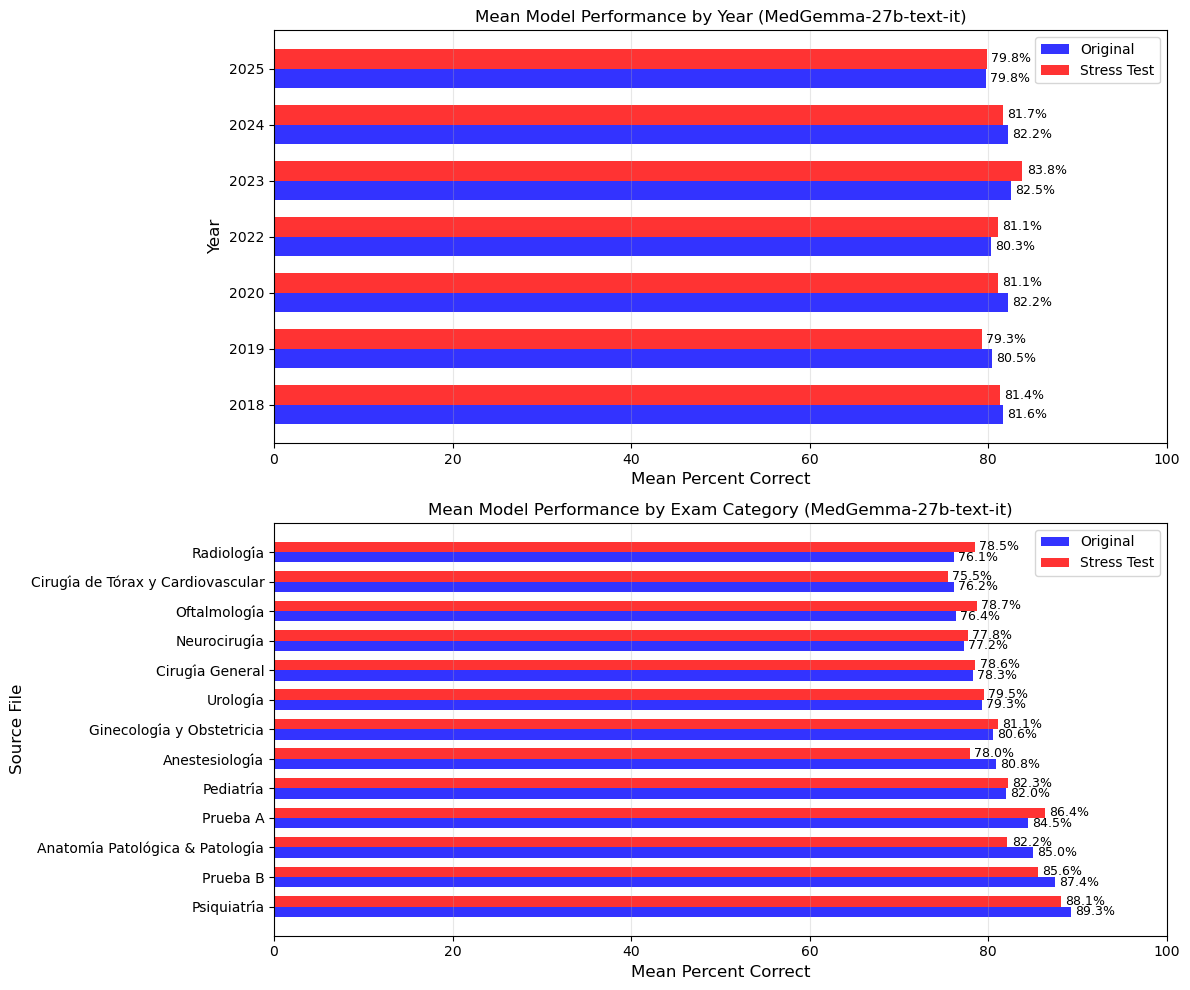

In [21]:
# Bar plot: Mean performance by year
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Group by year and calculate means
year_stats = df_old_new_27b.groupby('year')[['percentage_correct_old', 'percentage_correct_new']].mean()

# Bar plot 1: Mean performance by year
x_pos = np.arange(len(year_stats.index))
width = 0.35

bars_old_year = axes[0].barh(
    x_pos - width/2,
    year_stats['percentage_correct_old'],
    height=width,
    label='Original',
    color='blue',
    alpha=0.8
)
bars_new_year = axes[0].barh(
    x_pos + width/2,
    year_stats['percentage_correct_new'],
    height=width,
    label='Stress Test',
    color='red',
    alpha=0.8
)
axes[0].bar_label(bars_old_year, fmt='%.1f%%', padding=3, fontsize=9)
axes[0].bar_label(bars_new_year, fmt='%.1f%%', padding=3, fontsize=9)
axes[0].set_ylabel('Year', fontsize=12)
axes[0].set_xlabel('Mean Percent Correct', fontsize=12)
axes[0].set_xlim(0, 100)
axes[0].set_title('Mean Model Performance by Year (MedGemma-27b-text-it)', fontsize=12)
axes[0].set_yticks(x_pos)
axes[0].set_yticklabels(year_stats.index)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='x')

# Bar plot 2: Mean performance by source_file
source_stats = df_old_new_27b.groupby('source_file')[['percentage_correct_old', 'percentage_correct_new']].mean().sort_values('percentage_correct_old', ascending=False)

x_pos = np.arange(len(source_stats.index))
bars_old_source = axes[1].barh(
    x_pos - width/2,
    source_stats['percentage_correct_old'],
    height=width,
    label='Original',
    color='blue',
    alpha=0.8
)
bars_new_source = axes[1].barh(
    x_pos + width/2,
    source_stats['percentage_correct_new'],
    height=width,
    label='Stress Test',
    color='red',
    alpha=0.8
)
axes[1].bar_label(bars_old_source, fmt='%.1f%%', padding=3, fontsize=9)
axes[1].bar_label(bars_new_source, fmt='%.1f%%', padding=3, fontsize=9)
axes[1].set_ylabel('Source File', fontsize=12)
axes[1].set_xlabel('Mean Percent Correct', fontsize=12)
axes[1].set_xlim(0, 100)
axes[1].set_title('Mean Model Performance by Exam Category (MedGemma-27b-text-it)', fontsize=12)
axes[1].set_yticks(x_pos)
axes[1].set_yticklabels(source_stats.index)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

In [22]:
# Prepare data for paired tests
# Remove rows with missing values in either column
data_paired = df_old_new_27b[['percentage_correct_old', 'percentage_correct_new']].dropna()

print("=" * 70)
print("STATISTICAL TESTS: Original vs Stress Test Performance")
print("=" * 70)

# 1. Check normality of differences
differences = data_paired['percentage_correct_new'] - data_paired['percentage_correct_old']
stat_shapiro, p_shapiro = stats.shapiro(differences)
print(f"\n1. NORMALITY TEST (Shapiro-Wilk on differences):")
print(f"   Test Statistic: {stat_shapiro:.4f}")
print(f"   p-value: {p_shapiro:.6f}")
print(f"   Result: {'Data is normally distributed' if p_shapiro > 0.05 else 'Data deviates from normality'} (α=0.05)")

# 2. Paired t-test (parametric)
t_stat, p_ttest = stats.ttest_rel(data_paired['percentage_correct_new'], 
                                   data_paired['percentage_correct_old'])
mean_diff = differences.mean()
std_diff = differences.std()

print(f"\n2. PAIRED T-TEST (parametric):")
print(f"   Mean difference (Stress Test - Original): {mean_diff:.4f}%")
print(f"   Std deviation of differences: {std_diff:.4f}%")
print(f"   t-statistic: {t_stat:.4f}")
print(f"   p-value: {p_ttest:.6f}")
print(f"   Result: {'SIGNIFICANT difference' if p_ttest < 0.05 else 'No significant difference'} (α=0.05)")

# 3. Wilcoxon Signed-Rank Test (non-parametric alternative)
w_stat, p_wilcox = stats.wilcoxon(data_paired['percentage_correct_new'], 
                                    data_paired['percentage_correct_old'])
print(f"\n3. WILCOXON SIGNED-RANK TEST (non-parametric alternative):")
print(f"   W-statistic: {w_stat:.4f}")
print(f"   p-value: {p_wilcox:.6f}")
print(f"   Result: {'SIGNIFICANT difference' if p_wilcox < 0.05 else 'No significant difference'} (α=0.05)")

# 4. Effect size (Cohen's d for paired samples)
cohens_d = mean_diff / std_diff
print(f"\n4. EFFECT SIZE (Cohen's d):")
print(f"   Cohen's d: {cohens_d:.4f}")
if abs(cohens_d) < 0.2:
    effect_interpretation = "negligible"
elif abs(cohens_d) < 0.5:
    effect_interpretation = "small"
elif abs(cohens_d) < 0.8:
    effect_interpretation = "medium"
else:
    effect_interpretation = "large"
print(f"   Interpretation: {effect_interpretation.upper()} effect")

# 5. Descriptive statistics
print(f"\n5. DESCRIPTIVE STATISTICS:")
print(f"   N (paired observations): {len(data_paired)}")
print(f"   Original - Mean: {data_paired['percentage_correct_old'].mean():.2f}%, Std: {data_paired['percentage_correct_old'].std():.2f}%")
print(f"   Stress Test - Mean: {data_paired['percentage_correct_new'].mean():.2f}%, Std: {data_paired['percentage_correct_new'].std():.2f}%")

# Count improvements/declines
improvements = (differences > 0).sum()
declines = (differences < 0).sum()
no_change = (differences == 0).sum()

print(f"\n6. DIRECTION OF CHANGE:")
print(f"   Improved (Stress Test > Original): {improvements} ({100*improvements/len(data_paired):.1f}%)")
print(f"   Declined (Stress Test < Original): {declines} ({100*declines/len(data_paired):.1f}%)")
print(f"   No change: {no_change} ({100*no_change/len(data_paired):.1f}%)")

print("\n" + "=" * 70)
print("RECOMMENDATION:")
print("=" * 70)
if p_shapiro > 0.05:
    print("✓ Data appears normally distributed, paired t-test is appropriate.")
else:
    print("✗ Data deviates from normality. Consider using the Wilcoxon test.")
    print("  Both tests are shown above for comparison.")
print("=" * 70)

STATISTICAL TESTS: Original vs Stress Test Performance

1. NORMALITY TEST (Shapiro-Wilk on differences):
   Test Statistic: 0.9809
   p-value: 0.256085
   Result: Data is normally distributed (α=0.05)

2. PAIRED T-TEST (parametric):
   Mean difference (Stress Test - Original): -0.0801%
   Std deviation of differences: 3.2370%
   t-statistic: -0.2255
   p-value: 0.822155
   Result: No significant difference (α=0.05)

3. WILCOXON SIGNED-RANK TEST (non-parametric alternative):
   W-statistic: 1309.0000
   p-value: 0.818520
   Result: No significant difference (α=0.05)

4. EFFECT SIZE (Cohen's d):
   Cohen's d: -0.0248
   Interpretation: NEGLIGIBLE effect

5. DESCRIPTIVE STATISTICS:
   N (paired observations): 83
   Original - Mean: 81.30%, Std: 6.13%
   Stress Test - Mean: 81.22%, Std: 6.24%

6. DIRECTION OF CHANGE:
   Improved (Stress Test > Original): 38 (45.8%)
   Declined (Stress Test < Original): 35 (42.2%)
   No change: 10 (12.0%)

RECOMMENDATION:
✓ Data appears normally distributed

In [23]:
# Stratified analysis by YEAR
print("\n" + "=" * 90)
print("STRATIFIED ANALYSIS BY YEAR")
print("=" * 90)

results_by_year = []

for year in sorted(df_old_new_27b['year'].unique()):
    year_data = df_old_new_27b[df_old_new_27b['year'] == year][['percentage_correct_old', 'percentage_correct_new']].dropna()
    
    if len(year_data) < 2:
        continue
    
    year_diff = year_data['percentage_correct_new'] - year_data['percentage_correct_old']
    t_stat_y, p_ttest_y = stats.ttest_rel(year_data['percentage_correct_new'], year_data['percentage_correct_old'])
    w_stat_y, p_wilcox_y = stats.wilcoxon(year_data['percentage_correct_new'], year_data['percentage_correct_old'])
    cohens_d_y = year_diff.mean() / year_diff.std() if year_diff.std() > 0 else 0
    
    results_by_year.append({
        'Year': year,
        'N': len(year_data),
        'Mean_Diff': year_diff.mean(),
        'Std_Diff': year_diff.std(),
        'T_stat': t_stat_y,
        'P_ttest': p_ttest_y,
        'P_wilcox': p_wilcox_y,
        'Cohens_d': cohens_d_y,
        'Original_Mean': year_data['percentage_correct_old'].mean(),
        'Stress_Mean': year_data['percentage_correct_new'].mean()
    })

results_by_year_df = pd.DataFrame(results_by_year)

print("\nYear-by-Year Summary:")
print("-" * 90)
for idx, row in results_by_year_df.iterrows():
    sig_ttest = "***" if row['P_ttest'] < 0.05 else ""
    sig_wilcox = "***" if row['P_wilcox'] < 0.05 else ""
    print(f"Year {int(row['Year'])} (N={int(row['N'])}):")
    print(f"  Original: {row['Original_Mean']:.2f}% → Stress: {row['Stress_Mean']:.2f}% (Δ = {row['Mean_Diff']:+.2f}%)")
    print(f"  T-test p-value: {row['P_ttest']:.4f} {sig_ttest}  |  Wilcoxon p-value: {row['P_wilcox']:.4f} {sig_wilcox}")
    print(f"  Cohen's d: {row['Cohens_d']:.4f}")
    print()

# Stratified analysis by SOURCE FILE
print("=" * 90)
print("STRATIFIED ANALYSIS BY SOURCE FILE (EXAM CATEGORY)")
print("=" * 90)

results_by_source = []

for source_file in sorted(df_old_new_27b['source_file'].unique()):
    source_data = df_old_new_27b[df_old_new_27b['source_file'] == source_file][['percentage_correct_old', 'percentage_correct_new']].dropna()
    
    if len(source_data) < 2:
        continue
    
    source_diff = source_data['percentage_correct_new'] - source_data['percentage_correct_old']
    t_stat_s, p_ttest_s = stats.ttest_rel(source_data['percentage_correct_new'], source_data['percentage_correct_old'])
    w_stat_s, p_wilcox_s = stats.wilcoxon(source_data['percentage_correct_new'], source_data['percentage_correct_old'])
    cohens_d_s = source_diff.mean() / source_diff.std() if source_diff.std() > 0 else 0
    
    results_by_source.append({
        'Source_File': source_file,
        'N': len(source_data),
        'Mean_Diff': source_diff.mean(),
        'Std_Diff': source_diff.std(),
        'T_stat': t_stat_s,
        'P_ttest': p_ttest_s,
        'P_wilcox': p_wilcox_s,
        'Cohens_d': cohens_d_s,
        'Original_Mean': source_data['percentage_correct_old'].mean(),
        'Stress_Mean': source_data['percentage_correct_new'].mean()
    })

results_by_source_df = pd.DataFrame(results_by_source).sort_values('Original_Mean', ascending=False)

print("\nSource File-by-Source File Summary:")
print("-" * 90)
for idx, row in results_by_source_df.iterrows():
    sig_ttest = "***" if row['P_ttest'] < 0.05 else ""
    sig_wilcox = "***" if row['P_wilcox'] < 0.05 else ""
    print(f"{row['Source_File']} (N={int(row['N'])}):")
    print(f"  Original: {row['Original_Mean']:.2f}% → Stress: {row['Stress_Mean']:.2f}% (Δ = {row['Mean_Diff']:+.2f}%)")
    print(f"  T-test p-value: {row['P_ttest']:.4f} {sig_ttest}  |  Wilcoxon p-value: {row['P_wilcox']:.4f} {sig_wilcox}")
    print(f"  Cohen's d: {row['Cohens_d']:.4f}")
    print()

print("=" * 90)
print("LEGEND: *** indicates p < 0.05 (statistically significant)")
print("=" * 90)


STRATIFIED ANALYSIS BY YEAR

Year-by-Year Summary:
------------------------------------------------------------------------------------------
Year 2018 (N=11):
  Original: 81.64% → Stress: 81.36% (Δ = -0.27%)
  T-test p-value: 0.7830   |  Wilcoxon p-value: 1.0000 
  Cohen's d: -0.0853

Year 2019 (N=11):
  Original: 80.45% → Stress: 79.31% (Δ = -1.14%)
  T-test p-value: 0.3310   |  Wilcoxon p-value: 0.3887 
  Cohen's d: -0.3081

Year 2020 (N=10):
  Original: 82.23% → Stress: 81.08% (Δ = -1.15%)
  T-test p-value: 0.3072   |  Wilcoxon p-value: 0.2969 
  Cohen's d: -0.3423

Year 2022 (N=12):
  Original: 80.31% → Stress: 81.08% (Δ = +0.77%)
  T-test p-value: 0.3310   |  Wilcoxon p-value: 0.3193 
  Cohen's d: 0.2936

Year 2023 (N=13):
  Original: 82.52% → Stress: 83.85% (Δ = +1.32%)
  T-test p-value: 0.2491   |  Wilcoxon p-value: 0.2114 
  Cohen's d: 0.3359

Year 2024 (N=13):
  Original: 82.23% → Stress: 81.69% (Δ = -0.54%)
  T-test p-value: 0.3041   |  Wilcoxon p-value: 0.2949 
  Cohen's d

In [24]:
# df_old_new_27b.to_csv('/Users/rodrigocarrillo/Downloads/medgemma_27b_results.csv', index=False)

# 04.BioMistral DARE 7B

In [25]:
df_old_mistral = pd.read_pickle(f'/Users/rodrigocarrillo/Documents/Natural Language Processing Projects/Examen Residentado Peru/02.LLMs Results/02.BioMistral DARE 7B/{file_name}')
df_old_mistral = df_old_mistral.rename(columns={"count_of_matches": "count_of_matches_old", "total_rows": "total_rows_old", "percent_correct": "percentage_correct_old"})
df_old_mistral.head()

,source_file,year,count_of_matches_old,total_rows_old,percentage_correct_old,model_name
0,Anatomía Patológica & Patología,2018,36,100,36.00,BioMistral-7B-DARE
1,Anatomía Patológica & Patología,2019,35,100,35.00,BioMistral-7B-DARE
2,Anatomía Patológica & Patología,2020,28,100,28.00,BioMistral-7B-DARE
3,Anatomía Patológica & Patología,2023,37,99,37.37,BioMistral-7B-DARE
4,Anatomía Patológica & Patología,2024,37,97,38.14,BioMistral-7B-DARE


In [26]:
df_new_mistral = pd.read_pickle(f'/Users/rodrigocarrillo/Documents/Natural Language Processing Projects/Examen Residentado Peru/02.LLMs Results/Reorder Options/04.BioMistral DARE 7B/{file_name}')
df_new_mistral = df_new_mistral.rename(columns={"count_of_matches": "count_of_matches_new", "total_rows": "total_rows_new", "percent_correct": "percentage_correct_new"})
df_new_mistral.head()

,source_file,year,count_of_matches_new,total_rows_new,percentage_correct_new,model_name
0,Anatomía Patológica & Patología,2018,29,100,29.00,BioMistral-7B-DARE
1,Anatomía Patológica & Patología,2019,34,100,34.00,BioMistral-7B-DARE
2,Anatomía Patológica & Patología,2020,23,99,23.23,BioMistral-7B-DARE
3,Anatomía Patológica & Patología,2023,38,99,38.38,BioMistral-7B-DARE
4,Anatomía Patológica & Patología,2024,36,96,37.50,BioMistral-7B-DARE


In [27]:
df_old_new_mistral = pd.merge(df_old_mistral, df_new_mistral, on=["source_file", "year", "model_name"], how="outer")
df_old_new_mistral

,source_file,year,count_of_matches_old,total_rows_old,percentage_correct_old,model_name,count_of_matches_new,total_rows_new,percentage_correct_new
0,Anatomía Patológica & Patología,2018,36,100,36.00,BioMistral-7B-DARE,29,100,29.00
1,Anatomía Patológica & Patología,2019,35,100,35.00,BioMistral-7B-DARE,34,100,34.00
2,Anatomía Patológica & Patología,2020,28,100,28.00,BioMistral-7B-DARE,23,99,23.23
3,Anatomía Patológica & Patología,2023,37,99,37.37,BioMistral-7B-DARE,38,99,38.38
4,Anatomía Patológica & Patología,2024,37,97,38.14,BioMistral-7B-DARE,36,96,37.50
...,...,...,...,...,...,...,...,...,...
78,Urología,2020,41,100,41.00,BioMistral-7B-DARE,34,100,34.00
79,Urología,2022,22,98,22.45,BioMistral-7B-DARE,28,98,28.57
80,Urología,2023,31,100,31.00,BioMistral-7B-DARE,33,100,33.00
81,Urología,2024,26,96,27.08,BioMistral-7B-DARE,28,96,29.17


/var/folders/0p/pq1qfwzj0bz0b4wsym558qgw0000gn/T/ipykernel_64895/2304127123.py:45: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


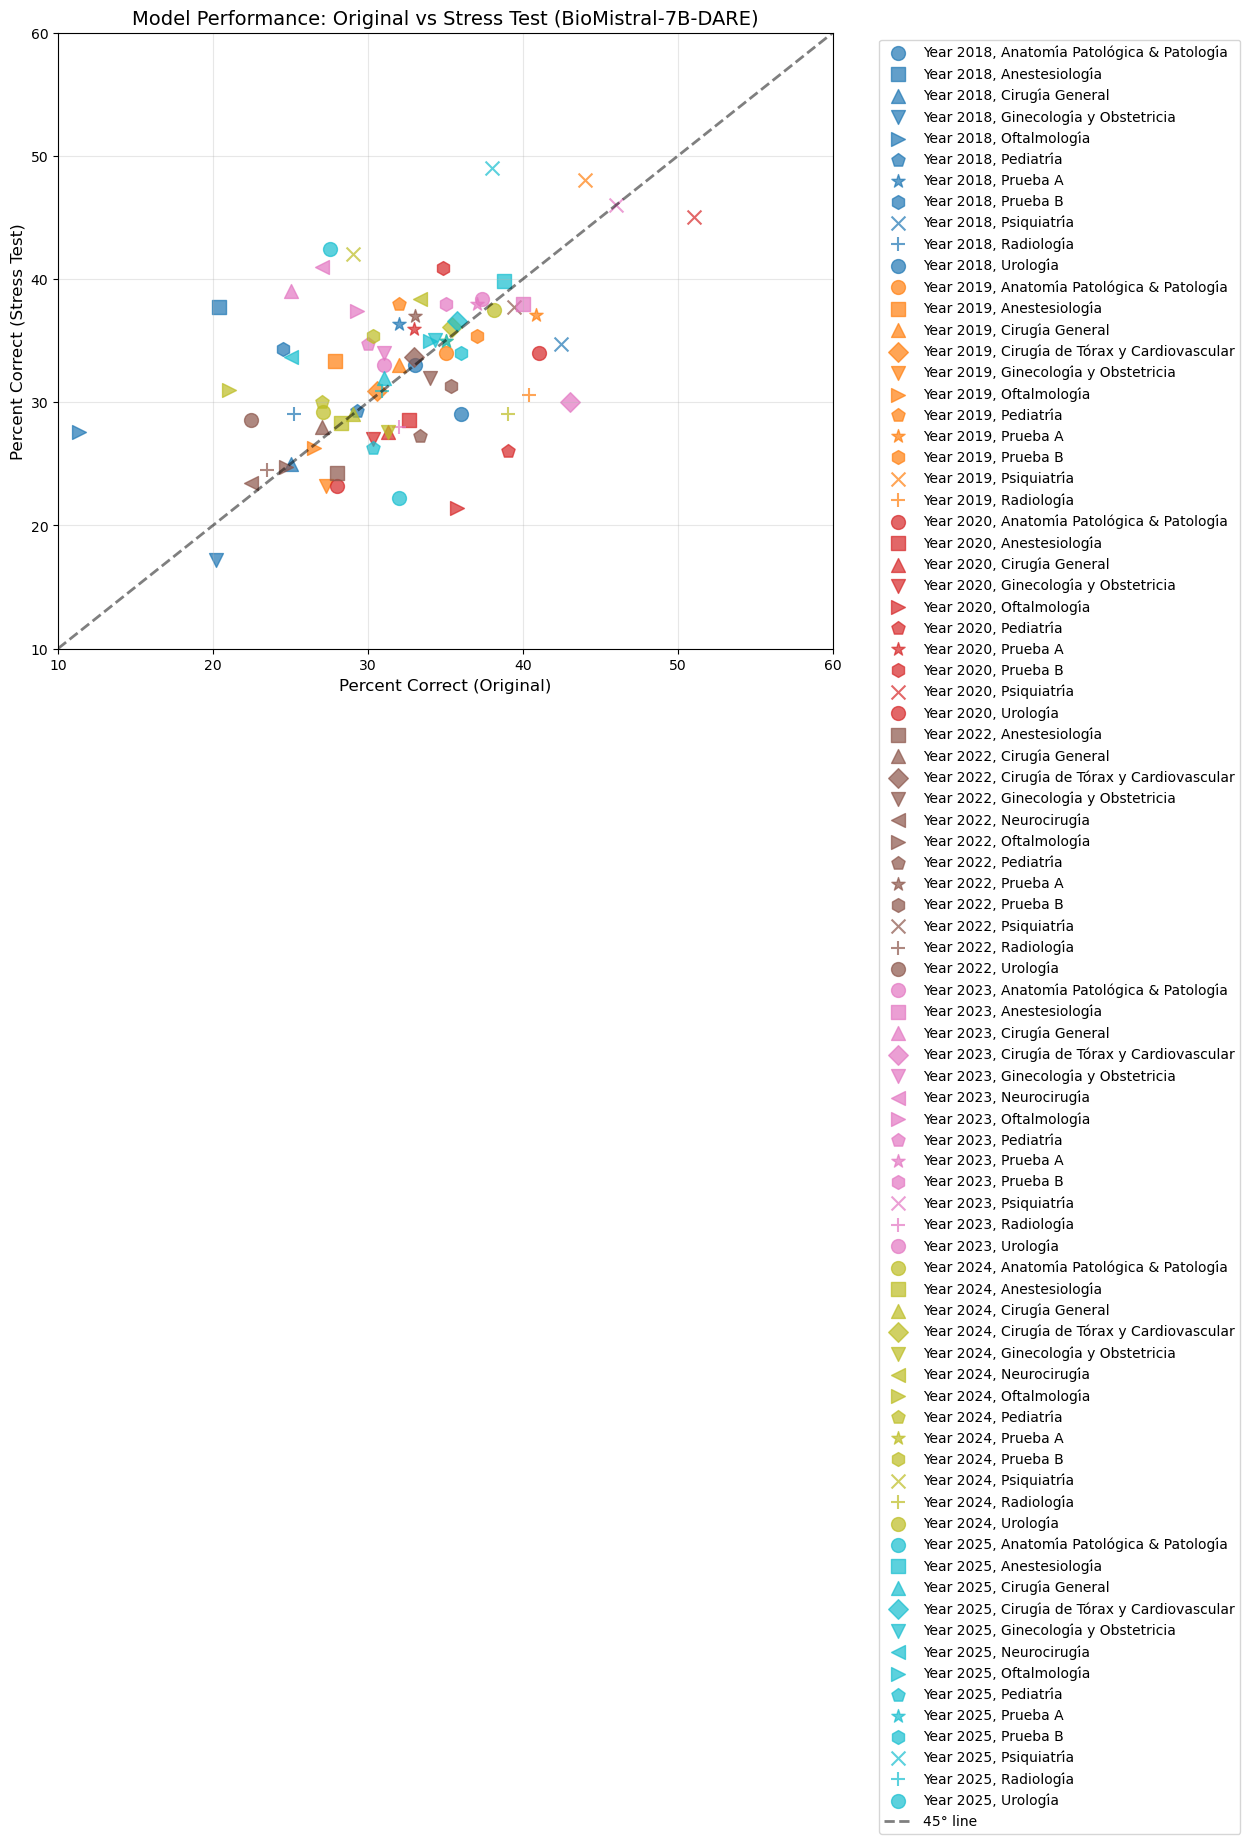

In [51]:
# Define marker styles for source_file
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h', 'x', '+']
marker_cycle = cycle(markers)
marker_map = {source: next(marker_cycle) for source in df_old_new_mistral['source_file'].unique()}

# Get unique years and source files
years = sorted(df_old_new_mistral['year'].unique())
source_files = sorted(df_old_new_mistral['source_file'].unique())

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 8))

# Create a color map for years
colors = plt.cm.tab10(np.linspace(0, 1, len(years)))
color_map = {year: colors[i] for i, year in enumerate(years)}

# Plot points colored by year with markers by source_file
for year in years:
    for source_file in source_files:
        mask = (df_old_new_mistral['year'] == year) & (df_old_new_mistral['source_file'] == source_file)
        data = df_old_new_mistral[mask]
        if len(data) > 0:
            ax.scatter(
                data['percentage_correct_old'],
                data['percentage_correct_new'],
                marker=marker_map[source_file],
                color=color_map[year],
                s=100,
                alpha=0.7,
                label=f"Year {year}, {source_file}"
            )

# Add 45-degree line
ax.plot([10, 100], [10, 100], 'k--', label='45° line', linewidth=2, alpha=0.5)

# Set axis limits and labels
ax.set_xlim(10, 60)
ax.set_ylim(10, 60)
ax.set_xlabel('Percent Correct (Original)', fontsize=12)
ax.set_ylabel('Percent Correct (Stress Test)', fontsize=12)
ax.set_title('Model Performance: Original vs Stress Test (BioMistral-7B-DARE)', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

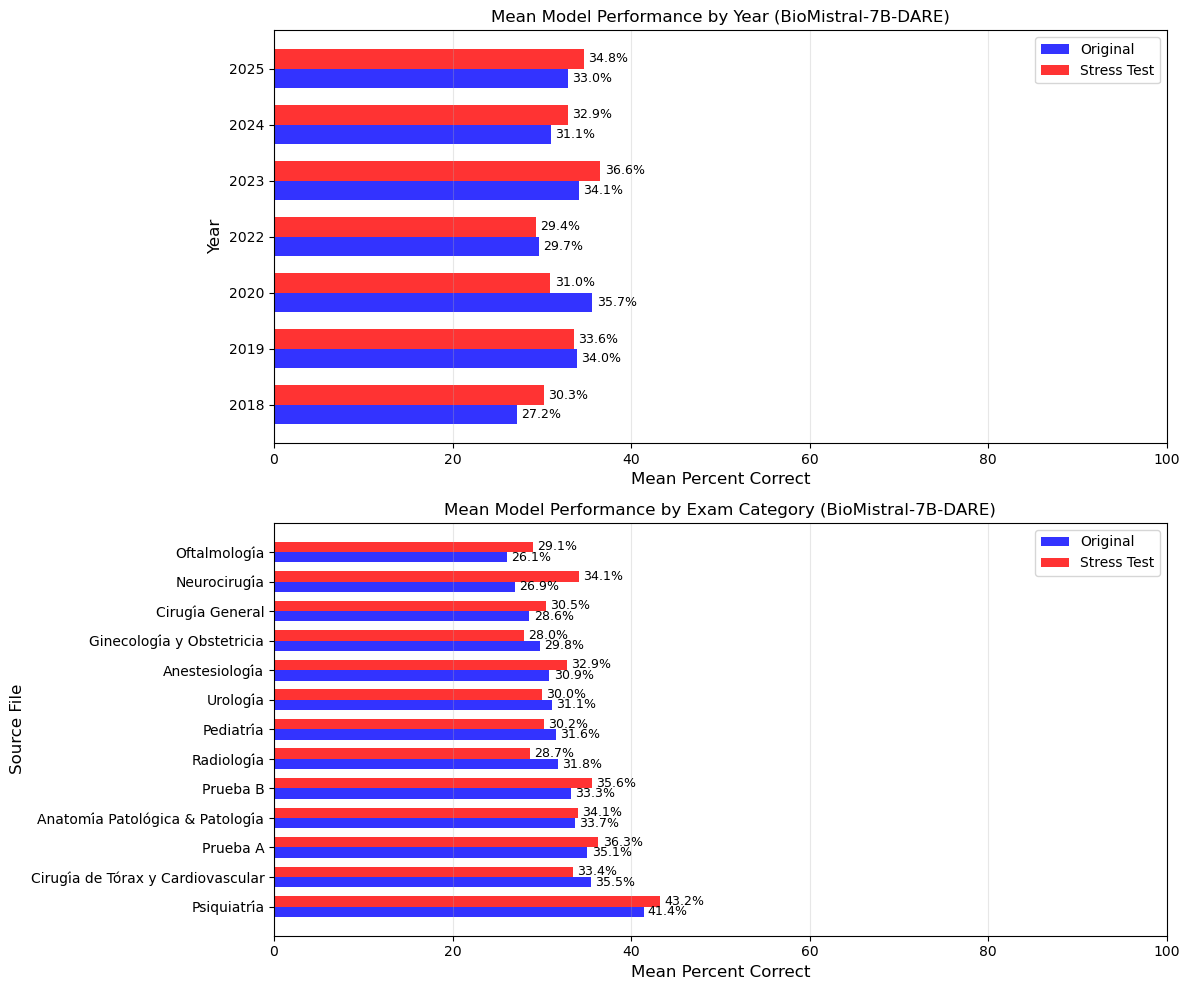

In [52]:
# Bar plot: Mean performance by year
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Group by year and calculate means
year_stats = df_old_new_mistral.groupby('year')[['percentage_correct_old', 'percentage_correct_new']].mean()

# Bar plot 1: Mean performance by year
x_pos = np.arange(len(year_stats.index))
width = 0.35

bars_old_year = axes[0].barh(
    x_pos - width/2,
    year_stats['percentage_correct_old'],
    height=width,
    label='Original',
    color='blue',
    alpha=0.8
)
bars_new_year = axes[0].barh(
    x_pos + width/2,
    year_stats['percentage_correct_new'],
    height=width,
    label='Stress Test',
    color='red',
    alpha=0.8
)
axes[0].bar_label(bars_old_year, fmt='%.1f%%', padding=3, fontsize=9)
axes[0].bar_label(bars_new_year, fmt='%.1f%%', padding=3, fontsize=9)
axes[0].set_ylabel('Year', fontsize=12)
axes[0].set_xlabel('Mean Percent Correct', fontsize=12)
axes[0].set_xlim(0, 100)
axes[0].set_title('Mean Model Performance by Year (BioMistral-7B-DARE)', fontsize=12)
axes[0].set_yticks(x_pos)
axes[0].set_yticklabels(year_stats.index)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='x')

# Bar plot 2: Mean performance by source_file
source_stats = df_old_new_mistral.groupby('source_file')[['percentage_correct_old', 'percentage_correct_new']].mean().sort_values('percentage_correct_old', ascending=False)

x_pos = np.arange(len(source_stats.index))
bars_old_source = axes[1].barh(
    x_pos - width/2,
    source_stats['percentage_correct_old'],
    height=width,
    label='Original',
    color='blue',
    alpha=0.8
)
bars_new_source = axes[1].barh(
    x_pos + width/2,
    source_stats['percentage_correct_new'],
    height=width,
    label='Stress Test',
    color='red',
    alpha=0.8
)
axes[1].bar_label(bars_old_source, fmt='%.1f%%', padding=3, fontsize=9)
axes[1].bar_label(bars_new_source, fmt='%.1f%%', padding=3, fontsize=9)
axes[1].set_ylabel('Source File', fontsize=12)
axes[1].set_xlabel('Mean Percent Correct', fontsize=12)
axes[1].set_xlim(0, 100)
axes[1].set_title('Mean Model Performance by Exam Category (BioMistral-7B-DARE)', fontsize=12)
axes[1].set_yticks(x_pos)
axes[1].set_yticklabels(source_stats.index)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

In [30]:
# Prepare data for paired tests
# Remove rows with missing values in either column
data_paired = df_old_new_mistral[['percentage_correct_old', 'percentage_correct_new']].dropna()

print("=" * 70)
print("STATISTICAL TESTS: Original vs Stress Test Performance")
print("=" * 70)

# 1. Check normality of differences
differences = data_paired['percentage_correct_new'] - data_paired['percentage_correct_old']
stat_shapiro, p_shapiro = stats.shapiro(differences)
print(f"\n1. NORMALITY TEST (Shapiro-Wilk on differences):")
print(f"   Test Statistic: {stat_shapiro:.4f}")
print(f"   p-value: {p_shapiro:.6f}")
print(f"   Result: {'Data is normally distributed' if p_shapiro > 0.05 else 'Data deviates from normality'} (α=0.05)")

# 2. Paired t-test (parametric)
t_stat, p_ttest = stats.ttest_rel(data_paired['percentage_correct_new'], 
                                   data_paired['percentage_correct_old'])
mean_diff = differences.mean()
std_diff = differences.std()

print(f"\n2. PAIRED T-TEST (parametric):")
print(f"   Mean difference (Stress Test - Original): {mean_diff:.4f}%")
print(f"   Std deviation of differences: {std_diff:.4f}%")
print(f"   t-statistic: {t_stat:.4f}")
print(f"   p-value: {p_ttest:.6f}")
print(f"   Result: {'SIGNIFICANT difference' if p_ttest < 0.05 else 'No significant difference'} (α=0.05)")

# 3. Wilcoxon Signed-Rank Test (non-parametric alternative)
w_stat, p_wilcox = stats.wilcoxon(data_paired['percentage_correct_new'], 
                                    data_paired['percentage_correct_old'])
print(f"\n3. WILCOXON SIGNED-RANK TEST (non-parametric alternative):")
print(f"   W-statistic: {w_stat:.4f}")
print(f"   p-value: {p_wilcox:.6f}")
print(f"   Result: {'SIGNIFICANT difference' if p_wilcox < 0.05 else 'No significant difference'} (α=0.05)")

# 4. Effect size (Cohen's d for paired samples)
cohens_d = mean_diff / std_diff
print(f"\n4. EFFECT SIZE (Cohen's d):")
print(f"   Cohen's d: {cohens_d:.4f}")
if abs(cohens_d) < 0.2:
    effect_interpretation = "negligible"
elif abs(cohens_d) < 0.5:
    effect_interpretation = "small"
elif abs(cohens_d) < 0.8:
    effect_interpretation = "medium"
else:
    effect_interpretation = "large"
print(f"   Interpretation: {effect_interpretation.upper()} effect")

# 5. Descriptive statistics
print(f"\n5. DESCRIPTIVE STATISTICS:")
print(f"   N (paired observations): {len(data_paired)}")
print(f"   Original - Mean: {data_paired['percentage_correct_old'].mean():.2f}%, Std: {data_paired['percentage_correct_old'].std():.2f}%")
print(f"   Stress Test - Mean: {data_paired['percentage_correct_new'].mean():.2f}%, Std: {data_paired['percentage_correct_new'].std():.2f}%")

# Count improvements/declines
improvements = (differences > 0).sum()
declines = (differences < 0).sum()
no_change = (differences == 0).sum()

print(f"\n6. DIRECTION OF CHANGE:")
print(f"   Improved (Stress Test > Original): {improvements} ({100*improvements/len(data_paired):.1f}%)")
print(f"   Declined (Stress Test < Original): {declines} ({100*declines/len(data_paired):.1f}%)")
print(f"   No change: {no_change} ({100*no_change/len(data_paired):.1f}%)")

print("\n" + "=" * 70)
print("RECOMMENDATION:")
print("=" * 70)
if p_shapiro > 0.05:
    print("✓ Data appears normally distributed, paired t-test is appropriate.")
else:
    print("✗ Data deviates from normality. Consider using the Wilcoxon test.")
    print("  Both tests are shown above for comparison.")
print("=" * 70)

STATISTICAL TESTS: Original vs Stress Test Performance

1. NORMALITY TEST (Shapiro-Wilk on differences):
   Test Statistic: 0.9655
   p-value: 0.025079
   Result: Data deviates from normality (α=0.05)

2. PAIRED T-TEST (parametric):
   Mean difference (Stress Test - Original): 0.7095%
   Std deviation of differences: 6.4016%
   t-statistic: 1.0098
   p-value: 0.315584
   Result: No significant difference (α=0.05)

3. WILCOXON SIGNED-RANK TEST (non-parametric alternative):
   W-statistic: 1201.0000
   p-value: 0.411086
   Result: No significant difference (α=0.05)

4. EFFECT SIZE (Cohen's d):
   Cohen's d: 0.1108
   Interpretation: NEGLIGIBLE effect

5. DESCRIPTIVE STATISTICS:
   N (paired observations): 83
   Original - Mean: 32.07%, Std: 6.43%
   Stress Test - Mean: 32.78%, Std: 6.18%

6. DIRECTION OF CHANGE:
   Improved (Stress Test > Original): 42 (50.6%)
   Declined (Stress Test < Original): 31 (37.3%)
   No change: 10 (12.0%)

RECOMMENDATION:
✗ Data deviates from normality. Consid

In [31]:
# Stratified analysis by YEAR
print("\n" + "=" * 90)
print("STRATIFIED ANALYSIS BY YEAR")
print("=" * 90)

results_by_year = []

for year in sorted(df_old_new_mistral['year'].unique()):
    year_data = df_old_new_mistral[df_old_new_mistral['year'] == year][['percentage_correct_old', 'percentage_correct_new']].dropna()
    
    if len(year_data) < 2:
        continue
    
    year_diff = year_data['percentage_correct_new'] - year_data['percentage_correct_old']
    t_stat_y, p_ttest_y = stats.ttest_rel(year_data['percentage_correct_new'], year_data['percentage_correct_old'])
    w_stat_y, p_wilcox_y = stats.wilcoxon(year_data['percentage_correct_new'], year_data['percentage_correct_old'])
    cohens_d_y = year_diff.mean() / year_diff.std() if year_diff.std() > 0 else 0
    
    results_by_year.append({
        'Year': year,
        'N': len(year_data),
        'Mean_Diff': year_diff.mean(),
        'Std_Diff': year_diff.std(),
        'T_stat': t_stat_y,
        'P_ttest': p_ttest_y,
        'P_wilcox': p_wilcox_y,
        'Cohens_d': cohens_d_y,
        'Original_Mean': year_data['percentage_correct_old'].mean(),
        'Stress_Mean': year_data['percentage_correct_new'].mean()
    })

results_by_year_df = pd.DataFrame(results_by_year)

print("\nYear-by-Year Summary:")
print("-" * 90)
for idx, row in results_by_year_df.iterrows():
    sig_ttest = "***" if row['P_ttest'] < 0.05 else ""
    sig_wilcox = "***" if row['P_wilcox'] < 0.05 else ""
    print(f"Year {int(row['Year'])} (N={int(row['N'])}):")
    print(f"  Original: {row['Original_Mean']:.2f}% → Stress: {row['Stress_Mean']:.2f}% (Δ = {row['Mean_Diff']:+.2f}%)")
    print(f"  T-test p-value: {row['P_ttest']:.4f} {sig_ttest}  |  Wilcoxon p-value: {row['P_wilcox']:.4f} {sig_wilcox}")
    print(f"  Cohen's d: {row['Cohens_d']:.4f}")
    print()

# Stratified analysis by SOURCE FILE
print("=" * 90)
print("STRATIFIED ANALYSIS BY SOURCE FILE (EXAM CATEGORY)")
print("=" * 90)

results_by_source = []

for source_file in sorted(df_old_new_mistral['source_file'].unique()):
    source_data = df_old_new_mistral[df_old_new_mistral['source_file'] == source_file][['percentage_correct_old', 'percentage_correct_new']].dropna()
    
    if len(source_data) < 2:
        continue
    
    source_diff = source_data['percentage_correct_new'] - source_data['percentage_correct_old']
    t_stat_s, p_ttest_s = stats.ttest_rel(source_data['percentage_correct_new'], source_data['percentage_correct_old'])
    w_stat_s, p_wilcox_s = stats.wilcoxon(source_data['percentage_correct_new'], source_data['percentage_correct_old'])
    cohens_d_s = source_diff.mean() / source_diff.std() if source_diff.std() > 0 else 0
    
    results_by_source.append({
        'Source_File': source_file,
        'N': len(source_data),
        'Mean_Diff': source_diff.mean(),
        'Std_Diff': source_diff.std(),
        'T_stat': t_stat_s,
        'P_ttest': p_ttest_s,
        'P_wilcox': p_wilcox_s,
        'Cohens_d': cohens_d_s,
        'Original_Mean': source_data['percentage_correct_old'].mean(),
        'Stress_Mean': source_data['percentage_correct_new'].mean()
    })

results_by_source_df = pd.DataFrame(results_by_source).sort_values('Original_Mean', ascending=False)

print("\nSource File-by-Source File Summary:")
print("-" * 90)
for idx, row in results_by_source_df.iterrows():
    sig_ttest = "***" if row['P_ttest'] < 0.05 else ""
    sig_wilcox = "***" if row['P_wilcox'] < 0.05 else ""
    print(f"{row['Source_File']} (N={int(row['N'])}):")
    print(f"  Original: {row['Original_Mean']:.2f}% → Stress: {row['Stress_Mean']:.2f}% (Δ = {row['Mean_Diff']:+.2f}%)")
    print(f"  T-test p-value: {row['P_ttest']:.4f} {sig_ttest}  |  Wilcoxon p-value: {row['P_wilcox']:.4f} {sig_wilcox}")
    print(f"  Cohen's d: {row['Cohens_d']:.4f}")
    print()

print("=" * 90)
print("LEGEND: *** indicates p < 0.05 (statistically significant)")
print("=" * 90)


STRATIFIED ANALYSIS BY YEAR

Year-by-Year Summary:
------------------------------------------------------------------------------------------
Year 2018 (N=11):
  Original: 27.22% → Stress: 30.29% (Δ = +3.07%)
  T-test p-value: 0.2543   |  Wilcoxon p-value: 0.3125 
  Cohen's d: 0.3647

Year 2019 (N=11):
  Original: 33.95% → Stress: 33.62% (Δ = -0.33%)
  T-test p-value: 0.8158   |  Wilcoxon p-value: 0.9150 
  Cohen's d: -0.0721

Year 2020 (N=10):
  Original: 35.67% → Stress: 30.96% (Δ = -4.71%)
  T-test p-value: 0.0399 ***  |  Wilcoxon p-value: 0.0488 ***
  Cohen's d: -0.7591

Year 2022 (N=12):
  Original: 29.68% → Stress: 29.38% (Δ = -0.30%)
  T-test p-value: 0.7654   |  Wilcoxon p-value: 0.7471 
  Cohen's d: -0.0883

Year 2023 (N=13):
  Original: 34.13% → Stress: 36.57% (Δ = +2.44%)
  T-test p-value: 0.2417   |  Wilcoxon p-value: 0.1592 
  Cohen's d: 0.3416

Year 2024 (N=13):
  Original: 31.07% → Stress: 32.95% (Δ = +1.88%)
  T-test p-value: 0.2643   |  Wilcoxon p-value: 0.2012 
  Coh

# 05.MediPhi-Instruct

In [32]:
df_old_medphi = pd.read_pickle(f'/Users/rodrigocarrillo/Documents/Natural Language Processing Projects/Examen Residentado Peru/02.LLMs Results/03.MediPhi-Instruct/{file_name}')
df_old_medphi = df_old_medphi.rename(columns={"count_of_matches": "count_of_matches_old", "total_rows": "total_rows_old", "percent_correct": "percentage_correct_old"})
df_old_medphi.head()

,source_file,year,count_of_matches_old,total_rows_old,percentage_correct_old,model_name
0,Anatomía Patológica & Patología,2018,36,100,36.00,MediPhi-Instruct 3.8B
1,Anatomía Patológica & Patología,2019,29,100,29.00,MediPhi-Instruct 3.8B
2,Anatomía Patológica & Patología,2020,33,99,33.33,MediPhi-Instruct 3.8B
3,Anatomía Patológica & Patología,2023,45,100,45.00,MediPhi-Instruct 3.8B
4,Anatomía Patológica & Patología,2024,39,100,39.00,MediPhi-Instruct 3.8B


In [33]:
df_new_medphi = pd.read_pickle(f'/Users/rodrigocarrillo/Documents/Natural Language Processing Projects/Examen Residentado Peru/02.LLMs Results/Reorder Options/05.MediPhi-Instruct/{file_name}')
df_new_medphi = df_new_medphi.rename(columns={"count_of_matches": "count_of_matches_new", "total_rows": "total_rows_new", "percent_correct": "percentage_correct_new"})
df_new_medphi.head()

,source_file,year,count_of_matches_new,total_rows_new,percentage_correct_new,model_name
0,Anatomía Patológica & Patología,2018,38,100,38.0,MediPhi-Instruct 3.8B
1,Anatomía Patológica & Patología,2019,28,100,28.0,MediPhi-Instruct 3.8B
2,Anatomía Patológica & Patología,2020,33,100,33.0,MediPhi-Instruct 3.8B
3,Anatomía Patológica & Patología,2023,35,100,35.0,MediPhi-Instruct 3.8B
4,Anatomía Patológica & Patología,2024,40,100,40.0,MediPhi-Instruct 3.8B


In [34]:
df_old_new_medphi = pd.merge(df_old_medphi, df_new_medphi, on=["source_file", "year", "model_name"], how="outer")
df_old_new_medphi

,source_file,year,count_of_matches_old,total_rows_old,percentage_correct_old,model_name,count_of_matches_new,total_rows_new,percentage_correct_new
0,Anatomía Patológica & Patología,2018,36,100,36.00,MediPhi-Instruct 3.8B,38,100,38.00
1,Anatomía Patológica & Patología,2019,29,100,29.00,MediPhi-Instruct 3.8B,28,100,28.00
2,Anatomía Patológica & Patología,2020,33,99,33.33,MediPhi-Instruct 3.8B,33,100,33.00
3,Anatomía Patológica & Patología,2023,45,100,45.00,MediPhi-Instruct 3.8B,35,100,35.00
4,Anatomía Patológica & Patología,2024,39,100,39.00,MediPhi-Instruct 3.8B,40,100,40.00
...,...,...,...,...,...,...,...,...,...
78,Urología,2020,28,100,28.00,MediPhi-Instruct 3.8B,32,100,32.00
79,Urología,2022,32,100,32.00,MediPhi-Instruct 3.8B,42,100,42.00
80,Urología,2023,50,100,50.00,MediPhi-Instruct 3.8B,43,99,43.43
81,Urología,2024,44,100,44.00,MediPhi-Instruct 3.8B,31,100,31.00


/var/folders/0p/pq1qfwzj0bz0b4wsym558qgw0000gn/T/ipykernel_64895/2574078846.py:45: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


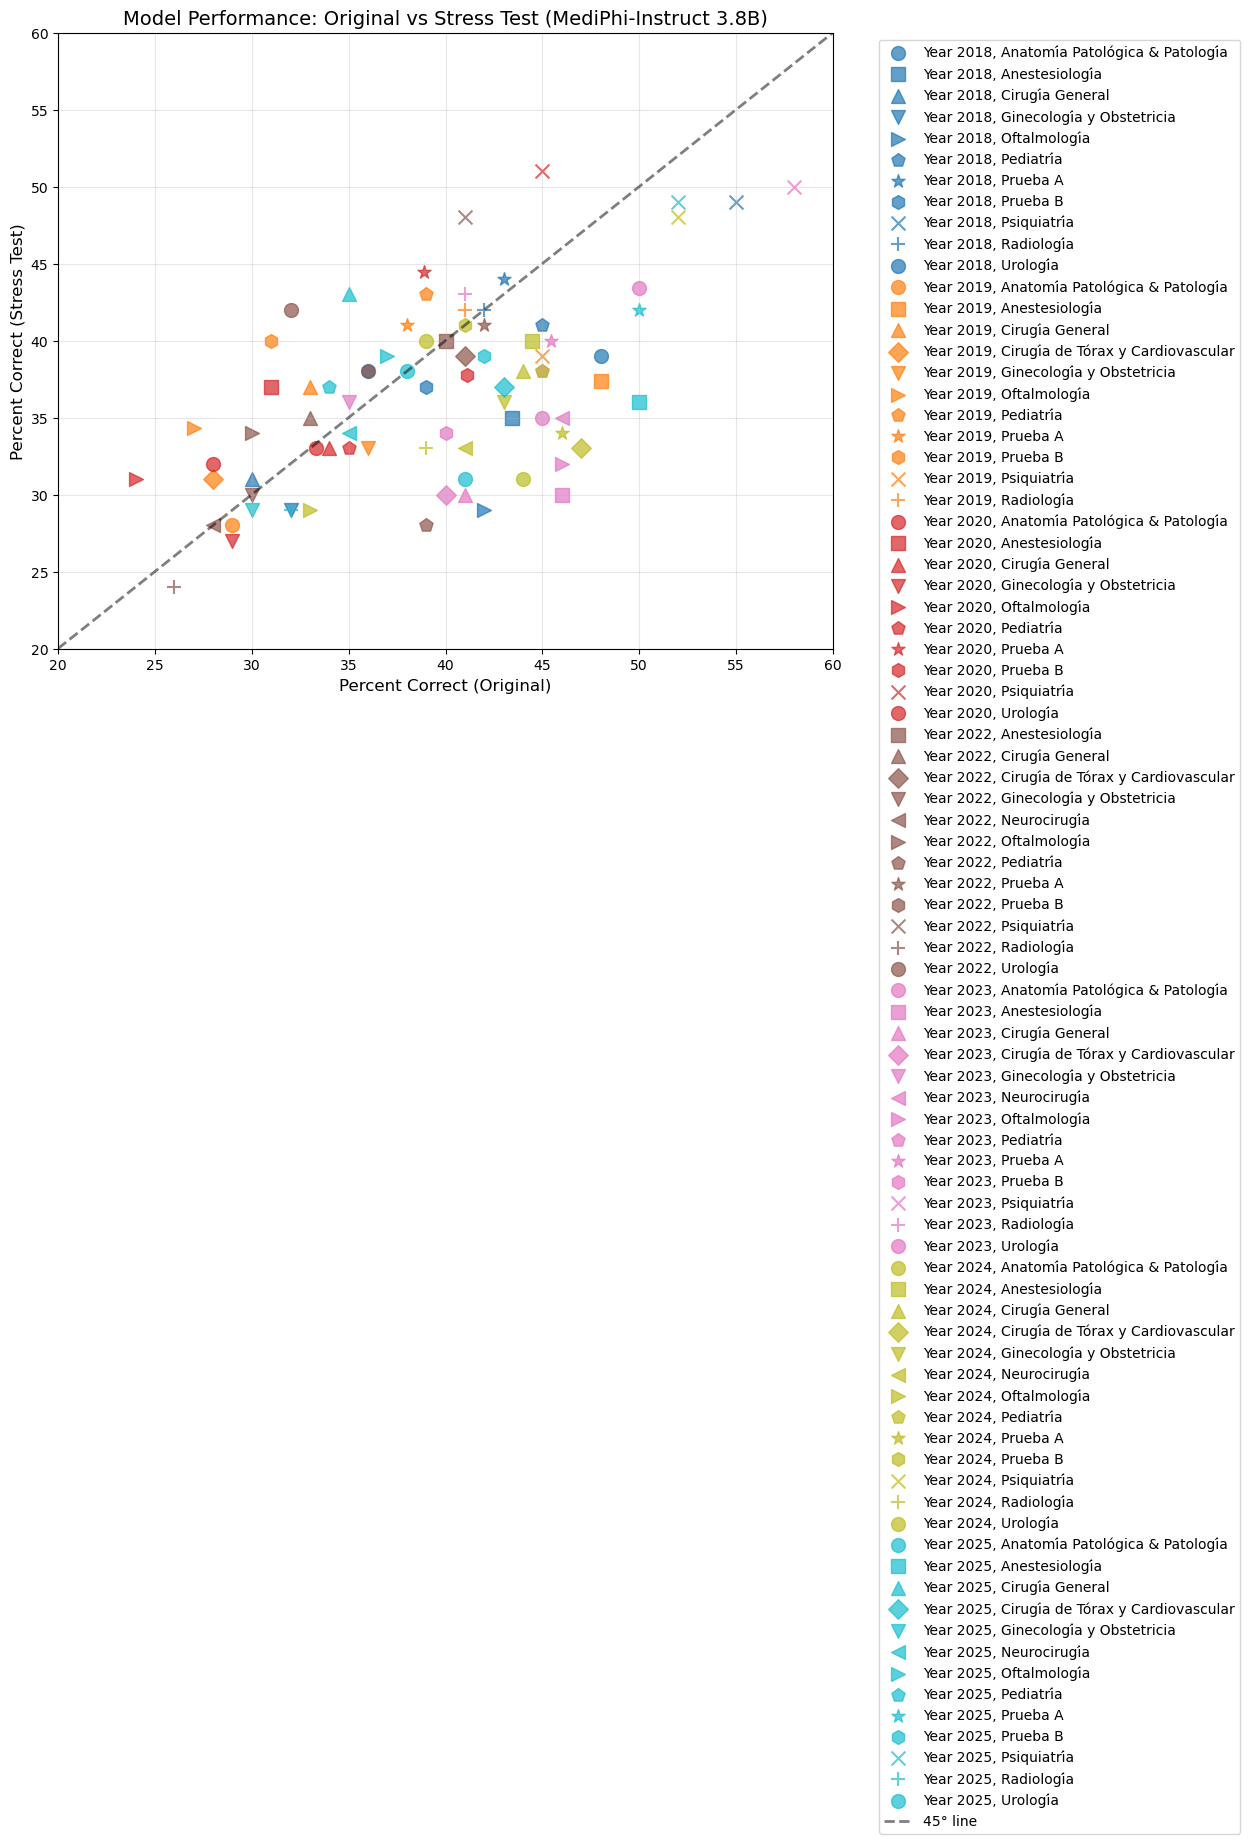

In [54]:
# Define marker styles for source_file
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h', 'x', '+']
marker_cycle = cycle(markers)
marker_map = {source: next(marker_cycle) for source in df_old_new_medphi['source_file'].unique()}

# Get unique years and source files
years = sorted(df_old_new_medphi['year'].unique())
source_files = sorted(df_old_new_medphi['source_file'].unique())

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 8))

# Create a color map for years
colors = plt.cm.tab10(np.linspace(0, 1, len(years)))
color_map = {year: colors[i] for i, year in enumerate(years)}

# Plot points colored by year with markers by source_file
for year in years:
    for source_file in source_files:
        mask = (df_old_new_medphi['year'] == year) & (df_old_new_medphi['source_file'] == source_file)
        data = df_old_new_medphi[mask]
        if len(data) > 0:
            ax.scatter(
                data['percentage_correct_old'],
                data['percentage_correct_new'],
                marker=marker_map[source_file],
                color=color_map[year],
                s=100,
                alpha=0.7,
                label=f"Year {year}, {source_file}"
            )

# Add 45-degree line
ax.plot([20, 100], [20, 100], 'k--', label='45° line', linewidth=2, alpha=0.5)

# Set axis limits and labels
ax.set_xlim(20, 60)
ax.set_ylim(20, 60)
ax.set_xlabel('Percent Correct (Original)', fontsize=12)
ax.set_ylabel('Percent Correct (Stress Test)', fontsize=12)
ax.set_title('Model Performance: Original vs Stress Test (MediPhi-Instruct 3.8B)', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

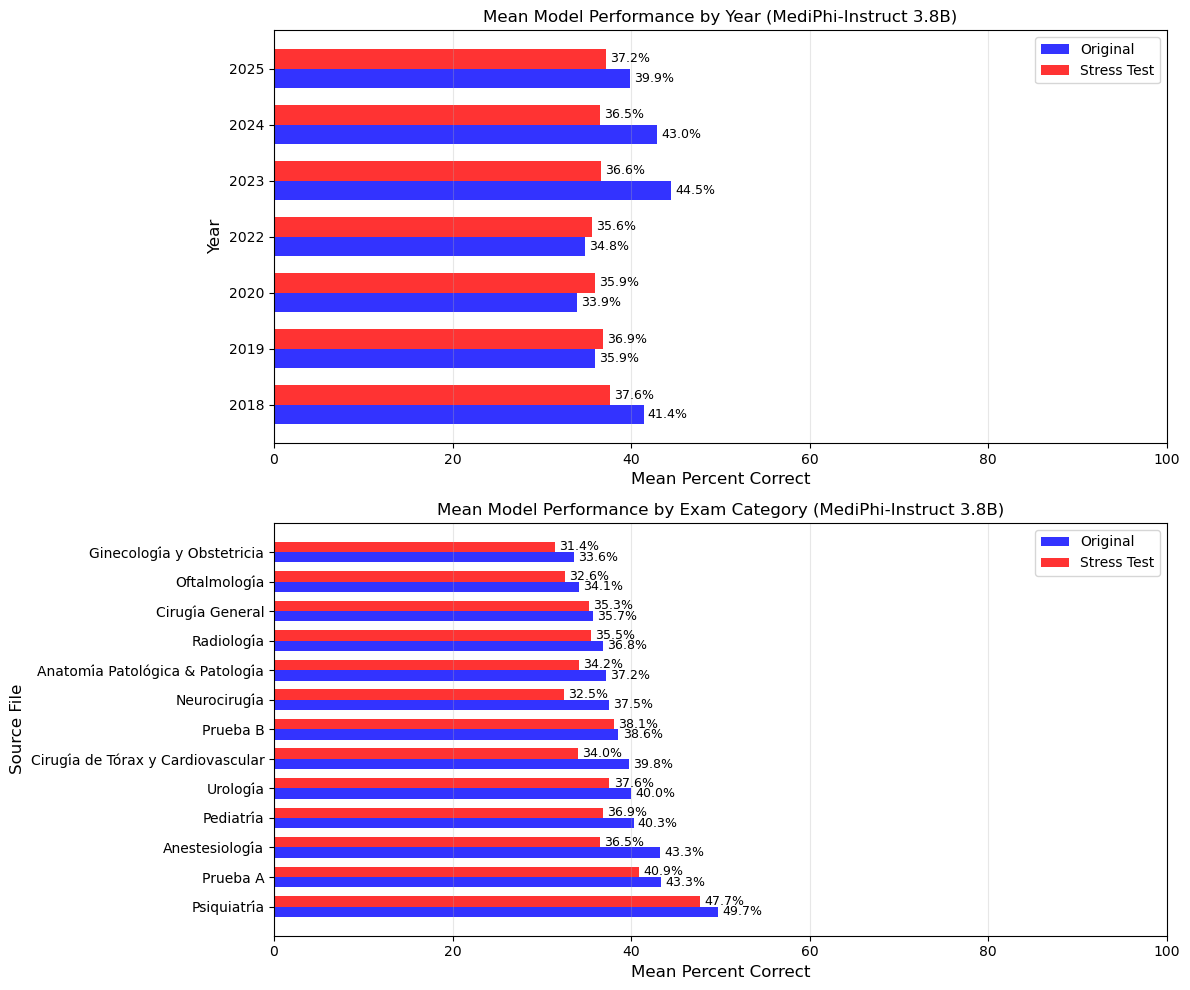

In [55]:
# Bar plot: Mean performance by year
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Group by year and calculate means
year_stats = df_old_new_medphi.groupby('year')[['percentage_correct_old', 'percentage_correct_new']].mean()

# Bar plot 1: Mean performance by year
x_pos = np.arange(len(year_stats.index))
width = 0.35

bars_old_year = axes[0].barh(
    x_pos - width/2,
    year_stats['percentage_correct_old'],
    height=width,
    label='Original',
    color='blue',
    alpha=0.8
)
bars_new_year = axes[0].barh(
    x_pos + width/2,
    year_stats['percentage_correct_new'],
    height=width,
    label='Stress Test',
    color='red',
    alpha=0.8
)
axes[0].bar_label(bars_old_year, fmt='%.1f%%', padding=3, fontsize=9)
axes[0].bar_label(bars_new_year, fmt='%.1f%%', padding=3, fontsize=9)
axes[0].set_ylabel('Year', fontsize=12)
axes[0].set_xlabel('Mean Percent Correct', fontsize=12)
axes[0].set_xlim(0, 100)
axes[0].set_title('Mean Model Performance by Year (MediPhi-Instruct 3.8B)', fontsize=12)
axes[0].set_yticks(x_pos)
axes[0].set_yticklabels(year_stats.index)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='x')

# Bar plot 2: Mean performance by source_file
source_stats = df_old_new_medphi.groupby('source_file')[['percentage_correct_old', 'percentage_correct_new']].mean().sort_values('percentage_correct_old', ascending=False)

x_pos = np.arange(len(source_stats.index))
bars_old_source = axes[1].barh(
    x_pos - width/2,
    source_stats['percentage_correct_old'],
    height=width,
    label='Original',
    color='blue',
    alpha=0.8
)
bars_new_source = axes[1].barh(
    x_pos + width/2,
    source_stats['percentage_correct_new'],
    height=width,
    label='Stress Test',
    color='red',
    alpha=0.8
)
axes[1].bar_label(bars_old_source, fmt='%.1f%%', padding=3, fontsize=9)
axes[1].bar_label(bars_new_source, fmt='%.1f%%', padding=3, fontsize=9)
axes[1].set_ylabel('Source File', fontsize=12)
axes[1].set_xlabel('Mean Percent Correct', fontsize=12)
axes[1].set_xlim(0, 100)
axes[1].set_title('Mean Model Performance by Exam Category (MediPhi-Instruct 3.8B)', fontsize=12)
axes[1].set_yticks(x_pos)
axes[1].set_yticklabels(source_stats.index)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

In [37]:
# Prepare data for paired tests
# Remove rows with missing values in either column
data_paired = df_old_new_medphi[['percentage_correct_old', 'percentage_correct_new']].dropna()

print("=" * 70)
print("STATISTICAL TESTS: Original vs Stress Test Performance")
print("=" * 70)

# 1. Check normality of differences
differences = data_paired['percentage_correct_new'] - data_paired['percentage_correct_old']
stat_shapiro, p_shapiro = stats.shapiro(differences)
print(f"\n1. NORMALITY TEST (Shapiro-Wilk on differences):")
print(f"   Test Statistic: {stat_shapiro:.4f}")
print(f"   p-value: {p_shapiro:.6f}")
print(f"   Result: {'Data is normally distributed' if p_shapiro > 0.05 else 'Data deviates from normality'} (α=0.05)")

# 2. Paired t-test (parametric)
t_stat, p_ttest = stats.ttest_rel(data_paired['percentage_correct_new'], 
                                   data_paired['percentage_correct_old'])
mean_diff = differences.mean()
std_diff = differences.std()

print(f"\n2. PAIRED T-TEST (parametric):")
print(f"   Mean difference (Stress Test - Original): {mean_diff:.4f}%")
print(f"   Std deviation of differences: {std_diff:.4f}%")
print(f"   t-statistic: {t_stat:.4f}")
print(f"   p-value: {p_ttest:.6f}")
print(f"   Result: {'SIGNIFICANT difference' if p_ttest < 0.05 else 'No significant difference'} (α=0.05)")

# 3. Wilcoxon Signed-Rank Test (non-parametric alternative)
w_stat, p_wilcox = stats.wilcoxon(data_paired['percentage_correct_new'], 
                                    data_paired['percentage_correct_old'])
print(f"\n3. WILCOXON SIGNED-RANK TEST (non-parametric alternative):")
print(f"   W-statistic: {w_stat:.4f}")
print(f"   p-value: {p_wilcox:.6f}")
print(f"   Result: {'SIGNIFICANT difference' if p_wilcox < 0.05 else 'No significant difference'} (α=0.05)")

# 4. Effect size (Cohen's d for paired samples)
cohens_d = mean_diff / std_diff
print(f"\n4. EFFECT SIZE (Cohen's d):")
print(f"   Cohen's d: {cohens_d:.4f}")
if abs(cohens_d) < 0.2:
    effect_interpretation = "negligible"
elif abs(cohens_d) < 0.5:
    effect_interpretation = "small"
elif abs(cohens_d) < 0.8:
    effect_interpretation = "medium"
else:
    effect_interpretation = "large"
print(f"   Interpretation: {effect_interpretation.upper()} effect")

# 5. Descriptive statistics
print(f"\n5. DESCRIPTIVE STATISTICS:")
print(f"   N (paired observations): {len(data_paired)}")
print(f"   Original - Mean: {data_paired['percentage_correct_old'].mean():.2f}%, Std: {data_paired['percentage_correct_old'].std():.2f}%")
print(f"   Stress Test - Mean: {data_paired['percentage_correct_new'].mean():.2f}%, Std: {data_paired['percentage_correct_new'].std():.2f}%")

# Count improvements/declines
improvements = (differences > 0).sum()
declines = (differences < 0).sum()
no_change = (differences == 0).sum()

print(f"\n6. DIRECTION OF CHANGE:")
print(f"   Improved (Stress Test > Original): {improvements} ({100*improvements/len(data_paired):.1f}%)")
print(f"   Declined (Stress Test < Original): {declines} ({100*declines/len(data_paired):.1f}%)")
print(f"   No change: {no_change} ({100*no_change/len(data_paired):.1f}%)")

print("\n" + "=" * 70)
print("RECOMMENDATION:")
print("=" * 70)
if p_shapiro > 0.05:
    print("✓ Data appears normally distributed, paired t-test is appropriate.")
else:
    print("✗ Data deviates from normality. Consider using the Wilcoxon test.")
    print("  Both tests are shown above for comparison.")
print("=" * 70)

STATISTICAL TESTS: Original vs Stress Test Performance

1. NORMALITY TEST (Shapiro-Wilk on differences):
   Test Statistic: 0.9847
   p-value: 0.428320
   Result: Data is normally distributed (α=0.05)

2. PAIRED T-TEST (parametric):
   Mean difference (Stress Test - Original): -2.7023%
   Std deviation of differences: 6.0892%
   t-statistic: -4.0431
   p-value: 0.000118
   Result: SIGNIFICANT difference (α=0.05)

3. WILCOXON SIGNED-RANK TEST (non-parametric alternative):
   W-statistic: 799.0000
   p-value: 0.000356
   Result: SIGNIFICANT difference (α=0.05)

4. EFFECT SIZE (Cohen's d):
   Cohen's d: -0.4438
   Interpretation: SMALL effect

5. DESCRIPTIVE STATISTICS:
   N (paired observations): 83
   Original - Mean: 39.32%, Std: 7.16%
   Stress Test - Mean: 36.62%, Std: 5.85%

6. DIRECTION OF CHANGE:
   Improved (Stress Test > Original): 26 (31.3%)
   Declined (Stress Test < Original): 51 (61.4%)
   No change: 6 (7.2%)

RECOMMENDATION:
✓ Data appears normally distributed, paired t-tes

In [38]:
# Stratified analysis by YEAR
print("\n" + "=" * 90)
print("STRATIFIED ANALYSIS BY YEAR")
print("=" * 90)

results_by_year = []

for year in sorted(df_old_new_medphi['year'].unique()):
    year_data = df_old_new_medphi[df_old_new_medphi['year'] == year][['percentage_correct_old', 'percentage_correct_new']].dropna()
    
    if len(year_data) < 2:
        continue
    
    year_diff = year_data['percentage_correct_new'] - year_data['percentage_correct_old']
    t_stat_y, p_ttest_y = stats.ttest_rel(year_data['percentage_correct_new'], year_data['percentage_correct_old'])
    w_stat_y, p_wilcox_y = stats.wilcoxon(year_data['percentage_correct_new'], year_data['percentage_correct_old'])
    cohens_d_y = year_diff.mean() / year_diff.std() if year_diff.std() > 0 else 0
    
    results_by_year.append({
        'Year': year,
        'N': len(year_data),
        'Mean_Diff': year_diff.mean(),
        'Std_Diff': year_diff.std(),
        'T_stat': t_stat_y,
        'P_ttest': p_ttest_y,
        'P_wilcox': p_wilcox_y,
        'Cohens_d': cohens_d_y,
        'Original_Mean': year_data['percentage_correct_old'].mean(),
        'Stress_Mean': year_data['percentage_correct_new'].mean()
    })

results_by_year_df = pd.DataFrame(results_by_year)

print("\nYear-by-Year Summary:")
print("-" * 90)
for idx, row in results_by_year_df.iterrows():
    sig_ttest = "***" if row['P_ttest'] < 0.05 else ""
    sig_wilcox = "***" if row['P_wilcox'] < 0.05 else ""
    print(f"Year {int(row['Year'])} (N={int(row['N'])}):")
    print(f"  Original: {row['Original_Mean']:.2f}% → Stress: {row['Stress_Mean']:.2f}% (Δ = {row['Mean_Diff']:+.2f}%)")
    print(f"  T-test p-value: {row['P_ttest']:.4f} {sig_ttest}  |  Wilcoxon p-value: {row['P_wilcox']:.4f} {sig_wilcox}")
    print(f"  Cohen's d: {row['Cohens_d']:.4f}")
    print()

# Stratified analysis by SOURCE FILE
print("=" * 90)
print("STRATIFIED ANALYSIS BY SOURCE FILE (EXAM CATEGORY)")
print("=" * 90)

results_by_source = []

for source_file in sorted(df_old_new_medphi['source_file'].unique()):
    source_data = df_old_new_medphi[df_old_new_medphi['source_file'] == source_file][['percentage_correct_old', 'percentage_correct_new']].dropna()
    
    if len(source_data) < 2:
        continue
    
    source_diff = source_data['percentage_correct_new'] - source_data['percentage_correct_old']
    t_stat_s, p_ttest_s = stats.ttest_rel(source_data['percentage_correct_new'], source_data['percentage_correct_old'])
    w_stat_s, p_wilcox_s = stats.wilcoxon(source_data['percentage_correct_new'], source_data['percentage_correct_old'])
    cohens_d_s = source_diff.mean() / source_diff.std() if source_diff.std() > 0 else 0
    
    results_by_source.append({
        'Source_File': source_file,
        'N': len(source_data),
        'Mean_Diff': source_diff.mean(),
        'Std_Diff': source_diff.std(),
        'T_stat': t_stat_s,
        'P_ttest': p_ttest_s,
        'P_wilcox': p_wilcox_s,
        'Cohens_d': cohens_d_s,
        'Original_Mean': source_data['percentage_correct_old'].mean(),
        'Stress_Mean': source_data['percentage_correct_new'].mean()
    })

results_by_source_df = pd.DataFrame(results_by_source).sort_values('Original_Mean', ascending=False)

print("\nSource File-by-Source File Summary:")
print("-" * 90)
for idx, row in results_by_source_df.iterrows():
    sig_ttest = "***" if row['P_ttest'] < 0.05 else ""
    sig_wilcox = "***" if row['P_wilcox'] < 0.05 else ""
    print(f"{row['Source_File']} (N={int(row['N'])}):")
    print(f"  Original: {row['Original_Mean']:.2f}% → Stress: {row['Stress_Mean']:.2f}% (Δ = {row['Mean_Diff']:+.2f}%)")
    print(f"  T-test p-value: {row['P_ttest']:.4f} {sig_ttest}  |  Wilcoxon p-value: {row['P_wilcox']:.4f} {sig_wilcox}")
    print(f"  Cohen's d: {row['Cohens_d']:.4f}")
    print()

print("=" * 90)
print("LEGEND: *** indicates p < 0.05 (statistically significant)")
print("=" * 90)


STRATIFIED ANALYSIS BY YEAR

Year-by-Year Summary:
------------------------------------------------------------------------------------------
Year 2018 (N=11):
  Original: 41.40% → Stress: 37.64% (Δ = -3.77%)
  T-test p-value: 0.0278 ***  |  Wilcoxon p-value: 0.0312 ***
  Cohen's d: -0.7753

Year 2019 (N=11):
  Original: 35.91% → Stress: 36.88% (Δ = +0.97%)
  T-test p-value: 0.5889   |  Wilcoxon p-value: 0.4775 
  Cohen's d: 0.1684

Year 2020 (N=10):
  Original: 33.93% → Stress: 35.92% (Δ = +1.99%)
  T-test p-value: 0.1558   |  Wilcoxon p-value: 0.2207 
  Cohen's d: 0.4898

Year 2022 (N=12):
  Original: 34.83% → Stress: 35.58% (Δ = +0.75%)
  T-test p-value: 0.6265   |  Wilcoxon p-value: 0.5430 
  Cohen's d: 0.1445

Year 2023 (N=13):
  Original: 44.50% → Stress: 36.65% (Δ = -7.85%)
  T-test p-value: 0.0001 ***  |  Wilcoxon p-value: 0.0012 ***
  Cohen's d: -1.5191

Year 2024 (N=13):
  Original: 42.96% → Stress: 36.46% (Δ = -6.50%)
  T-test p-value: 0.0002 ***  |  Wilcoxon p-value: 0.001

# 06.OpenBioLLM-8B

In [39]:
df_old_openbiollm = pd.read_pickle(f'/Users/rodrigocarrillo/Documents/Natural Language Processing Projects/Examen Residentado Peru/02.LLMs Results/04.OpenBioLLM-8B/{file_name}')
df_old_openbiollm = df_old_openbiollm.rename(columns={"count_of_matches": "count_of_matches_old", "total_rows": "total_rows_old", "percent_correct": "percentage_correct_old"})
df_old_openbiollm.head()

,source_file,year,count_of_matches_old,total_rows_old,percentage_correct_old,model_name
0,Anatomía Patológica & Patología,2018,35,91,38.46,OpenBioLLM-8B
1,Anatomía Patológica & Patología,2019,32,92,34.78,OpenBioLLM-8B
2,Anatomía Patológica & Patología,2020,33,97,34.02,OpenBioLLM-8B
3,Anatomía Patológica & Patología,2023,32,97,32.99,OpenBioLLM-8B
4,Anatomía Patológica & Patología,2024,23,98,23.47,OpenBioLLM-8B


In [40]:
df_new_openbiollm = pd.read_pickle(f'/Users/rodrigocarrillo/Documents/Natural Language Processing Projects/Examen Residentado Peru/02.LLMs Results/Reorder Options/06.OpenBioLLM-8B/{file_name}')
df_new_openbiollm = df_new_openbiollm.rename(columns={"count_of_matches": "count_of_matches_new", "total_rows": "total_rows_new", "percent_correct": "percentage_correct_new"})
df_new_openbiollm.head()

,source_file,year,count_of_matches_new,total_rows_new,percentage_correct_new,model_name
0,Anatomía Patológica & Patología,2018,36,97,37.11,OpenBioLLM-8B
1,Anatomía Patológica & Patología,2019,34,94,36.17,OpenBioLLM-8B
2,Anatomía Patológica & Patología,2020,32,98,32.65,OpenBioLLM-8B
3,Anatomía Patológica & Patología,2023,32,93,34.41,OpenBioLLM-8B
4,Anatomía Patológica & Patología,2024,42,98,42.86,OpenBioLLM-8B


In [41]:
df_old_new_openbiollm = pd.merge(df_old_openbiollm, df_new_openbiollm, on=["source_file", "year", "model_name"], how="outer")
df_old_new_openbiollm

,source_file,year,count_of_matches_old,total_rows_old,percentage_correct_old,model_name,count_of_matches_new,total_rows_new,percentage_correct_new
0,Anatomía Patológica & Patología,2018,35,91,38.46,OpenBioLLM-8B,36,97,37.11
1,Anatomía Patológica & Patología,2019,32,92,34.78,OpenBioLLM-8B,34,94,36.17
2,Anatomía Patológica & Patología,2020,33,97,34.02,OpenBioLLM-8B,32,98,32.65
3,Anatomía Patológica & Patología,2023,32,97,32.99,OpenBioLLM-8B,32,93,34.41
4,Anatomía Patológica & Patología,2024,23,98,23.47,OpenBioLLM-8B,42,98,42.86
...,...,...,...,...,...,...,...,...,...
78,Urología,2020,35,93,37.63,OpenBioLLM-8B,33,93,35.48
79,Urología,2022,32,92,34.78,OpenBioLLM-8B,27,90,30.00
80,Urología,2023,20,91,21.98,OpenBioLLM-8B,33,93,35.48
81,Urología,2024,23,90,25.56,OpenBioLLM-8B,34,94,36.17


/var/folders/0p/pq1qfwzj0bz0b4wsym558qgw0000gn/T/ipykernel_64895/1164362392.py:45: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


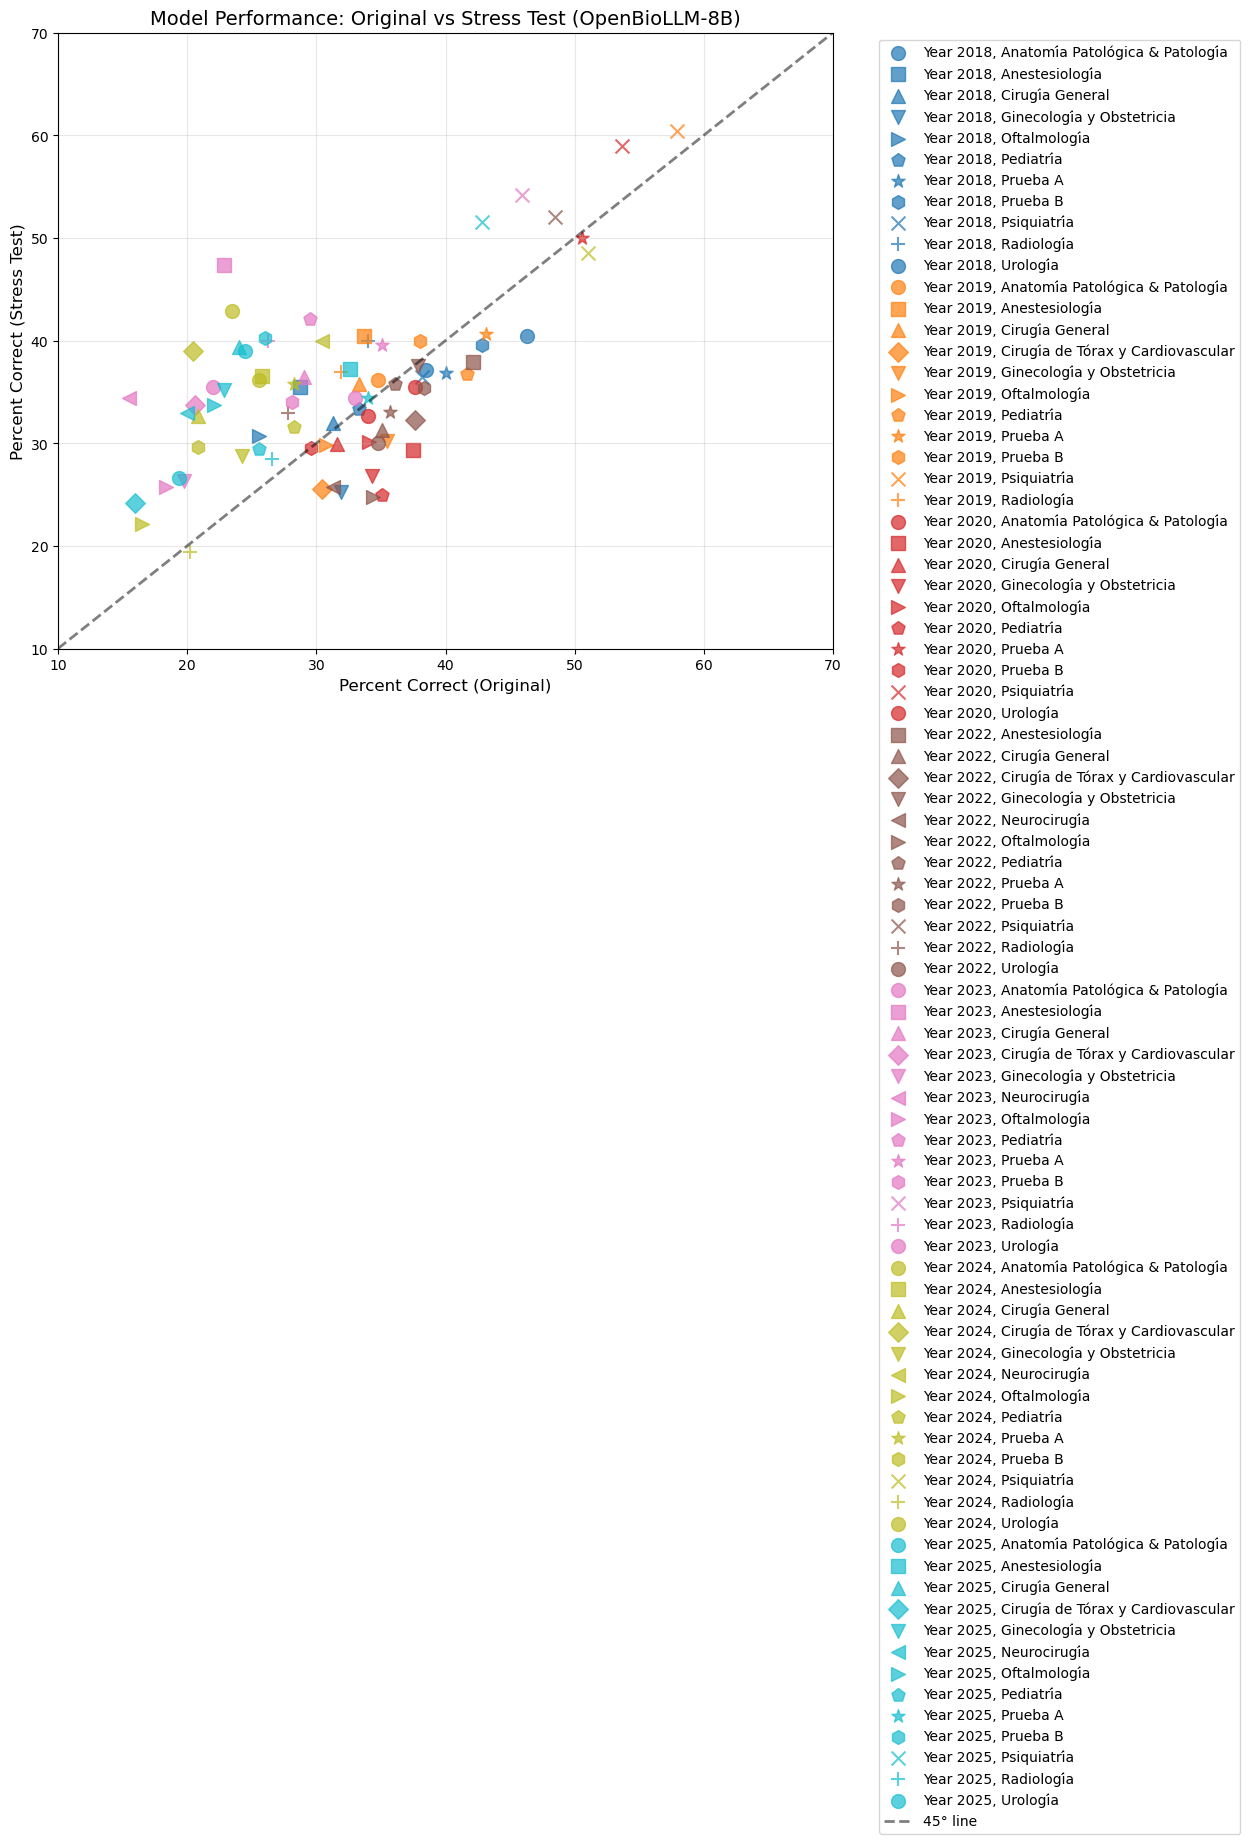

In [56]:
# Define marker styles for source_file
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h', 'x', '+']
marker_cycle = cycle(markers)
marker_map = {source: next(marker_cycle) for source in df_old_new_openbiollm['source_file'].unique()}

# Get unique years and source files
years = sorted(df_old_new_openbiollm['year'].unique())
source_files = sorted(df_old_new_openbiollm['source_file'].unique())

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 8))

# Create a color map for years
colors = plt.cm.tab10(np.linspace(0, 1, len(years)))
color_map = {year: colors[i] for i, year in enumerate(years)}

# Plot points colored by year with markers by source_file
for year in years:
    for source_file in source_files:
        mask = (df_old_new_openbiollm['year'] == year) & (df_old_new_openbiollm['source_file'] == source_file)
        data = df_old_new_openbiollm[mask]
        if len(data) > 0:
            ax.scatter(
                data['percentage_correct_old'],
                data['percentage_correct_new'],
                marker=marker_map[source_file],
                color=color_map[year],
                s=100,
                alpha=0.7,
                label=f"Year {year}, {source_file}"
            )

# Add 45-degree line
ax.plot([10, 70], [10, 70], 'k--', label='45° line', linewidth=2, alpha=0.5)

# Set axis limits and labels
ax.set_xlim(10, 70)
ax.set_ylim(10, 70)
ax.set_xlabel('Percent Correct (Original)', fontsize=12)
ax.set_ylabel('Percent Correct (Stress Test)', fontsize=12)
ax.set_title('Model Performance: Original vs Stress Test (OpenBioLLM-8B)', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

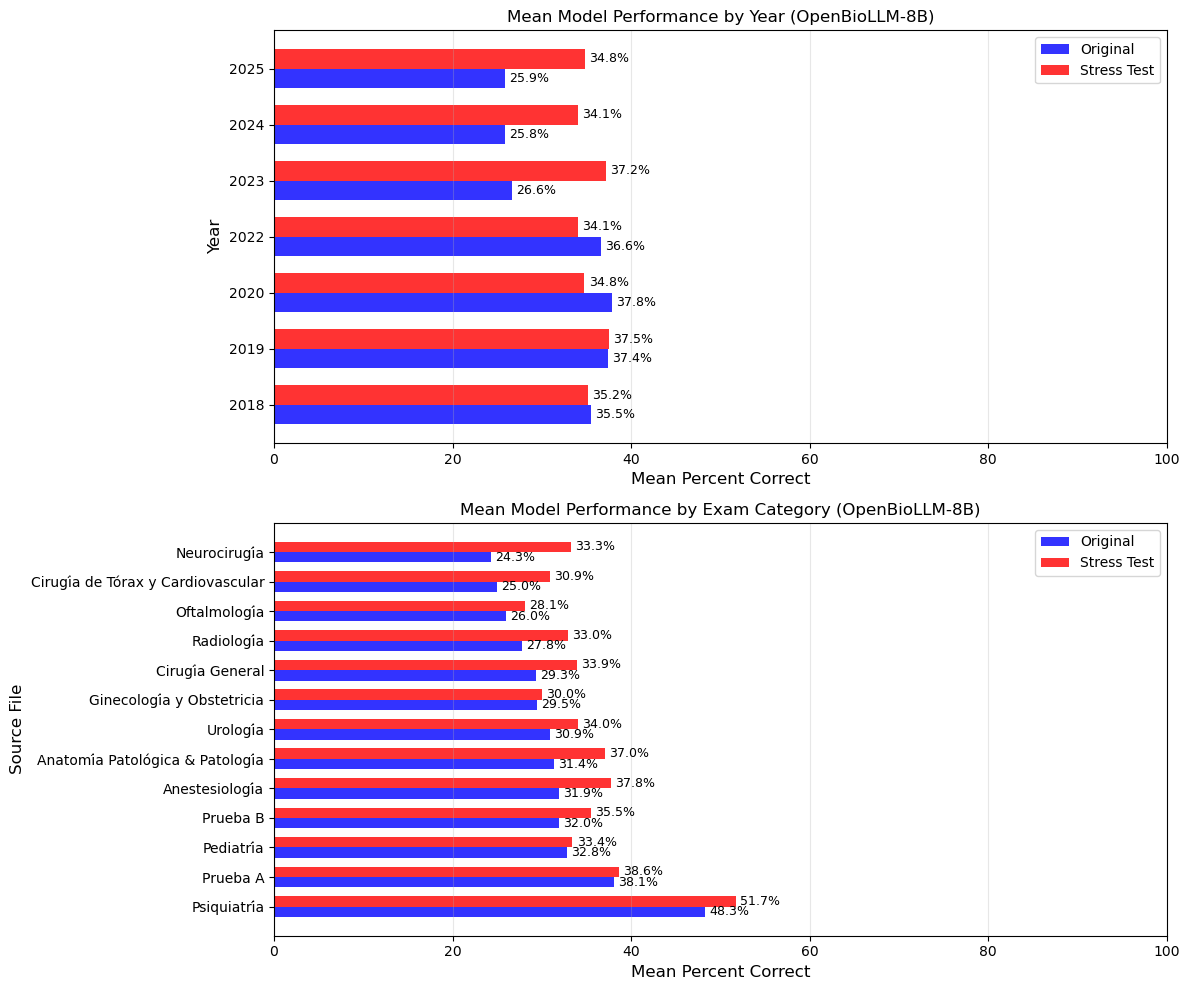

In [57]:
# Bar plot: Mean performance by year
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Group by year and calculate means
year_stats = df_old_new_openbiollm.groupby('year')[['percentage_correct_old', 'percentage_correct_new']].mean()

# Bar plot 1: Mean performance by year
x_pos = np.arange(len(year_stats.index))
width = 0.35

bars_old_year = axes[0].barh(
    x_pos - width/2,
    year_stats['percentage_correct_old'],
    height=width,
    label='Original',
    color='blue',
    alpha=0.8
)
bars_new_year = axes[0].barh(
    x_pos + width/2,
    year_stats['percentage_correct_new'],
    height=width,
    label='Stress Test',
    color='red',
    alpha=0.8
)
axes[0].bar_label(bars_old_year, fmt='%.1f%%', padding=3, fontsize=9)
axes[0].bar_label(bars_new_year, fmt='%.1f%%', padding=3, fontsize=9)
axes[0].set_ylabel('Year', fontsize=12)
axes[0].set_xlabel('Mean Percent Correct', fontsize=12)
axes[0].set_xlim(0, 100)
axes[0].set_title('Mean Model Performance by Year (OpenBioLLM-8B)', fontsize=12)
axes[0].set_yticks(x_pos)
axes[0].set_yticklabels(year_stats.index)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='x')

# Bar plot 2: Mean performance by source_file
source_stats = df_old_new_openbiollm.groupby('source_file')[['percentage_correct_old', 'percentage_correct_new']].mean().sort_values('percentage_correct_old', ascending=False)

x_pos = np.arange(len(source_stats.index))
bars_old_source = axes[1].barh(
    x_pos - width/2,
    source_stats['percentage_correct_old'],
    height=width,
    label='Original',
    color='blue',
    alpha=0.8
)
bars_new_source = axes[1].barh(
    x_pos + width/2,
    source_stats['percentage_correct_new'],
    height=width,
    label='Stress Test',
    color='red',
    alpha=0.8
)
axes[1].bar_label(bars_old_source, fmt='%.1f%%', padding=3, fontsize=9)
axes[1].bar_label(bars_new_source, fmt='%.1f%%', padding=3, fontsize=9)
axes[1].set_ylabel('Source File', fontsize=12)
axes[1].set_xlabel('Mean Percent Correct', fontsize=12)
axes[1].set_xlim(0, 100)
axes[1].set_title('Mean Model Performance by Exam Category (OpenBioLLM-8B)', fontsize=12)
axes[1].set_yticks(x_pos)
axes[1].set_yticklabels(source_stats.index)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

In [44]:
# Prepare data for paired tests
# Remove rows with missing values in either column
data_paired = df_old_new_openbiollm[['percentage_correct_old', 'percentage_correct_new']].dropna()

print("=" * 70)
print("STATISTICAL TESTS: Original vs Stress Test Performance")
print("=" * 70)

# 1. Check normality of differences
differences = data_paired['percentage_correct_new'] - data_paired['percentage_correct_old']
stat_shapiro, p_shapiro = stats.shapiro(differences)
print(f"\n1. NORMALITY TEST (Shapiro-Wilk on differences):")
print(f"   Test Statistic: {stat_shapiro:.4f}")
print(f"   p-value: {p_shapiro:.6f}")
print(f"   Result: {'Data is normally distributed' if p_shapiro > 0.05 else 'Data deviates from normality'} (α=0.05)")

# 2. Paired t-test (parametric)
t_stat, p_ttest = stats.ttest_rel(data_paired['percentage_correct_new'], 
                                   data_paired['percentage_correct_old'])
mean_diff = differences.mean()
std_diff = differences.std()

print(f"\n2. PAIRED T-TEST (parametric):")
print(f"   Mean difference (Stress Test - Original): {mean_diff:.4f}%")
print(f"   Std deviation of differences: {std_diff:.4f}%")
print(f"   t-statistic: {t_stat:.4f}")
print(f"   p-value: {p_ttest:.6f}")
print(f"   Result: {'SIGNIFICANT difference' if p_ttest < 0.05 else 'No significant difference'} (α=0.05)")

# 3. Wilcoxon Signed-Rank Test (non-parametric alternative)
w_stat, p_wilcox = stats.wilcoxon(data_paired['percentage_correct_new'], 
                                    data_paired['percentage_correct_old'])
print(f"\n3. WILCOXON SIGNED-RANK TEST (non-parametric alternative):")
print(f"   W-statistic: {w_stat:.4f}")
print(f"   p-value: {p_wilcox:.6f}")
print(f"   Result: {'SIGNIFICANT difference' if p_wilcox < 0.05 else 'No significant difference'} (α=0.05)")

# 4. Effect size (Cohen's d for paired samples)
cohens_d = mean_diff / std_diff
print(f"\n4. EFFECT SIZE (Cohen's d):")
print(f"   Cohen's d: {cohens_d:.4f}")
if abs(cohens_d) < 0.2:
    effect_interpretation = "negligible"
elif abs(cohens_d) < 0.5:
    effect_interpretation = "small"
elif abs(cohens_d) < 0.8:
    effect_interpretation = "medium"
else:
    effect_interpretation = "large"
print(f"   Interpretation: {effect_interpretation.upper()} effect")

# 5. Descriptive statistics
print(f"\n5. DESCRIPTIVE STATISTICS:")
print(f"   N (paired observations): {len(data_paired)}")
print(f"   Original - Mean: {data_paired['percentage_correct_old'].mean():.2f}%, Std: {data_paired['percentage_correct_old'].std():.2f}%")
print(f"   Stress Test - Mean: {data_paired['percentage_correct_new'].mean():.2f}%, Std: {data_paired['percentage_correct_new'].std():.2f}%")

# Count improvements/declines
improvements = (differences > 0).sum()
declines = (differences < 0).sum()
no_change = (differences == 0).sum()

print(f"\n6. DIRECTION OF CHANGE:")
print(f"   Improved (Stress Test > Original): {improvements} ({100*improvements/len(data_paired):.1f}%)")
print(f"   Declined (Stress Test < Original): {declines} ({100*declines/len(data_paired):.1f}%)")
print(f"   No change: {no_change} ({100*no_change/len(data_paired):.1f}%)")

print("\n" + "=" * 70)
print("RECOMMENDATION:")
print("=" * 70)
if p_shapiro > 0.05:
    print("✓ Data appears normally distributed, paired t-test is appropriate.")
else:
    print("✗ Data deviates from normality. Consider using the Wilcoxon test.")
    print("  Both tests are shown above for comparison.")
print("=" * 70)

STATISTICAL TESTS: Original vs Stress Test Performance

1. NORMALITY TEST (Shapiro-Wilk on differences):
   Test Statistic: 0.9776
   p-value: 0.155874
   Result: Data is normally distributed (α=0.05)

2. PAIRED T-TEST (parametric):
   Mean difference (Stress Test - Original): 3.5876%
   Std deviation of differences: 7.4237%
   t-statistic: 4.4027
   p-value: 0.000032
   Result: SIGNIFICANT difference (α=0.05)

3. WILCOXON SIGNED-RANK TEST (non-parametric alternative):
   W-statistic: 856.0000
   p-value: 0.000152
   Result: SIGNIFICANT difference (α=0.05)

4. EFFECT SIZE (Cohen's d):
   Cohen's d: 0.4833
   Interpretation: SMALL effect

5. DESCRIPTIVE STATISTICS:
   N (paired observations): 83
   Original - Mean: 31.78%, Std: 8.96%
   Stress Test - Mean: 35.36%, Std: 7.72%

6. DIRECTION OF CHANGE:
   Improved (Stress Test > Original): 50 (60.2%)
   Declined (Stress Test < Original): 31 (37.3%)
   No change: 2 (2.4%)

RECOMMENDATION:
✓ Data appears normally distributed, paired t-test i

In [45]:
# Stratified analysis by YEAR
print("\n" + "=" * 90)
print("STRATIFIED ANALYSIS BY YEAR")
print("=" * 90)

results_by_year = []

for year in sorted(df_old_new_openbiollm['year'].unique()):
    year_data = df_old_new_openbiollm[df_old_new_openbiollm['year'] == year][['percentage_correct_old', 'percentage_correct_new']].dropna()
    
    if len(year_data) < 2:
        continue
    
    year_diff = year_data['percentage_correct_new'] - year_data['percentage_correct_old']
    t_stat_y, p_ttest_y = stats.ttest_rel(year_data['percentage_correct_new'], year_data['percentage_correct_old'])
    w_stat_y, p_wilcox_y = stats.wilcoxon(year_data['percentage_correct_new'], year_data['percentage_correct_old'])
    cohens_d_y = year_diff.mean() / year_diff.std() if year_diff.std() > 0 else 0
    
    results_by_year.append({
        'Year': year,
        'N': len(year_data),
        'Mean_Diff': year_diff.mean(),
        'Std_Diff': year_diff.std(),
        'T_stat': t_stat_y,
        'P_ttest': p_ttest_y,
        'P_wilcox': p_wilcox_y,
        'Cohens_d': cohens_d_y,
        'Original_Mean': year_data['percentage_correct_old'].mean(),
        'Stress_Mean': year_data['percentage_correct_new'].mean()
    })

results_by_year_df = pd.DataFrame(results_by_year)

print("\nYear-by-Year Summary:")
print("-" * 90)
for idx, row in results_by_year_df.iterrows():
    sig_ttest = "***" if row['P_ttest'] < 0.05 else ""
    sig_wilcox = "***" if row['P_wilcox'] < 0.05 else ""
    print(f"Year {int(row['Year'])} (N={int(row['N'])}):")
    print(f"  Original: {row['Original_Mean']:.2f}% → Stress: {row['Stress_Mean']:.2f}% (Δ = {row['Mean_Diff']:+.2f}%)")
    print(f"  T-test p-value: {row['P_ttest']:.4f} {sig_ttest}  |  Wilcoxon p-value: {row['P_wilcox']:.4f} {sig_wilcox}")
    print(f"  Cohen's d: {row['Cohens_d']:.4f}")
    print()

# Stratified analysis by SOURCE FILE
print("=" * 90)
print("STRATIFIED ANALYSIS BY SOURCE FILE (EXAM CATEGORY)")
print("=" * 90)

results_by_source = []

for source_file in sorted(df_old_new_openbiollm['source_file'].unique()):
    source_data = df_old_new_openbiollm[df_old_new_openbiollm['source_file'] == source_file][['percentage_correct_old', 'percentage_correct_new']].dropna()
    
    if len(source_data) < 2:
        continue
    
    source_diff = source_data['percentage_correct_new'] - source_data['percentage_correct_old']
    t_stat_s, p_ttest_s = stats.ttest_rel(source_data['percentage_correct_new'], source_data['percentage_correct_old'])
    w_stat_s, p_wilcox_s = stats.wilcoxon(source_data['percentage_correct_new'], source_data['percentage_correct_old'])
    cohens_d_s = source_diff.mean() / source_diff.std() if source_diff.std() > 0 else 0
    
    results_by_source.append({
        'Source_File': source_file,
        'N': len(source_data),
        'Mean_Diff': source_diff.mean(),
        'Std_Diff': source_diff.std(),
        'T_stat': t_stat_s,
        'P_ttest': p_ttest_s,
        'P_wilcox': p_wilcox_s,
        'Cohens_d': cohens_d_s,
        'Original_Mean': source_data['percentage_correct_old'].mean(),
        'Stress_Mean': source_data['percentage_correct_new'].mean()
    })

results_by_source_df = pd.DataFrame(results_by_source).sort_values('Original_Mean', ascending=False)

print("\nSource File-by-Source File Summary:")
print("-" * 90)
for idx, row in results_by_source_df.iterrows():
    sig_ttest = "***" if row['P_ttest'] < 0.05 else ""
    sig_wilcox = "***" if row['P_wilcox'] < 0.05 else ""
    print(f"{row['Source_File']} (N={int(row['N'])}):")
    print(f"  Original: {row['Original_Mean']:.2f}% → Stress: {row['Stress_Mean']:.2f}% (Δ = {row['Mean_Diff']:+.2f}%)")
    print(f"  T-test p-value: {row['P_ttest']:.4f} {sig_ttest}  |  Wilcoxon p-value: {row['P_wilcox']:.4f} {sig_wilcox}")
    print(f"  Cohen's d: {row['Cohens_d']:.4f}")
    print()

print("=" * 90)
print("LEGEND: *** indicates p < 0.05 (statistically significant)")
print("=" * 90)


STRATIFIED ANALYSIS BY YEAR

Year-by-Year Summary:
------------------------------------------------------------------------------------------
Year 2018 (N=11):
  Original: 35.50% → Stress: 35.19% (Δ = -0.31%)
  T-test p-value: 0.8279   |  Wilcoxon p-value: 0.8457 
  Cohen's d: -0.0673

Year 2019 (N=11):
  Original: 37.37% → Stress: 37.52% (Δ = +0.14%)
  T-test p-value: 0.9127   |  Wilcoxon p-value: 0.8984 
  Cohen's d: 0.0339

Year 2020 (N=10):
  Original: 37.81% → Stress: 34.78% (Δ = -3.03%)
  T-test p-value: 0.0649   |  Wilcoxon p-value: 0.0547 
  Cohen's d: -0.6646

Year 2022 (N=12):
  Original: 36.63% → Stress: 34.06% (Δ = -2.57%)
  T-test p-value: 0.0517   |  Wilcoxon p-value: 0.0522 
  Cohen's d: -0.6299

Year 2023 (N=13):
  Original: 26.61% → Stress: 37.21% (Δ = +10.60%)
  T-test p-value: 0.0001 ***  |  Wilcoxon p-value: 0.0002 ***
  Cohen's d: 1.6787

Year 2024 (N=13):
  Original: 25.83% → Stress: 34.06% (Δ = +8.23%)
  T-test p-value: 0.0006 ***  |  Wilcoxon p-value: 0.0012 **

# 09.OpenBioLLM-70B

In [5]:
df_old_openbiollm70 = pd.read_pickle(f'/Users/rodrigocarrillo/Documents/Natural Language Processing Projects/Examen Residentado Peru/02.LLMs Results/07.OpenBioLLM-70B/{file_name}')
df_old_openbiollm70 = df_old_openbiollm70.rename(columns={"count_of_matches": "count_of_matches_old", "total_rows": "total_rows_old", "percent_correct": "percentage_correct_old"})
df_old_openbiollm70.head()

,source_file,year,count_of_matches_old,total_rows_old,percentage_correct_old,model_name
0,Anatomía Patológica & Patología,2018,74,100,74.0,OpenBioLLM-70B
1,Anatomía Patológica & Patología,2019,64,100,64.0,OpenBioLLM-70B
2,Anatomía Patológica & Patología,2020,70,100,70.0,OpenBioLLM-70B
3,Anatomía Patológica & Patología,2023,77,100,77.0,OpenBioLLM-70B
4,Anatomía Patológica & Patología,2024,77,100,77.0,OpenBioLLM-70B


In [6]:
df_new_openbiollm70 = pd.read_pickle(f'/Users/rodrigocarrillo/Documents/Natural Language Processing Projects/Examen Residentado Peru/02.LLMs Results/Reorder Options/09.OpenBioLLM-70B/{file_name}')
df_new_openbiollm70 = df_new_openbiollm70.rename(columns={"count_of_matches": "count_of_matches_new", "total_rows": "total_rows_new", "percent_correct": "percentage_correct_new"})
df_new_openbiollm70.head()

,source_file,year,count_of_matches_new,total_rows_new,percentage_correct_new,model_name
0,Anatomía Patológica & Patología,2018,73,100,73.0,OpenBioLLM-70B
1,Anatomía Patológica & Patología,2019,65,100,65.0,OpenBioLLM-70B
2,Anatomía Patológica & Patología,2020,74,100,74.0,OpenBioLLM-70B
3,Anatomía Patológica & Patología,2023,73,100,73.0,OpenBioLLM-70B
4,Anatomía Patológica & Patología,2024,74,100,74.0,OpenBioLLM-70B


In [7]:
df_old_new_openbiollm70 = pd.merge(df_old_openbiollm70, df_new_openbiollm70, on=["source_file", "year", "model_name"], how="outer")
df_old_new_openbiollm70

,source_file,year,count_of_matches_old,total_rows_old,percentage_correct_old,model_name,count_of_matches_new,total_rows_new,percentage_correct_new
0,Anatomía Patológica & Patología,2018,74,100,74.0,OpenBioLLM-70B,73,100,73.0
1,Anatomía Patológica & Patología,2019,64,100,64.0,OpenBioLLM-70B,65,100,65.0
2,Anatomía Patológica & Patología,2020,70,100,70.0,OpenBioLLM-70B,74,100,74.0
3,Anatomía Patológica & Patología,2023,77,100,77.0,OpenBioLLM-70B,73,100,73.0
4,Anatomía Patológica & Patología,2024,77,100,77.0,OpenBioLLM-70B,74,100,74.0
...,...,...,...,...,...,...,...,...,...
78,Urología,2020,63,100,63.0,OpenBioLLM-70B,64,100,64.0
79,Urología,2022,68,100,68.0,OpenBioLLM-70B,67,100,67.0
80,Urología,2023,75,100,75.0,OpenBioLLM-70B,71,100,71.0
81,Urología,2024,67,100,67.0,OpenBioLLM-70B,65,100,65.0


/var/folders/0p/pq1qfwzj0bz0b4wsym558qgw0000gn/T/ipykernel_66074/998994452.py:45: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


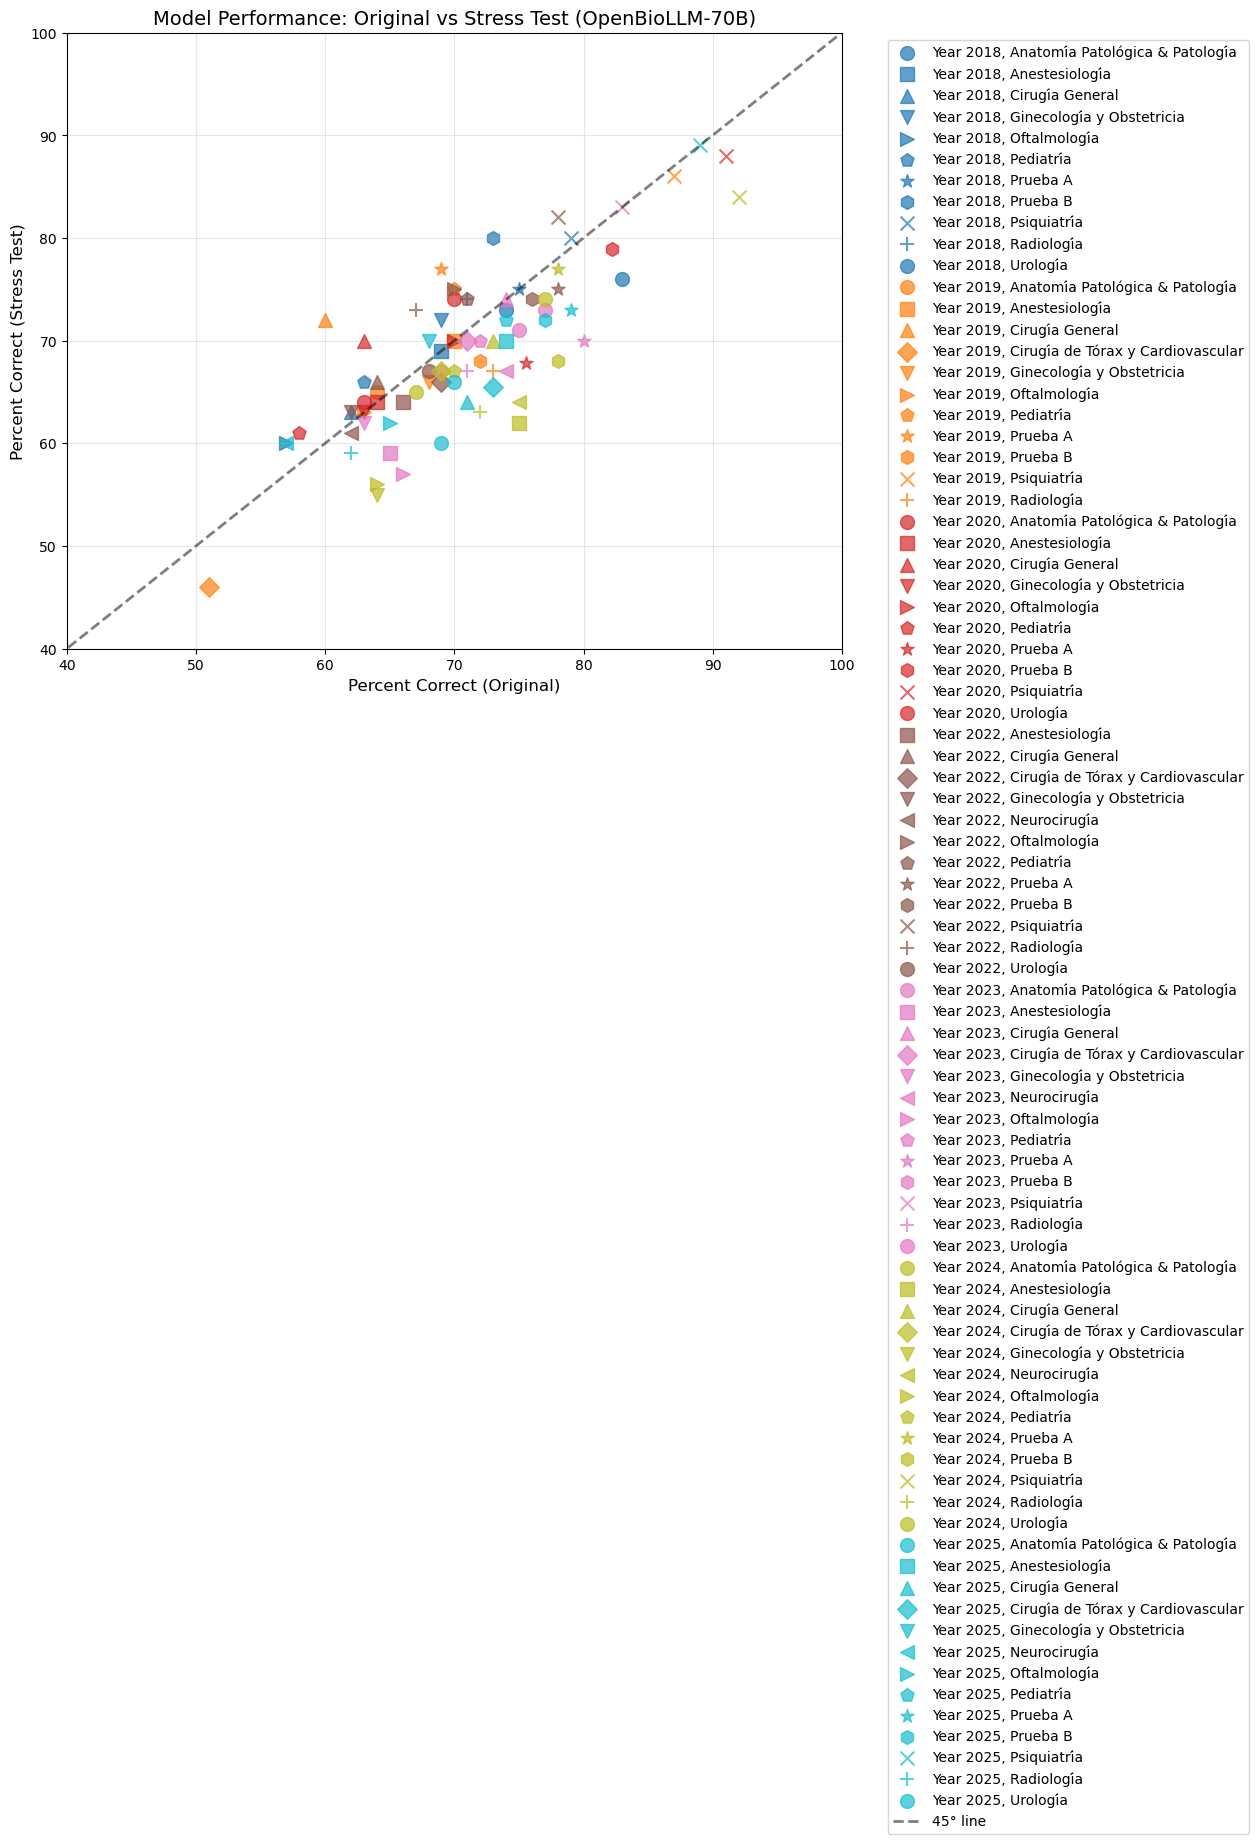

In [10]:
# Define marker styles for source_file
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h', 'x', '+']
marker_cycle = cycle(markers)
marker_map = {source: next(marker_cycle) for source in df_old_new_openbiollm70['source_file'].unique()}

# Get unique years and source files
years = sorted(df_old_new_openbiollm70['year'].unique())
source_files = sorted(df_old_new_openbiollm70['source_file'].unique())

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 8))

# Create a color map for years
colors = plt.cm.tab10(np.linspace(0, 1, len(years)))
color_map = {year: colors[i] for i, year in enumerate(years)}

# Plot points colored by year with markers by source_file
for year in years:
    for source_file in source_files:
        mask = (df_old_new_openbiollm70['year'] == year) & (df_old_new_openbiollm70['source_file'] == source_file)
        data = df_old_new_openbiollm70[mask]
        if len(data) > 0:
            ax.scatter(
                data['percentage_correct_old'],
                data['percentage_correct_new'],
                marker=marker_map[source_file],
                color=color_map[year],
                s=100,
                alpha=0.7,
                label=f"Year {year}, {source_file}"
            )

# Add 45-degree line
ax.plot([20, 100], [20, 100], 'k--', label='45° line', linewidth=2, alpha=0.5)

# Set axis limits and labels
ax.set_xlim(40, 100)
ax.set_ylim(40, 100)
ax.set_xlabel('Percent Correct (Original)', fontsize=12)
ax.set_ylabel('Percent Correct (Stress Test)', fontsize=12)
ax.set_title('Model Performance: Original vs Stress Test (OpenBioLLM-70B)', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

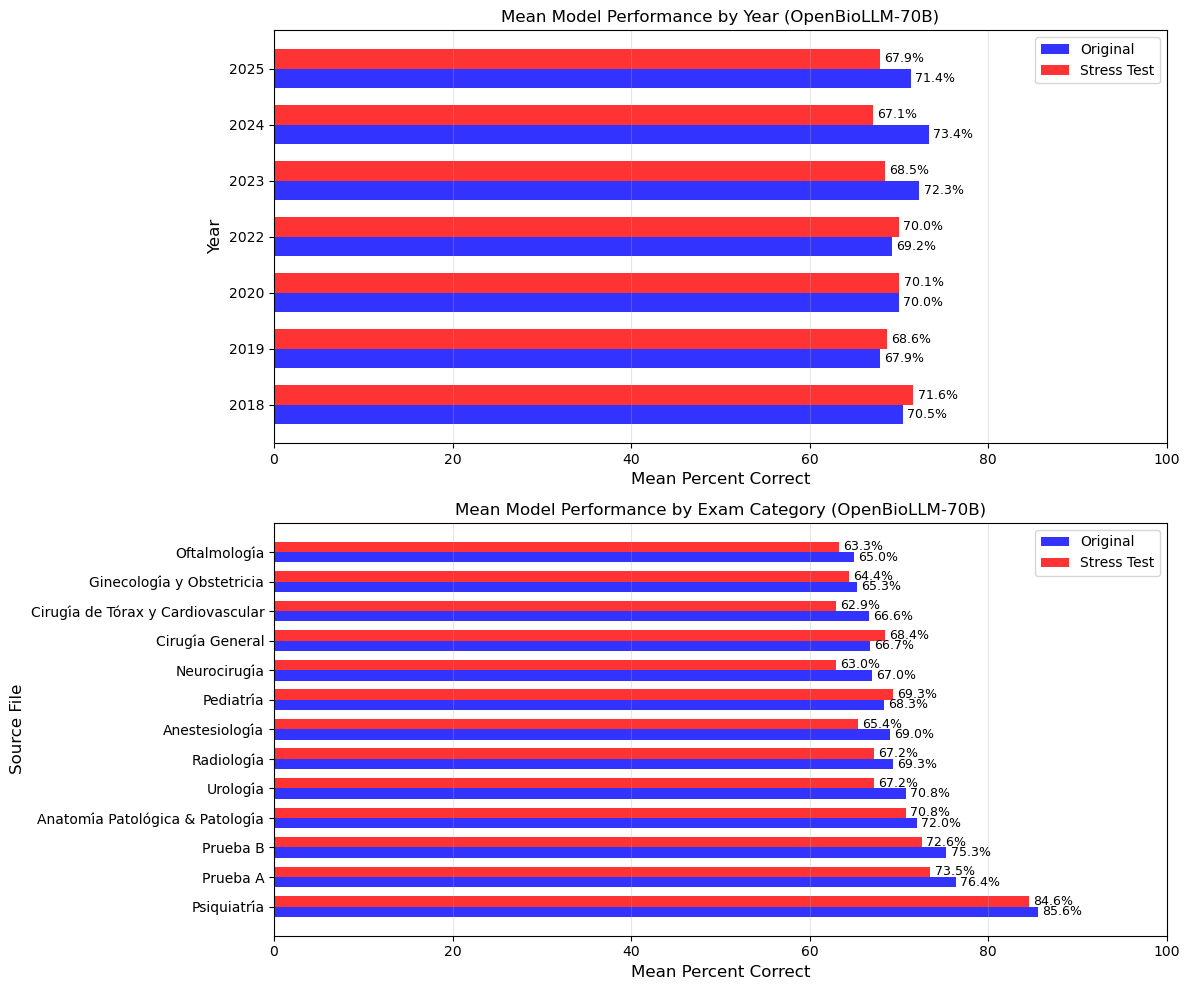

In [11]:
# Bar plot: Mean performance by year
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Group by year and calculate means
year_stats = df_old_new_openbiollm70.groupby('year')[['percentage_correct_old', 'percentage_correct_new']].mean()

# Bar plot 1: Mean performance by year
x_pos = np.arange(len(year_stats.index))
width = 0.35

bars_old_year = axes[0].barh(
    x_pos - width/2,
    year_stats['percentage_correct_old'],
    height=width,
    label='Original',
    color='blue',
    alpha=0.8
)
bars_new_year = axes[0].barh(
    x_pos + width/2,
    year_stats['percentage_correct_new'],
    height=width,
    label='Stress Test',
    color='red',
    alpha=0.8
)
axes[0].bar_label(bars_old_year, fmt='%.1f%%', padding=3, fontsize=9)
axes[0].bar_label(bars_new_year, fmt='%.1f%%', padding=3, fontsize=9)
axes[0].set_ylabel('Year', fontsize=12)
axes[0].set_xlabel('Mean Percent Correct', fontsize=12)
axes[0].set_xlim(0, 100)
axes[0].set_title('Mean Model Performance by Year (OpenBioLLM-70B)', fontsize=12)
axes[0].set_yticks(x_pos)
axes[0].set_yticklabels(year_stats.index)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='x')

# Bar plot 2: Mean performance by source_file
source_stats = df_old_new_openbiollm70.groupby('source_file')[['percentage_correct_old', 'percentage_correct_new']].mean().sort_values('percentage_correct_old', ascending=False)

x_pos = np.arange(len(source_stats.index))
bars_old_source = axes[1].barh(
    x_pos - width/2,
    source_stats['percentage_correct_old'],
    height=width,
    label='Original',
    color='blue',
    alpha=0.8
)
bars_new_source = axes[1].barh(
    x_pos + width/2,
    source_stats['percentage_correct_new'],
    height=width,
    label='Stress Test',
    color='red',
    alpha=0.8
)
axes[1].bar_label(bars_old_source, fmt='%.1f%%', padding=3, fontsize=9)
axes[1].bar_label(bars_new_source, fmt='%.1f%%', padding=3, fontsize=9)
axes[1].set_ylabel('Source File', fontsize=12)
axes[1].set_xlabel('Mean Percent Correct', fontsize=12)
axes[1].set_xlim(0, 100)
axes[1].set_title('Mean Model Performance by Exam Category (OpenBioLLM-70B)', fontsize=12)
axes[1].set_yticks(x_pos)
axes[1].set_yticklabels(source_stats.index)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

In [12]:
# Prepare data for paired tests
# Remove rows with missing values in either column
data_paired = df_old_new_openbiollm70[['percentage_correct_old', 'percentage_correct_new']].dropna()

print("=" * 70)
print("STATISTICAL TESTS: Original vs Stress Test Performance")
print("=" * 70)

# 1. Check normality of differences
differences = data_paired['percentage_correct_new'] - data_paired['percentage_correct_old']
stat_shapiro, p_shapiro = stats.shapiro(differences)
print(f"\n1. NORMALITY TEST (Shapiro-Wilk on differences):")
print(f"   Test Statistic: {stat_shapiro:.4f}")
print(f"   p-value: {p_shapiro:.6f}")
print(f"   Result: {'Data is normally distributed' if p_shapiro > 0.05 else 'Data deviates from normality'} (α=0.05)")

# 2. Paired t-test (parametric)
t_stat, p_ttest = stats.ttest_rel(data_paired['percentage_correct_new'], 
                                   data_paired['percentage_correct_old'])
mean_diff = differences.mean()
std_diff = differences.std()

print(f"\n2. PAIRED T-TEST (parametric):")
print(f"   Mean difference (Stress Test - Original): {mean_diff:.4f}%")
print(f"   Std deviation of differences: {std_diff:.4f}%")
print(f"   t-statistic: {t_stat:.4f}")
print(f"   p-value: {p_ttest:.6f}")
print(f"   Result: {'SIGNIFICANT difference' if p_ttest < 0.05 else 'No significant difference'} (α=0.05)")

# 3. Wilcoxon Signed-Rank Test (non-parametric alternative)
w_stat, p_wilcox = stats.wilcoxon(data_paired['percentage_correct_new'], 
                                    data_paired['percentage_correct_old'])
print(f"\n3. WILCOXON SIGNED-RANK TEST (non-parametric alternative):")
print(f"   W-statistic: {w_stat:.4f}")
print(f"   p-value: {p_wilcox:.6f}")
print(f"   Result: {'SIGNIFICANT difference' if p_wilcox < 0.05 else 'No significant difference'} (α=0.05)")

# 4. Effect size (Cohen's d for paired samples)
cohens_d = mean_diff / std_diff
print(f"\n4. EFFECT SIZE (Cohen's d):")
print(f"   Cohen's d: {cohens_d:.4f}")
if abs(cohens_d) < 0.2:
    effect_interpretation = "negligible"
elif abs(cohens_d) < 0.5:
    effect_interpretation = "small"
elif abs(cohens_d) < 0.8:
    effect_interpretation = "medium"
else:
    effect_interpretation = "large"
print(f"   Interpretation: {effect_interpretation.upper()} effect")

# 5. Descriptive statistics
print(f"\n5. DESCRIPTIVE STATISTICS:")
print(f"   N (paired observations): {len(data_paired)}")
print(f"   Original - Mean: {data_paired['percentage_correct_old'].mean():.2f}%, Std: {data_paired['percentage_correct_old'].std():.2f}%")
print(f"   Stress Test - Mean: {data_paired['percentage_correct_new'].mean():.2f}%, Std: {data_paired['percentage_correct_new'].std():.2f}%")

# Count improvements/declines
improvements = (differences > 0).sum()
declines = (differences < 0).sum()
no_change = (differences == 0).sum()

print(f"\n6. DIRECTION OF CHANGE:")
print(f"   Improved (Stress Test > Original): {improvements} ({100*improvements/len(data_paired):.1f}%)")
print(f"   Declined (Stress Test < Original): {declines} ({100*declines/len(data_paired):.1f}%)")
print(f"   No change: {no_change} ({100*no_change/len(data_paired):.1f}%)")

print("\n" + "=" * 70)
print("RECOMMENDATION:")
print("=" * 70)
if p_shapiro > 0.05:
    print("✓ Data appears normally distributed, paired t-test is appropriate.")
else:
    print("✗ Data deviates from normality. Consider using the Wilcoxon test.")
    print("  Both tests are shown above for comparison.")
print("=" * 70)

STATISTICAL TESTS: Original vs Stress Test Performance

1. NORMALITY TEST (Shapiro-Wilk on differences):
   Test Statistic: 0.9887
   p-value: 0.690894
   Result: Data is normally distributed (α=0.05)

2. PAIRED T-TEST (parametric):
   Mean difference (Stress Test - Original): -1.7664%
   Std deviation of differences: 4.7149%
   t-statistic: -3.4131
   p-value: 0.001000
   Result: SIGNIFICANT difference (α=0.05)

3. WILCOXON SIGNED-RANK TEST (non-parametric alternative):
   W-statistic: 761.0000
   p-value: 0.001163
   Result: SIGNIFICANT difference (α=0.05)

4. EFFECT SIZE (Cohen's d):
   Cohen's d: -0.3746
   Interpretation: SMALL effect

5. DESCRIPTIVE STATISTICS:
   N (paired observations): 83
   Original - Mean: 70.78%, Std: 7.63%
   Stress Test - Mean: 69.01%, Std: 7.61%

6. DIRECTION OF CHANGE:
   Improved (Stress Test > Original): 23 (27.7%)
   Declined (Stress Test < Original): 50 (60.2%)
   No change: 10 (12.0%)

RECOMMENDATION:
✓ Data appears normally distributed, paired t-t

In [13]:
# Stratified analysis by YEAR
print("\n" + "=" * 90)
print("STRATIFIED ANALYSIS BY YEAR")
print("=" * 90)

results_by_year = []

for year in sorted(df_old_new_openbiollm70['year'].unique()):
    year_data = df_old_new_openbiollm70[df_old_new_openbiollm70['year'] == year][['percentage_correct_old', 'percentage_correct_new']].dropna()
    
    if len(year_data) < 2:
        continue
    
    year_diff = year_data['percentage_correct_new'] - year_data['percentage_correct_old']
    t_stat_y, p_ttest_y = stats.ttest_rel(year_data['percentage_correct_new'], year_data['percentage_correct_old'])
    w_stat_y, p_wilcox_y = stats.wilcoxon(year_data['percentage_correct_new'], year_data['percentage_correct_old'])
    cohens_d_y = year_diff.mean() / year_diff.std() if year_diff.std() > 0 else 0
    
    results_by_year.append({
        'Year': year,
        'N': len(year_data),
        'Mean_Diff': year_diff.mean(),
        'Std_Diff': year_diff.std(),
        'T_stat': t_stat_y,
        'P_ttest': p_ttest_y,
        'P_wilcox': p_wilcox_y,
        'Cohens_d': cohens_d_y,
        'Original_Mean': year_data['percentage_correct_old'].mean(),
        'Stress_Mean': year_data['percentage_correct_new'].mean()
    })

results_by_year_df = pd.DataFrame(results_by_year)

print("\nYear-by-Year Summary:")
print("-" * 90)
for idx, row in results_by_year_df.iterrows():
    sig_ttest = "***" if row['P_ttest'] < 0.05 else ""
    sig_wilcox = "***" if row['P_wilcox'] < 0.05 else ""
    print(f"Year {int(row['Year'])} (N={int(row['N'])}):")
    print(f"  Original: {row['Original_Mean']:.2f}% → Stress: {row['Stress_Mean']:.2f}% (Δ = {row['Mean_Diff']:+.2f}%)")
    print(f"  T-test p-value: {row['P_ttest']:.4f} {sig_ttest}  |  Wilcoxon p-value: {row['P_wilcox']:.4f} {sig_wilcox}")
    print(f"  Cohen's d: {row['Cohens_d']:.4f}")
    print()

# Stratified analysis by SOURCE FILE
print("=" * 90)
print("STRATIFIED ANALYSIS BY SOURCE FILE (EXAM CATEGORY)")
print("=" * 90)

results_by_source = []

for source_file in sorted(df_old_new_openbiollm70['source_file'].unique()):
    source_data = df_old_new_openbiollm70[df_old_new_openbiollm70['source_file'] == source_file][['percentage_correct_old', 'percentage_correct_new']].dropna()
    
    if len(source_data) < 2:
        continue
    
    source_diff = source_data['percentage_correct_new'] - source_data['percentage_correct_old']
    t_stat_s, p_ttest_s = stats.ttest_rel(source_data['percentage_correct_new'], source_data['percentage_correct_old'])
    w_stat_s, p_wilcox_s = stats.wilcoxon(source_data['percentage_correct_new'], source_data['percentage_correct_old'])
    cohens_d_s = source_diff.mean() / source_diff.std() if source_diff.std() > 0 else 0
    
    results_by_source.append({
        'Source_File': source_file,
        'N': len(source_data),
        'Mean_Diff': source_diff.mean(),
        'Std_Diff': source_diff.std(),
        'T_stat': t_stat_s,
        'P_ttest': p_ttest_s,
        'P_wilcox': p_wilcox_s,
        'Cohens_d': cohens_d_s,
        'Original_Mean': source_data['percentage_correct_old'].mean(),
        'Stress_Mean': source_data['percentage_correct_new'].mean()
    })

results_by_source_df = pd.DataFrame(results_by_source).sort_values('Original_Mean', ascending=False)

print("\nSource File-by-Source File Summary:")
print("-" * 90)
for idx, row in results_by_source_df.iterrows():
    sig_ttest = "***" if row['P_ttest'] < 0.05 else ""
    sig_wilcox = "***" if row['P_wilcox'] < 0.05 else ""
    print(f"{row['Source_File']} (N={int(row['N'])}):")
    print(f"  Original: {row['Original_Mean']:.2f}% → Stress: {row['Stress_Mean']:.2f}% (Δ = {row['Mean_Diff']:+.2f}%)")
    print(f"  T-test p-value: {row['P_ttest']:.4f} {sig_ttest}  |  Wilcoxon p-value: {row['P_wilcox']:.4f} {sig_wilcox}")
    print(f"  Cohen's d: {row['Cohens_d']:.4f}")
    print()

print("=" * 90)
print("LEGEND: *** indicates p < 0.05 (statistically significant)")
print("=" * 90)


STRATIFIED ANALYSIS BY YEAR

Year-by-Year Summary:
------------------------------------------------------------------------------------------
Year 2018 (N=11):
  Original: 70.45% → Stress: 71.64% (Δ = +1.18%)
  T-test p-value: 0.2873   |  Wilcoxon p-value: 0.1719 
  Cohen's d: 0.3389

Year 2019 (N=11):
  Original: 67.91% → Stress: 68.64% (Δ = +0.73%)
  T-test p-value: 0.6741   |  Wilcoxon p-value: 0.8828 
  Cohen's d: 0.1306

Year 2020 (N=10):
  Original: 69.98% → Stress: 70.07% (Δ = +0.09%)
  T-test p-value: 0.9475   |  Wilcoxon p-value: 0.9844 
  Cohen's d: 0.0214

Year 2022 (N=12):
  Original: 69.25% → Stress: 70.00% (Δ = +0.75%)
  T-test p-value: 0.4333   |  Wilcoxon p-value: 0.5200 
  Cohen's d: 0.2348

Year 2023 (N=13):
  Original: 72.31% → Stress: 68.46% (Δ = -3.85%)
  T-test p-value: 0.0013 ***  |  Wilcoxon p-value: 0.0010 ***
  Cohen's d: -1.1610

Year 2024 (N=13):
  Original: 73.38% → Stress: 67.08% (Δ = -6.31%)
  T-test p-value: 0.0001 ***  |  Wilcoxon p-value: 0.0002 ***
 

# JSL-MedLlama 3 8B v2.0

In [3]:
df_old_JSL_MedLlama = pd.read_pickle(f'/Users/rodrigocarrillo/Documents/Natural Language Processing Projects/Examen Residentado Peru/02.LLMs Results/05.JSL-MedLlama 3 8B v2.0/{file_name}')
df_old_JSL_MedLlama = df_old_JSL_MedLlama.rename(columns={"count_of_matches": "count_of_matches_old", "total_rows": "total_rows_old", "percent_correct": "percentage_correct_old"})
df_old_JSL_MedLlama.head()

,source_file,year,count_of_matches_old,total_rows_old,percentage_correct_old,model_name
0,Anatomía Patológica & Patología,2018,46,92,50.00,JSL-MedLlama 3 8B v2.0
1,Anatomía Patológica & Patología,2019,36,82,43.90,JSL-MedLlama 3 8B v2.0
2,Anatomía Patológica & Patología,2020,43,93,46.24,JSL-MedLlama 3 8B v2.0
3,Anatomía Patológica & Patología,2023,51,90,56.67,JSL-MedLlama 3 8B v2.0
4,Anatomía Patológica & Patología,2024,54,92,58.70,JSL-MedLlama 3 8B v2.0


In [4]:
df_new_JSL_MedLlama = pd.read_pickle(f'/Users/rodrigocarrillo/Documents/Natural Language Processing Projects/Examen Residentado Peru/02.LLMs Results/Reorder Options/07.JSL-MedLlama 3 8B v2.0/{file_name}')
df_new_JSL_MedLlama = df_new_JSL_MedLlama.rename(columns={"count_of_matches": "count_of_matches_new", "total_rows": "total_rows_new", "percent_correct": "percentage_correct_new"})
df_new_JSL_MedLlama.head()

,source_file,year,count_of_matches_new,total_rows_new,percentage_correct_new,model_name
0,Anatomía Patológica & Patología,2018,43,91,47.25,JSL-MedLlama 3 8B v2.0
1,Anatomía Patológica & Patología,2019,40,87,45.98,JSL-MedLlama 3 8B v2.0
2,Anatomía Patológica & Patología,2020,46,90,51.11,JSL-MedLlama 3 8B v2.0
3,Anatomía Patológica & Patología,2023,56,89,62.92,JSL-MedLlama 3 8B v2.0
4,Anatomía Patológica & Patología,2024,44,92,47.83,JSL-MedLlama 3 8B v2.0


In [5]:
df_old_new_JSL_MedLlama = pd.merge(df_old_JSL_MedLlama, df_new_JSL_MedLlama, on=["source_file", "year", "model_name"], how="outer")
df_old_new_JSL_MedLlama

,source_file,year,count_of_matches_old,total_rows_old,percentage_correct_old,model_name,count_of_matches_new,total_rows_new,percentage_correct_new
0,Anatomía Patológica & Patología,2018,46,92,50.00,JSL-MedLlama 3 8B v2.0,43,91,47.25
1,Anatomía Patológica & Patología,2019,36,82,43.90,JSL-MedLlama 3 8B v2.0,40,87,45.98
2,Anatomía Patológica & Patología,2020,43,93,46.24,JSL-MedLlama 3 8B v2.0,46,90,51.11
3,Anatomía Patológica & Patología,2023,51,90,56.67,JSL-MedLlama 3 8B v2.0,56,89,62.92
4,Anatomía Patológica & Patología,2024,54,92,58.70,JSL-MedLlama 3 8B v2.0,44,92,47.83
...,...,...,...,...,...,...,...,...,...
78,Urología,2020,34,92,36.96,JSL-MedLlama 3 8B v2.0,46,92,50.00
79,Urología,2022,30,92,32.61,JSL-MedLlama 3 8B v2.0,42,93,45.16
80,Urología,2023,52,94,55.32,JSL-MedLlama 3 8B v2.0,46,92,50.00
81,Urología,2024,43,92,46.74,JSL-MedLlama 3 8B v2.0,39,91,42.86


/var/folders/0p/pq1qfwzj0bz0b4wsym558qgw0000gn/T/ipykernel_68114/3251452862.py:45: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


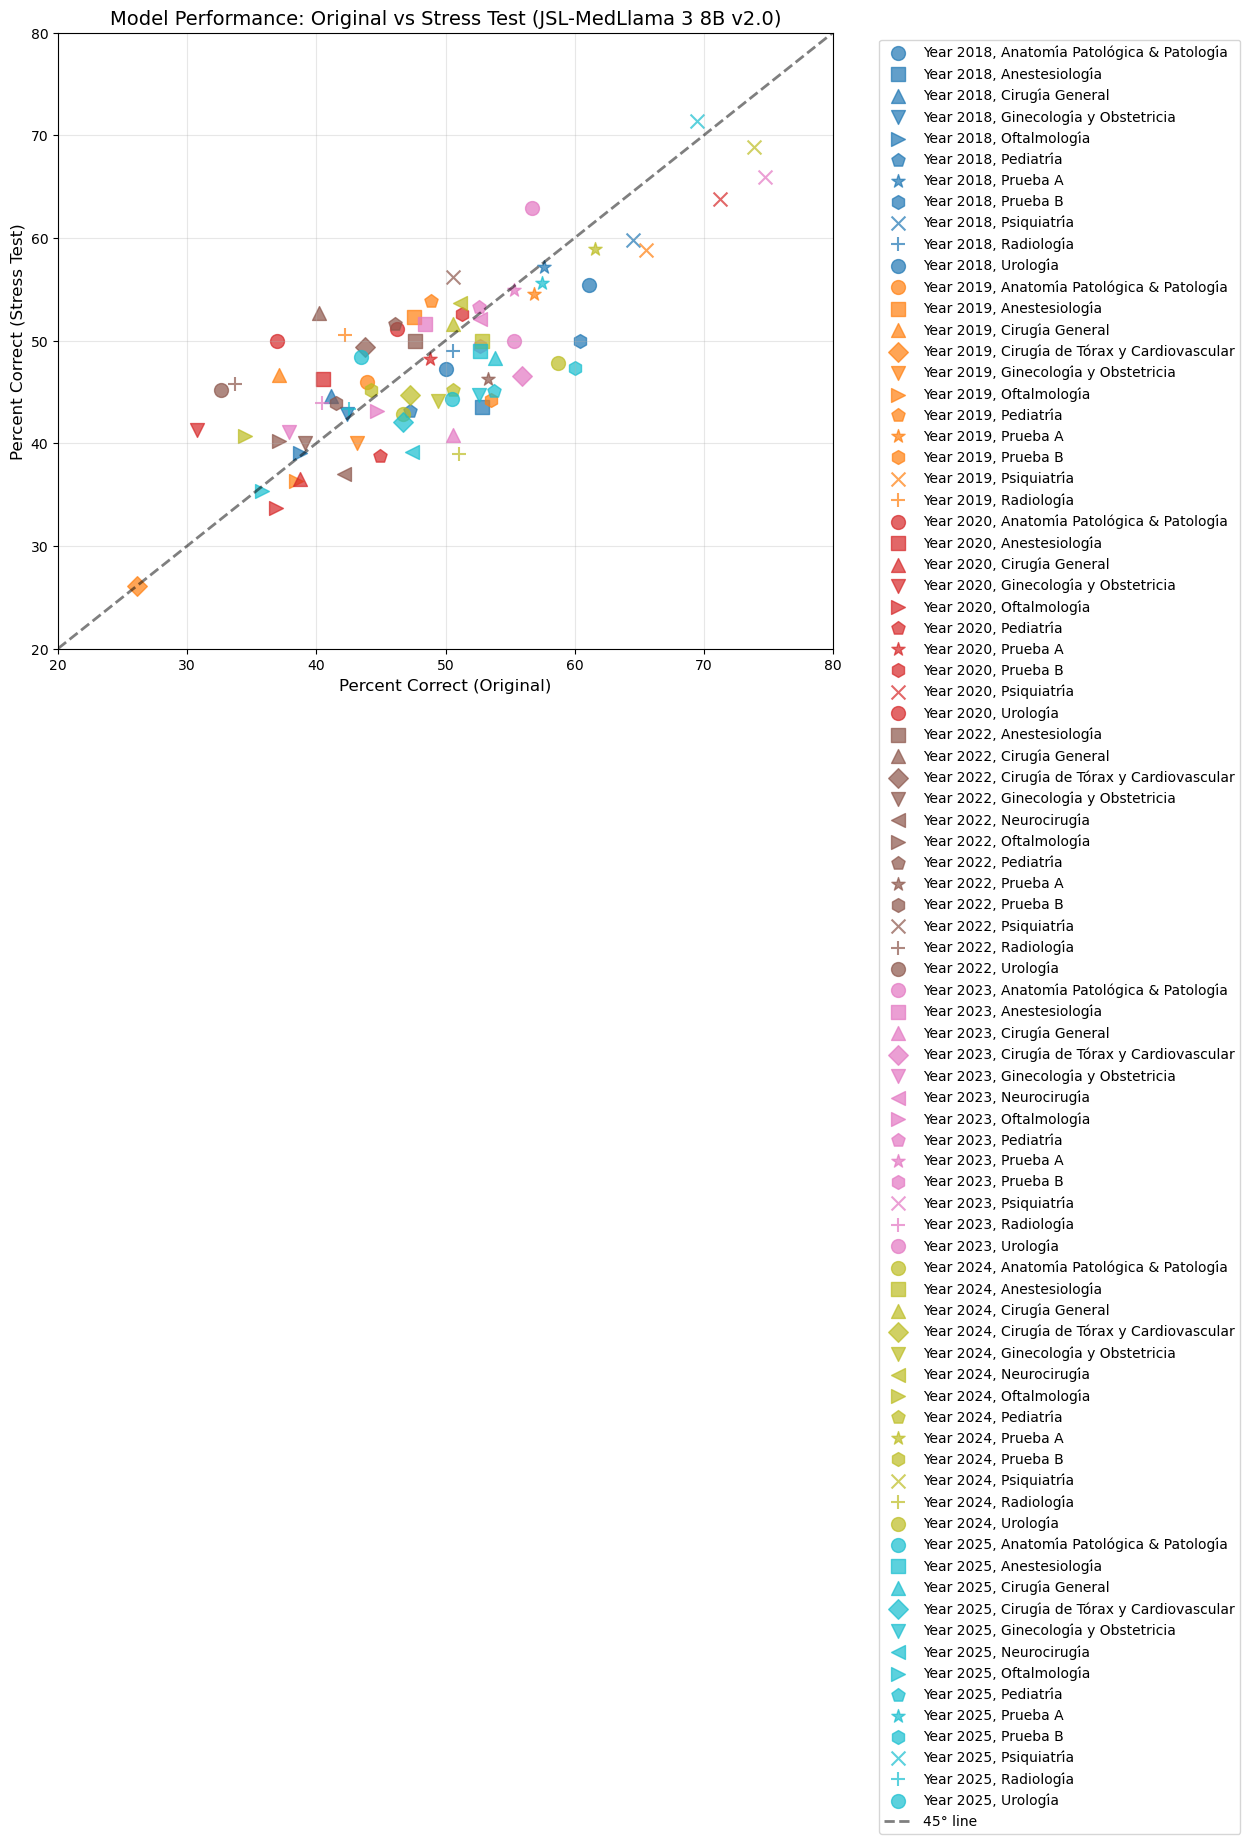

In [6]:
# Define marker styles for source_file
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h', 'x', '+']
marker_cycle = cycle(markers)
marker_map = {source: next(marker_cycle) for source in df_old_new_JSL_MedLlama['source_file'].unique()}

# Get unique years and source files
years = sorted(df_old_new_JSL_MedLlama['year'].unique())
source_files = sorted(df_old_new_JSL_MedLlama['source_file'].unique())

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 8))

# Create a color map for years
colors = plt.cm.tab10(np.linspace(0, 1, len(years)))
color_map = {year: colors[i] for i, year in enumerate(years)}

# Plot points colored by year with markers by source_file
for year in years:
    for source_file in source_files:
        mask = (df_old_new_JSL_MedLlama['year'] == year) & (df_old_new_JSL_MedLlama['source_file'] == source_file)
        data = df_old_new_JSL_MedLlama[mask]
        if len(data) > 0:
            ax.scatter(
                data['percentage_correct_old'],
                data['percentage_correct_new'],
                marker=marker_map[source_file],
                color=color_map[year],
                s=100,
                alpha=0.7,
                label=f"Year {year}, {source_file}"
            )

# Add 45-degree line
ax.plot([20, 100], [20, 100], 'k--', label='45° line', linewidth=2, alpha=0.5)

# Set axis limits and labels
ax.set_xlim(20, 80)
ax.set_ylim(20, 80)
ax.set_xlabel('Percent Correct (Original)', fontsize=12)
ax.set_ylabel('Percent Correct (Stress Test)', fontsize=12)
ax.set_title('Model Performance: Original vs Stress Test (JSL-MedLlama 3 8B v2.0)', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

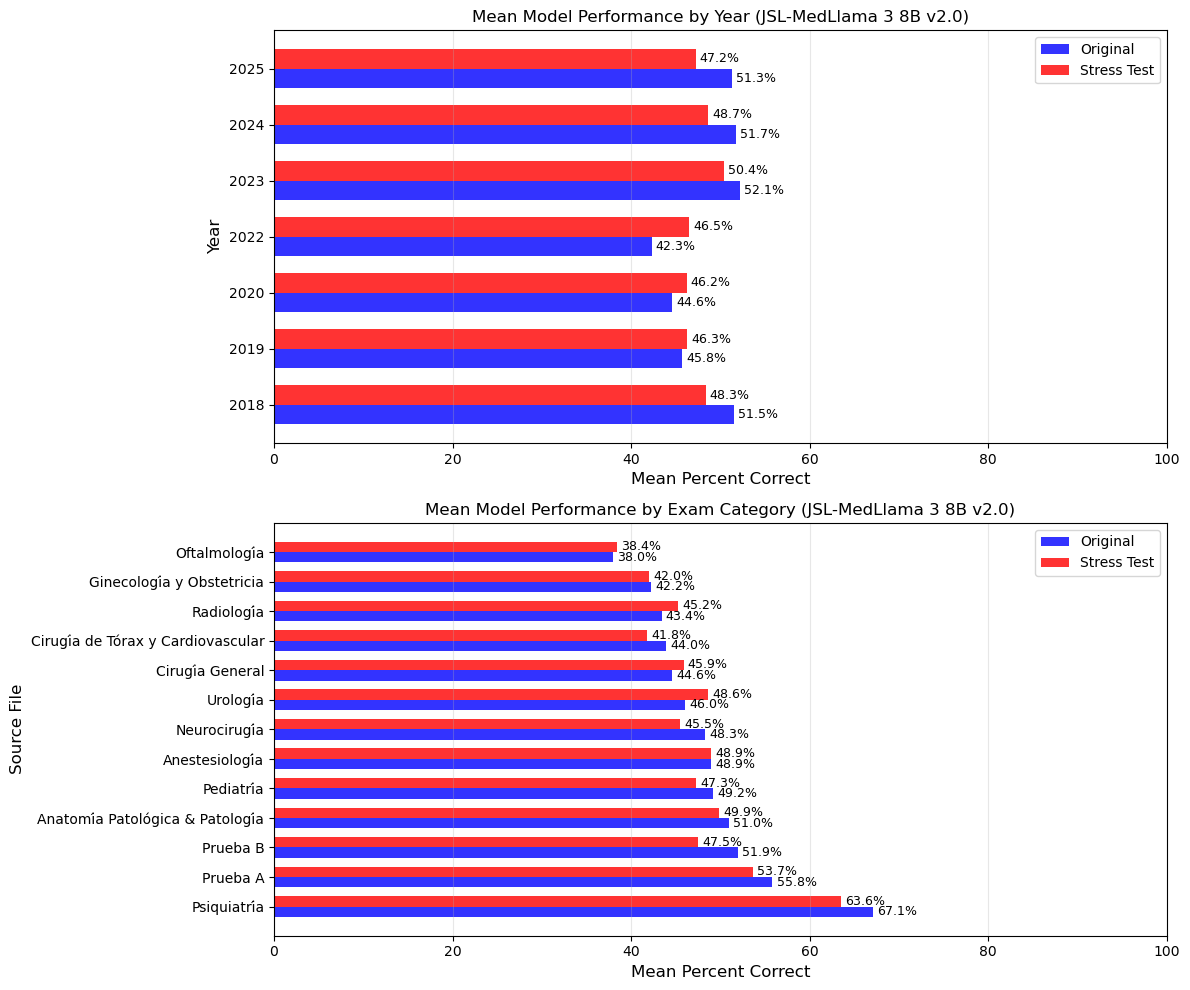

In [8]:
# Bar plot: Mean performance by year
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Group by year and calculate means
year_stats = df_old_new_JSL_MedLlama.groupby('year')[['percentage_correct_old', 'percentage_correct_new']].mean()

# Bar plot 1: Mean performance by year
x_pos = np.arange(len(year_stats.index))
width = 0.35

bars_old_year = axes[0].barh(
    x_pos - width/2,
    year_stats['percentage_correct_old'],
    height=width,
    label='Original',
    color='blue',
    alpha=0.8
)
bars_new_year = axes[0].barh(
    x_pos + width/2,
    year_stats['percentage_correct_new'],
    height=width,
    label='Stress Test',
    color='red',
    alpha=0.8
)
axes[0].bar_label(bars_old_year, fmt='%.1f%%', padding=3, fontsize=9)
axes[0].bar_label(bars_new_year, fmt='%.1f%%', padding=3, fontsize=9)
axes[0].set_ylabel('Year', fontsize=12)
axes[0].set_xlabel('Mean Percent Correct', fontsize=12)
axes[0].set_xlim(0, 100)
axes[0].set_title('Mean Model Performance by Year (JSL-MedLlama 3 8B v2.0)', fontsize=12)
axes[0].set_yticks(x_pos)
axes[0].set_yticklabels(year_stats.index)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='x')

# Bar plot 2: Mean performance by source_file
source_stats = df_old_new_JSL_MedLlama.groupby('source_file')[['percentage_correct_old', 'percentage_correct_new']].mean().sort_values('percentage_correct_old', ascending=False)

x_pos = np.arange(len(source_stats.index))
bars_old_source = axes[1].barh(
    x_pos - width/2,
    source_stats['percentage_correct_old'],
    height=width,
    label='Original',
    color='blue',
    alpha=0.8
)
bars_new_source = axes[1].barh(
    x_pos + width/2,
    source_stats['percentage_correct_new'],
    height=width,
    label='Stress Test',
    color='red',
    alpha=0.8
)
axes[1].bar_label(bars_old_source, fmt='%.1f%%', padding=3, fontsize=9)
axes[1].bar_label(bars_new_source, fmt='%.1f%%', padding=3, fontsize=9)
axes[1].set_ylabel('Source File', fontsize=12)
axes[1].set_xlabel('Mean Percent Correct', fontsize=12)
axes[1].set_xlim(0, 100)
axes[1].set_title('Mean Model Performance by Exam Category (JSL-MedLlama 3 8B v2.0)', fontsize=12)
axes[1].set_yticks(x_pos)
axes[1].set_yticklabels(source_stats.index)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

In [9]:
# Prepare data for paired tests
# Remove rows with missing values in either column
data_paired = df_old_new_JSL_MedLlama[['percentage_correct_old', 'percentage_correct_new']].dropna()

print("=" * 70)
print("STATISTICAL TESTS: Original vs Stress Test Performance")
print("=" * 70)

# 1. Check normality of differences
differences = data_paired['percentage_correct_new'] - data_paired['percentage_correct_old']
stat_shapiro, p_shapiro = stats.shapiro(differences)
print(f"\n1. NORMALITY TEST (Shapiro-Wilk on differences):")
print(f"   Test Statistic: {stat_shapiro:.4f}")
print(f"   p-value: {p_shapiro:.6f}")
print(f"   Result: {'Data is normally distributed' if p_shapiro > 0.05 else 'Data deviates from normality'} (α=0.05)")

# 2. Paired t-test (parametric)
t_stat, p_ttest = stats.ttest_rel(data_paired['percentage_correct_new'], 
                                   data_paired['percentage_correct_old'])
mean_diff = differences.mean()
std_diff = differences.std()

print(f"\n2. PAIRED T-TEST (parametric):")
print(f"   Mean difference (Stress Test - Original): {mean_diff:.4f}%")
print(f"   Std deviation of differences: {std_diff:.4f}%")
print(f"   t-statistic: {t_stat:.4f}")
print(f"   p-value: {p_ttest:.6f}")
print(f"   Result: {'SIGNIFICANT difference' if p_ttest < 0.05 else 'No significant difference'} (α=0.05)")

# 3. Wilcoxon Signed-Rank Test (non-parametric alternative)
w_stat, p_wilcox = stats.wilcoxon(data_paired['percentage_correct_new'], 
                                    data_paired['percentage_correct_old'])
print(f"\n3. WILCOXON SIGNED-RANK TEST (non-parametric alternative):")
print(f"   W-statistic: {w_stat:.4f}")
print(f"   p-value: {p_wilcox:.6f}")
print(f"   Result: {'SIGNIFICANT difference' if p_wilcox < 0.05 else 'No significant difference'} (α=0.05)")

# 4. Effect size (Cohen's d for paired samples)
cohens_d = mean_diff / std_diff
print(f"\n4. EFFECT SIZE (Cohen's d):")
print(f"   Cohen's d: {cohens_d:.4f}")
if abs(cohens_d) < 0.2:
    effect_interpretation = "negligible"
elif abs(cohens_d) < 0.5:
    effect_interpretation = "small"
elif abs(cohens_d) < 0.8:
    effect_interpretation = "medium"
else:
    effect_interpretation = "large"
print(f"   Interpretation: {effect_interpretation.upper()} effect")

# 5. Descriptive statistics
print(f"\n5. DESCRIPTIVE STATISTICS:")
print(f"   N (paired observations): {len(data_paired)}")
print(f"   Original - Mean: {data_paired['percentage_correct_old'].mean():.2f}%, Std: {data_paired['percentage_correct_old'].std():.2f}%")
print(f"   Stress Test - Mean: {data_paired['percentage_correct_new'].mean():.2f}%, Std: {data_paired['percentage_correct_new'].std():.2f}%")

# Count improvements/declines
improvements = (differences > 0).sum()
declines = (differences < 0).sum()
no_change = (differences == 0).sum()

print(f"\n6. DIRECTION OF CHANGE:")
print(f"   Improved (Stress Test > Original): {improvements} ({100*improvements/len(data_paired):.1f}%)")
print(f"   Declined (Stress Test < Original): {declines} ({100*declines/len(data_paired):.1f}%)")
print(f"   No change: {no_change} ({100*no_change/len(data_paired):.1f}%)")

print("\n" + "=" * 70)
print("RECOMMENDATION:")
print("=" * 70)
if p_shapiro > 0.05:
    print("✓ Data appears normally distributed, paired t-test is appropriate.")
else:
    print("✗ Data deviates from normality. Consider using the Wilcoxon test.")
    print("  Both tests are shown above for comparison.")
print("=" * 70)

STATISTICAL TESTS: Original vs Stress Test Performance

1. NORMALITY TEST (Shapiro-Wilk on differences):
   Test Statistic: 0.9814
   p-value: 0.272036
   Result: Data is normally distributed (α=0.05)

2. PAIRED T-TEST (parametric):
   Mean difference (Stress Test - Original): -0.9236%
   Std deviation of differences: 6.0386%
   t-statistic: -1.3934
   p-value: 0.167249
   Result: No significant difference (α=0.05)

3. WILCOXON SIGNED-RANK TEST (non-parametric alternative):
   W-statistic: 1373.0000
   p-value: 0.128853
   Result: No significant difference (α=0.05)

4. EFFECT SIZE (Cohen's d):
   Cohen's d: -0.1530
   Interpretation: NEGLIGIBLE effect

5. DESCRIPTIVE STATISTICS:
   N (paired observations): 83
   Original - Mean: 48.68%, Std: 9.60%
   Stress Test - Mean: 47.75%, Std: 7.84%

6. DIRECTION OF CHANGE:
   Improved (Stress Test > Original): 35 (42.2%)
   Declined (Stress Test < Original): 47 (56.6%)
   No change: 1 (1.2%)

RECOMMENDATION:
✓ Data appears normally distributed, 

In [10]:
# Stratified analysis by YEAR
print("\n" + "=" * 90)
print("STRATIFIED ANALYSIS BY YEAR")
print("=" * 90)

results_by_year = []

for year in sorted(df_old_new_JSL_MedLlama['year'].unique()):
    year_data = df_old_new_JSL_MedLlama[df_old_new_JSL_MedLlama['year'] == year][['percentage_correct_old', 'percentage_correct_new']].dropna()
    
    if len(year_data) < 2:
        continue
    
    year_diff = year_data['percentage_correct_new'] - year_data['percentage_correct_old']
    t_stat_y, p_ttest_y = stats.ttest_rel(year_data['percentage_correct_new'], year_data['percentage_correct_old'])
    w_stat_y, p_wilcox_y = stats.wilcoxon(year_data['percentage_correct_new'], year_data['percentage_correct_old'])
    cohens_d_y = year_diff.mean() / year_diff.std() if year_diff.std() > 0 else 0
    
    results_by_year.append({
        'Year': year,
        'N': len(year_data),
        'Mean_Diff': year_diff.mean(),
        'Std_Diff': year_diff.std(),
        'T_stat': t_stat_y,
        'P_ttest': p_ttest_y,
        'P_wilcox': p_wilcox_y,
        'Cohens_d': cohens_d_y,
        'Original_Mean': year_data['percentage_correct_old'].mean(),
        'Stress_Mean': year_data['percentage_correct_new'].mean()
    })

results_by_year_df = pd.DataFrame(results_by_year)

print("\nYear-by-Year Summary:")
print("-" * 90)
for idx, row in results_by_year_df.iterrows():
    sig_ttest = "***" if row['P_ttest'] < 0.05 else ""
    sig_wilcox = "***" if row['P_wilcox'] < 0.05 else ""
    print(f"Year {int(row['Year'])} (N={int(row['N'])}):")
    print(f"  Original: {row['Original_Mean']:.2f}% → Stress: {row['Stress_Mean']:.2f}% (Δ = {row['Mean_Diff']:+.2f}%)")
    print(f"  T-test p-value: {row['P_ttest']:.4f} {sig_ttest}  |  Wilcoxon p-value: {row['P_wilcox']:.4f} {sig_wilcox}")
    print(f"  Cohen's d: {row['Cohens_d']:.4f}")
    print()

# Stratified analysis by SOURCE FILE
print("=" * 90)
print("STRATIFIED ANALYSIS BY SOURCE FILE (EXAM CATEGORY)")
print("=" * 90)

results_by_source = []

for source_file in sorted(df_old_new_JSL_MedLlama['source_file'].unique()):
    source_data = df_old_new_JSL_MedLlama[df_old_new_JSL_MedLlama['source_file'] == source_file][['percentage_correct_old', 'percentage_correct_new']].dropna()
    
    if len(source_data) < 2:
        continue
    
    source_diff = source_data['percentage_correct_new'] - source_data['percentage_correct_old']
    t_stat_s, p_ttest_s = stats.ttest_rel(source_data['percentage_correct_new'], source_data['percentage_correct_old'])
    w_stat_s, p_wilcox_s = stats.wilcoxon(source_data['percentage_correct_new'], source_data['percentage_correct_old'])
    cohens_d_s = source_diff.mean() / source_diff.std() if source_diff.std() > 0 else 0
    
    results_by_source.append({
        'Source_File': source_file,
        'N': len(source_data),
        'Mean_Diff': source_diff.mean(),
        'Std_Diff': source_diff.std(),
        'T_stat': t_stat_s,
        'P_ttest': p_ttest_s,
        'P_wilcox': p_wilcox_s,
        'Cohens_d': cohens_d_s,
        'Original_Mean': source_data['percentage_correct_old'].mean(),
        'Stress_Mean': source_data['percentage_correct_new'].mean()
    })

results_by_source_df = pd.DataFrame(results_by_source).sort_values('Original_Mean', ascending=False)

print("\nSource File-by-Source File Summary:")
print("-" * 90)
for idx, row in results_by_source_df.iterrows():
    sig_ttest = "***" if row['P_ttest'] < 0.05 else ""
    sig_wilcox = "***" if row['P_wilcox'] < 0.05 else ""
    print(f"{row['Source_File']} (N={int(row['N'])}):")
    print(f"  Original: {row['Original_Mean']:.2f}% → Stress: {row['Stress_Mean']:.2f}% (Δ = {row['Mean_Diff']:+.2f}%)")
    print(f"  T-test p-value: {row['P_ttest']:.4f} {sig_ttest}  |  Wilcoxon p-value: {row['P_wilcox']:.4f} {sig_wilcox}")
    print(f"  Cohen's d: {row['Cohens_d']:.4f}")
    print()

print("=" * 90)
print("LEGEND: *** indicates p < 0.05 (statistically significant)")
print("=" * 90)


STRATIFIED ANALYSIS BY YEAR

Year-by-Year Summary:
------------------------------------------------------------------------------------------
Year 2018 (N=11):
  Original: 51.50% → Stress: 48.34% (Δ = -3.16%)
  T-test p-value: 0.0329 ***  |  Wilcoxon p-value: 0.0342 ***
  Cohen's d: -0.7460

Year 2019 (N=11):
  Original: 45.75% → Stress: 46.31% (Δ = +0.56%)
  T-test p-value: 0.7648   |  Wilcoxon p-value: 0.8457 
  Cohen's d: 0.0927

Year 2020 (N=10):
  Original: 44.63% → Stress: 46.22% (Δ = +1.59%)
  T-test p-value: 0.4822   |  Wilcoxon p-value: 0.6953 
  Cohen's d: 0.2318

Year 2022 (N=12):
  Original: 42.30% → Stress: 46.51% (Δ = +4.21%)
  T-test p-value: 0.0412 ***  |  Wilcoxon p-value: 0.0522 
  Cohen's d: 0.6672

Year 2023 (N=13):
  Original: 52.15% → Stress: 50.43% (Δ = -1.71%)
  T-test p-value: 0.2649   |  Wilcoxon p-value: 0.3757 
  Cohen's d: -0.3244

Year 2024 (N=13):
  Original: 51.71% → Stress: 48.66% (Δ = -3.06%)
  T-test p-value: 0.0506   |  Wilcoxon p-value: 0.0500 
  C

# 10.OctoMed-7B

In [7]:
df_old_octomed = pd.read_pickle(f'/Users/rodrigocarrillo/Documents/Natural Language Processing Projects/Examen Residentado Peru/02.LLMs Results/10.OctoMed-7B/{file_name}')
df_old_octomed = df_old_octomed.rename(columns={"count_of_matches": "count_of_matches_old", "total_rows": "total_rows_old", "percent_correct": "percentage_correct_old"})
df_old_octomed.head()

,source_file,year,count_of_matches_old,total_rows_old,percentage_correct_old,model_name
0,Anatomía Patológica & Patología,2018,79,100,79.0,OctoMed-7B
1,Anatomía Patológica & Patología,2019,75,100,75.0,OctoMed-7B
2,Anatomía Patológica & Patología,2020,83,100,83.0,OctoMed-7B
3,Anatomía Patológica & Patología,2023,82,100,82.0,OctoMed-7B
4,Anatomía Patológica & Patología,2024,81,100,81.0,OctoMed-7B


In [8]:
df_new_octomed = pd.read_pickle(f'/Users/rodrigocarrillo/Documents/Natural Language Processing Projects/Examen Residentado Peru/02.LLMs Results/Reorder Options/10.OctoMed-7B/{file_name}')
df_new_octomed = df_new_octomed.rename(columns={"count_of_matches": "count_of_matches_new", "total_rows": "total_rows_new", "percent_correct": "percentage_correct_new"})
df_new_octomed.head()

,source_file,year,count_of_matches_new,total_rows_new,percentage_correct_new,model_name
0,Anatomía Patológica & Patología,2018,78,100,78.00,OctoMed-7B
1,Anatomía Patológica & Patología,2019,75,100,75.00,OctoMed-7B
2,Anatomía Patológica & Patología,2020,86,99,86.87,OctoMed-7B
3,Anatomía Patológica & Patología,2023,81,100,81.00,OctoMed-7B
4,Anatomía Patológica & Patología,2024,85,100,85.00,OctoMed-7B


In [9]:
df_old_new_octomed = pd.merge(df_old_octomed, df_new_octomed, on=["source_file", "year", "model_name"], how="outer")
df_old_new_octomed

,source_file,year,count_of_matches_old,total_rows_old,percentage_correct_old,model_name,count_of_matches_new,total_rows_new,percentage_correct_new
0,Anatomía Patológica & Patología,2018,79,100,79.0,OctoMed-7B,78,100,78.00
1,Anatomía Patológica & Patología,2019,75,100,75.0,OctoMed-7B,75,100,75.00
2,Anatomía Patológica & Patología,2020,83,100,83.0,OctoMed-7B,86,99,86.87
3,Anatomía Patológica & Patología,2023,82,100,82.0,OctoMed-7B,81,100,81.00
4,Anatomía Patológica & Patología,2024,81,100,81.0,OctoMed-7B,85,100,85.00
...,...,...,...,...,...,...,...,...,...
78,Urología,2020,73,100,73.0,OctoMed-7B,73,100,73.00
79,Urología,2022,81,100,81.0,OctoMed-7B,78,100,78.00
80,Urología,2023,79,100,79.0,OctoMed-7B,82,100,82.00
81,Urología,2024,71,100,71.0,OctoMed-7B,71,100,71.00


/var/folders/0p/pq1qfwzj0bz0b4wsym558qgw0000gn/T/ipykernel_14488/1557255388.py:45: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


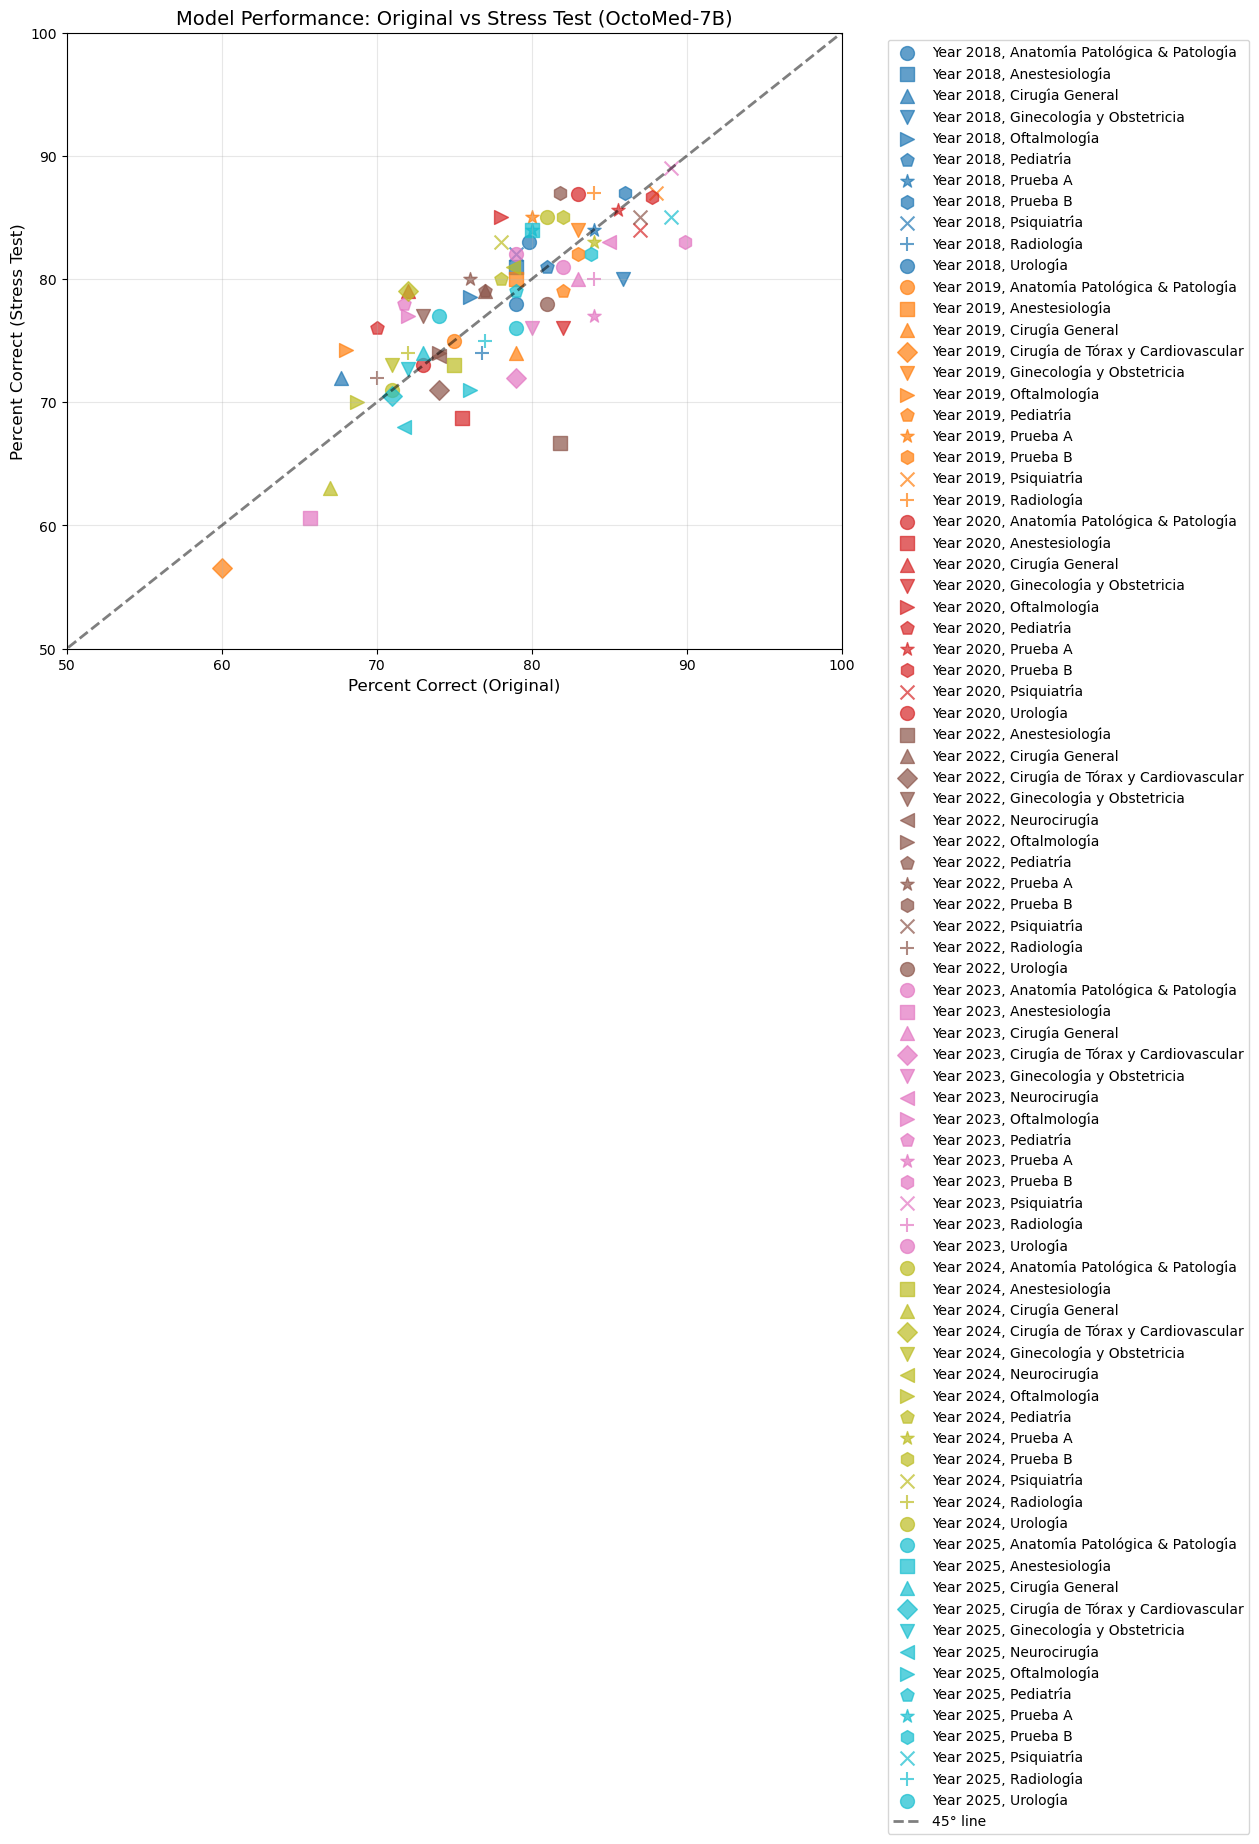

In [11]:
# Define marker styles for source_file
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h', 'x', '+']
marker_cycle = cycle(markers)
marker_map = {source: next(marker_cycle) for source in df_old_new_octomed['source_file'].unique()}

# Get unique years and source files
years = sorted(df_old_new_octomed['year'].unique())
source_files = sorted(df_old_new_octomed['source_file'].unique())

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 8))

# Create a color map for years
colors = plt.cm.tab10(np.linspace(0, 1, len(years)))
color_map = {year: colors[i] for i, year in enumerate(years)}

# Plot points colored by year with markers by source_file
for year in years:
    for source_file in source_files:
        mask = (df_old_new_octomed['year'] == year) & (df_old_new_octomed['source_file'] == source_file)
        data = df_old_new_octomed[mask]
        if len(data) > 0:
            ax.scatter(
                data['percentage_correct_old'],
                data['percentage_correct_new'],
                marker=marker_map[source_file],
                color=color_map[year],
                s=100,
                alpha=0.7,
                label=f"Year {year}, {source_file}"
            )

# Add 45-degree line
ax.plot([20, 100], [20, 100], 'k--', label='45° line', linewidth=2, alpha=0.5)

# Set axis limits and labels
ax.set_xlim(50, 100)
ax.set_ylim(50, 100)
ax.set_xlabel('Percent Correct (Original)', fontsize=12)
ax.set_ylabel('Percent Correct (Stress Test)', fontsize=12)
ax.set_title('Model Performance: Original vs Stress Test (OctoMed-7B)', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

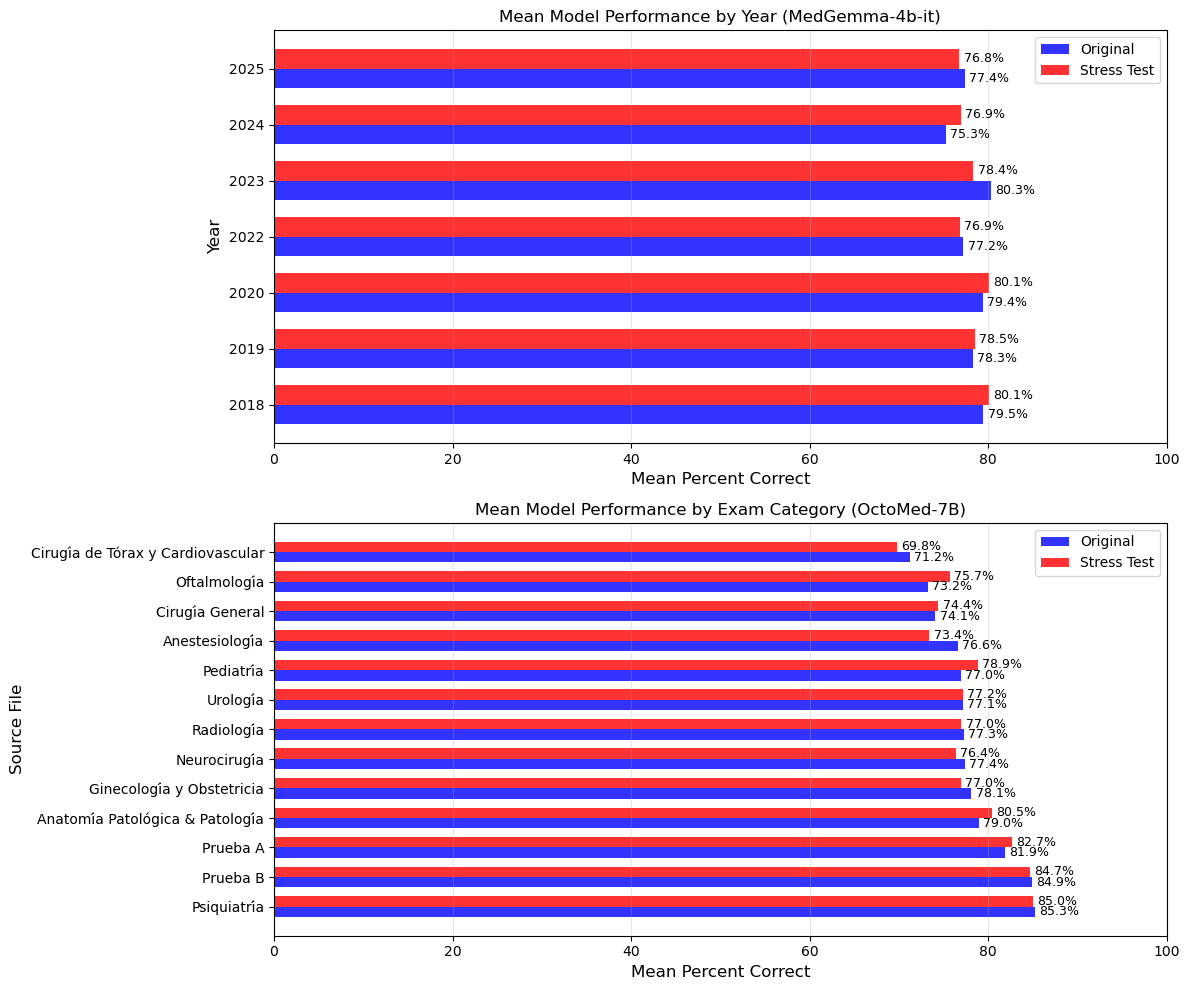

In [12]:
# Bar plot: Mean performance by year
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Group by year and calculate means
year_stats = df_old_new_octomed.groupby('year')[['percentage_correct_old', 'percentage_correct_new']].mean()

# Bar plot 1: Mean performance by year
x_pos = np.arange(len(year_stats.index))
width = 0.35

bars_old_year = axes[0].barh(
    x_pos - width/2,
    year_stats['percentage_correct_old'],
    height=width,
    label='Original',
    color='blue',
    alpha=0.8
)
bars_new_year = axes[0].barh(
    x_pos + width/2,
    year_stats['percentage_correct_new'],
    height=width,
    label='Stress Test',
    color='red',
    alpha=0.8
)
axes[0].bar_label(bars_old_year, fmt='%.1f%%', padding=3, fontsize=9)
axes[0].bar_label(bars_new_year, fmt='%.1f%%', padding=3, fontsize=9)
axes[0].set_ylabel('Year', fontsize=12)
axes[0].set_xlabel('Mean Percent Correct', fontsize=12)
axes[0].set_xlim(0, 100)
axes[0].set_title('Mean Model Performance by Year (MedGemma-4b-it)', fontsize=12)
axes[0].set_yticks(x_pos)
axes[0].set_yticklabels(year_stats.index)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='x')

# Bar plot 2: Mean performance by source_file
source_stats = df_old_new_octomed.groupby('source_file')[['percentage_correct_old', 'percentage_correct_new']].mean().sort_values('percentage_correct_old', ascending=False)

x_pos = np.arange(len(source_stats.index))
bars_old_source = axes[1].barh(
    x_pos - width/2,
    source_stats['percentage_correct_old'],
    height=width,
    label='Original',
    color='blue',
    alpha=0.8
)
bars_new_source = axes[1].barh(
    x_pos + width/2,
    source_stats['percentage_correct_new'],
    height=width,
    label='Stress Test',
    color='red',
    alpha=0.8
)
axes[1].bar_label(bars_old_source, fmt='%.1f%%', padding=3, fontsize=9)
axes[1].bar_label(bars_new_source, fmt='%.1f%%', padding=3, fontsize=9)
axes[1].set_ylabel('Source File', fontsize=12)
axes[1].set_xlabel('Mean Percent Correct', fontsize=12)
axes[1].set_xlim(0, 100)
axes[1].set_title('Mean Model Performance by Exam Category (OctoMed-7B)', fontsize=12)
axes[1].set_yticks(x_pos)
axes[1].set_yticklabels(source_stats.index)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

In [13]:
# Prepare data for paired tests
# Remove rows with missing values in either column
data_paired = df_old_new_octomed[['percentage_correct_old', 'percentage_correct_new']].dropna()

print("=" * 70)
print("STATISTICAL TESTS: Original vs Stress Test Performance")
print("=" * 70)

# 1. Check normality of differences
differences = data_paired['percentage_correct_new'] - data_paired['percentage_correct_old']
stat_shapiro, p_shapiro = stats.shapiro(differences)
print(f"\n1. NORMALITY TEST (Shapiro-Wilk on differences):")
print(f"   Test Statistic: {stat_shapiro:.4f}")
print(f"   p-value: {p_shapiro:.6f}")
print(f"   Result: {'Data is normally distributed' if p_shapiro > 0.05 else 'Data deviates from normality'} (α=0.05)")

# 2. Paired t-test (parametric)
t_stat, p_ttest = stats.ttest_rel(data_paired['percentage_correct_new'], 
                                   data_paired['percentage_correct_old'])
mean_diff = differences.mean()
std_diff = differences.std()

print(f"\n2. PAIRED T-TEST (parametric):")
print(f"   Mean difference (Stress Test - Original): {mean_diff:.4f}%")
print(f"   Std deviation of differences: {std_diff:.4f}%")
print(f"   t-statistic: {t_stat:.4f}")
print(f"   p-value: {p_ttest:.6f}")
print(f"   Result: {'SIGNIFICANT difference' if p_ttest < 0.05 else 'No significant difference'} (α=0.05)")

# 3. Wilcoxon Signed-Rank Test (non-parametric alternative)
w_stat, p_wilcox = stats.wilcoxon(data_paired['percentage_correct_new'], 
                                    data_paired['percentage_correct_old'])
print(f"\n3. WILCOXON SIGNED-RANK TEST (non-parametric alternative):")
print(f"   W-statistic: {w_stat:.4f}")
print(f"   p-value: {p_wilcox:.6f}")
print(f"   Result: {'SIGNIFICANT difference' if p_wilcox < 0.05 else 'No significant difference'} (α=0.05)")

# 4. Effect size (Cohen's d for paired samples)
cohens_d = mean_diff / std_diff
print(f"\n4. EFFECT SIZE (Cohen's d):")
print(f"   Cohen's d: {cohens_d:.4f}")
if abs(cohens_d) < 0.2:
    effect_interpretation = "negligible"
elif abs(cohens_d) < 0.5:
    effect_interpretation = "small"
elif abs(cohens_d) < 0.8:
    effect_interpretation = "medium"
else:
    effect_interpretation = "large"
print(f"   Interpretation: {effect_interpretation.upper()} effect")

# 5. Descriptive statistics
print(f"\n5. DESCRIPTIVE STATISTICS:")
print(f"   N (paired observations): {len(data_paired)}")
print(f"   Original - Mean: {data_paired['percentage_correct_old'].mean():.2f}%, Std: {data_paired['percentage_correct_old'].std():.2f}%")
print(f"   Stress Test - Mean: {data_paired['percentage_correct_new'].mean():.2f}%, Std: {data_paired['percentage_correct_new'].std():.2f}%")

# Count improvements/declines
improvements = (differences > 0).sum()
declines = (differences < 0).sum()
no_change = (differences == 0).sum()

print(f"\n6. DIRECTION OF CHANGE:")
print(f"   Improved (Stress Test > Original): {improvements} ({100*improvements/len(data_paired):.1f}%)")
print(f"   Declined (Stress Test < Original): {declines} ({100*declines/len(data_paired):.1f}%)")
print(f"   No change: {no_change} ({100*no_change/len(data_paired):.1f}%)")

print("\n" + "=" * 70)
print("RECOMMENDATION:")
print("=" * 70)
if p_shapiro > 0.05:
    print("✓ Data appears normally distributed, paired t-test is appropriate.")
else:
    print("✗ Data deviates from normality. Consider using the Wilcoxon test.")
    print("  Both tests are shown above for comparison.")
print("=" * 70)

STATISTICAL TESTS: Original vs Stress Test Performance

1. NORMALITY TEST (Shapiro-Wilk on differences):
   Test Statistic: 0.9660
   p-value: 0.027107
   Result: Data deviates from normality (α=0.05)

2. PAIRED T-TEST (parametric):
   Mean difference (Stress Test - Original): 0.0059%
   Std deviation of differences: 4.0158%
   t-statistic: 0.0134
   p-value: 0.989347
   Result: No significant difference (α=0.05)

3. WILCOXON SIGNED-RANK TEST (non-parametric alternative):
   W-statistic: 1325.5000
   p-value: 0.738043
   Result: No significant difference (α=0.05)

4. EFFECT SIZE (Cohen's d):
   Cohen's d: 0.0015
   Interpretation: NEGLIGIBLE effect

5. DESCRIPTIVE STATISTICS:
   N (paired observations): 83
   Original - Mean: 78.12%, Std: 6.09%
   Stress Test - Mean: 78.13%, Std: 6.36%

6. DIRECTION OF CHANGE:
   Improved (Stress Test > Original): 38 (45.8%)
   Declined (Stress Test < Original): 36 (43.4%)
   No change: 9 (10.8%)

RECOMMENDATION:
✗ Data deviates from normality. Conside

In [14]:
# Stratified analysis by YEAR
print("\n" + "=" * 90)
print("STRATIFIED ANALYSIS BY YEAR")
print("=" * 90)

results_by_year = []

for year in sorted(df_old_new_octomed['year'].unique()):
    year_data = df_old_new_octomed[df_old_new_octomed['year'] == year][['percentage_correct_old', 'percentage_correct_new']].dropna()
    
    if len(year_data) < 2:
        continue
    
    year_diff = year_data['percentage_correct_new'] - year_data['percentage_correct_old']
    t_stat_y, p_ttest_y = stats.ttest_rel(year_data['percentage_correct_new'], year_data['percentage_correct_old'])
    w_stat_y, p_wilcox_y = stats.wilcoxon(year_data['percentage_correct_new'], year_data['percentage_correct_old'])
    cohens_d_y = year_diff.mean() / year_diff.std() if year_diff.std() > 0 else 0
    
    results_by_year.append({
        'Year': year,
        'N': len(year_data),
        'Mean_Diff': year_diff.mean(),
        'Std_Diff': year_diff.std(),
        'T_stat': t_stat_y,
        'P_ttest': p_ttest_y,
        'P_wilcox': p_wilcox_y,
        'Cohens_d': cohens_d_y,
        'Original_Mean': year_data['percentage_correct_old'].mean(),
        'Stress_Mean': year_data['percentage_correct_new'].mean()
    })

results_by_year_df = pd.DataFrame(results_by_year)

print("\nYear-by-Year Summary:")
print("-" * 90)
for idx, row in results_by_year_df.iterrows():
    sig_ttest = "***" if row['P_ttest'] < 0.05 else ""
    sig_wilcox = "***" if row['P_wilcox'] < 0.05 else ""
    print(f"Year {int(row['Year'])} (N={int(row['N'])}):")
    print(f"  Original: {row['Original_Mean']:.2f}% → Stress: {row['Stress_Mean']:.2f}% (Δ = {row['Mean_Diff']:+.2f}%)")
    print(f"  T-test p-value: {row['P_ttest']:.4f} {sig_ttest}  |  Wilcoxon p-value: {row['P_wilcox']:.4f} {sig_wilcox}")
    print(f"  Cohen's d: {row['Cohens_d']:.4f}")
    print()

# Stratified analysis by SOURCE FILE
print("=" * 90)
print("STRATIFIED ANALYSIS BY SOURCE FILE (EXAM CATEGORY)")
print("=" * 90)

results_by_source = []

for source_file in sorted(df_old_new_octomed['source_file'].unique()):
    source_data = df_old_new_octomed[df_old_new_octomed['source_file'] == source_file][['percentage_correct_old', 'percentage_correct_new']].dropna()
    
    if len(source_data) < 2:
        continue
    
    source_diff = source_data['percentage_correct_new'] - source_data['percentage_correct_old']
    t_stat_s, p_ttest_s = stats.ttest_rel(source_data['percentage_correct_new'], source_data['percentage_correct_old'])
    w_stat_s, p_wilcox_s = stats.wilcoxon(source_data['percentage_correct_new'], source_data['percentage_correct_old'])
    cohens_d_s = source_diff.mean() / source_diff.std() if source_diff.std() > 0 else 0
    
    results_by_source.append({
        'Source_File': source_file,
        'N': len(source_data),
        'Mean_Diff': source_diff.mean(),
        'Std_Diff': source_diff.std(),
        'T_stat': t_stat_s,
        'P_ttest': p_ttest_s,
        'P_wilcox': p_wilcox_s,
        'Cohens_d': cohens_d_s,
        'Original_Mean': source_data['percentage_correct_old'].mean(),
        'Stress_Mean': source_data['percentage_correct_new'].mean()
    })

results_by_source_df = pd.DataFrame(results_by_source).sort_values('Original_Mean', ascending=False)

print("\nSource File-by-Source File Summary:")
print("-" * 90)
for idx, row in results_by_source_df.iterrows():
    sig_ttest = "***" if row['P_ttest'] < 0.05 else ""
    sig_wilcox = "***" if row['P_wilcox'] < 0.05 else ""
    print(f"{row['Source_File']} (N={int(row['N'])}):")
    print(f"  Original: {row['Original_Mean']:.2f}% → Stress: {row['Stress_Mean']:.2f}% (Δ = {row['Mean_Diff']:+.2f}%)")
    print(f"  T-test p-value: {row['P_ttest']:.4f} {sig_ttest}  |  Wilcoxon p-value: {row['P_wilcox']:.4f} {sig_wilcox}")
    print(f"  Cohen's d: {row['Cohens_d']:.4f}")
    print()

print("=" * 90)
print("LEGEND: *** indicates p < 0.05 (statistically significant)")
print("=" * 90)


STRATIFIED ANALYSIS BY YEAR

Year-by-Year Summary:
------------------------------------------------------------------------------------------
Year 2018 (N=11):
  Original: 79.46% → Stress: 80.05% (Δ = +0.59%)
  T-test p-value: 0.5279   |  Wilcoxon p-value: 0.4414 
  Cohen's d: 0.1972

Year 2019 (N=11):
  Original: 78.27% → Stress: 78.53% (Δ = +0.25%)
  T-test p-value: 0.8138   |  Wilcoxon p-value: 0.9121 
  Cohen's d: 0.0729

Year 2020 (N=10):
  Original: 79.39% → Stress: 80.08% (Δ = +0.69%)
  T-test p-value: 0.6789   |  Wilcoxon p-value: 0.5781 
  Cohen's d: 0.1353

Year 2022 (N=12):
  Original: 77.22% → Stress: 76.87% (Δ = -0.35%)
  T-test p-value: 0.8253   |  Wilcoxon p-value: 0.7158 
  Cohen's d: -0.0653

Year 2023 (N=13):
  Original: 80.33% → Stress: 78.35% (Δ = -1.97%)
  T-test p-value: 0.1373   |  Wilcoxon p-value: 0.1323 
  Cohen's d: -0.4417

Year 2024 (N=13):
  Original: 75.27% → Stress: 76.92% (Δ = +1.66%)
  T-test p-value: 0.0643   |  Wilcoxon p-value: 0.0591 
  Cohen's d:

# 08.meditron-7b

In [6]:
df_old_meditron7b = pd.read_pickle(f'/Users/rodrigocarrillo/Documents/Natural Language Processing Projects/Examen Residentado Peru/02.LLMs Results/08.meditron 7B/{file_name}')
df_old_meditron7b = df_old_meditron7b.rename(columns={"count_of_matches": "count_of_matches_old", "total_rows": "total_rows_old", "percent_correct": "percentage_correct_old"})
df_old_meditron7b.head()

,source_file,year,count_of_matches_old,total_rows_old,percentage_correct_old,model_name
0,Anatomía Patológica & Patología,2018,6,31,19.35,meditron 7B
1,Anatomía Patológica & Patología,2019,6,30,20.00,meditron 7B
2,Anatomía Patológica & Patología,2020,10,50,20.00,meditron 7B
3,Anatomía Patológica & Patología,2023,5,29,17.24,meditron 7B
4,Anatomía Patológica & Patología,2024,7,37,18.92,meditron 7B


In [7]:
df_new_meditron7b = pd.read_pickle(f'/Users/rodrigocarrillo/Documents/Natural Language Processing Projects/Examen Residentado Peru/02.LLMs Results/Reorder Options/08.meditron 7B/{file_name}')
df_new_meditron7b = df_new_meditron7b.rename(columns={"count_of_matches": "count_of_matches_new", "total_rows": "total_rows_new", "percent_correct": "percentage_correct_new"})
df_new_meditron7b.head()

,source_file,year,count_of_matches_new,total_rows_new,percentage_correct_new,model_name
0,Anatomía Patológica & Patología,2018,7,35,20.00,meditron 7B
1,Anatomía Patológica & Patología,2019,8,26,30.77,meditron 7B
2,Anatomía Patológica & Patología,2020,9,48,18.75,meditron 7B
3,Anatomía Patológica & Patología,2023,11,28,39.29,meditron 7B
4,Anatomía Patológica & Patología,2024,8,38,21.05,meditron 7B


In [8]:
df_old_new_meditron7b = pd.merge(df_old_meditron7b, df_new_meditron7b, on=["source_file", "year", "model_name"], how="outer")
df_old_new_meditron7b

,source_file,year,count_of_matches_old,total_rows_old,percentage_correct_old,model_name,count_of_matches_new,total_rows_new,percentage_correct_new
0,Anatomía Patológica & Patología,2018,6,31,19.35,meditron 7B,7,35,20.00
1,Anatomía Patológica & Patología,2019,6,30,20.00,meditron 7B,8,26,30.77
2,Anatomía Patológica & Patología,2020,10,50,20.00,meditron 7B,9,48,18.75
3,Anatomía Patológica & Patología,2023,5,29,17.24,meditron 7B,11,28,39.29
4,Anatomía Patológica & Patología,2024,7,37,18.92,meditron 7B,8,38,21.05
...,...,...,...,...,...,...,...,...,...
78,Urología,2020,7,39,17.95,meditron 7B,7,41,17.07
79,Urología,2022,4,31,12.90,meditron 7B,8,27,29.63
80,Urología,2023,9,30,30.00,meditron 7B,6,23,26.09
81,Urología,2024,9,29,31.03,meditron 7B,7,33,21.21


/var/folders/0p/pq1qfwzj0bz0b4wsym558qgw0000gn/T/ipykernel_20416/1779859227.py:45: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


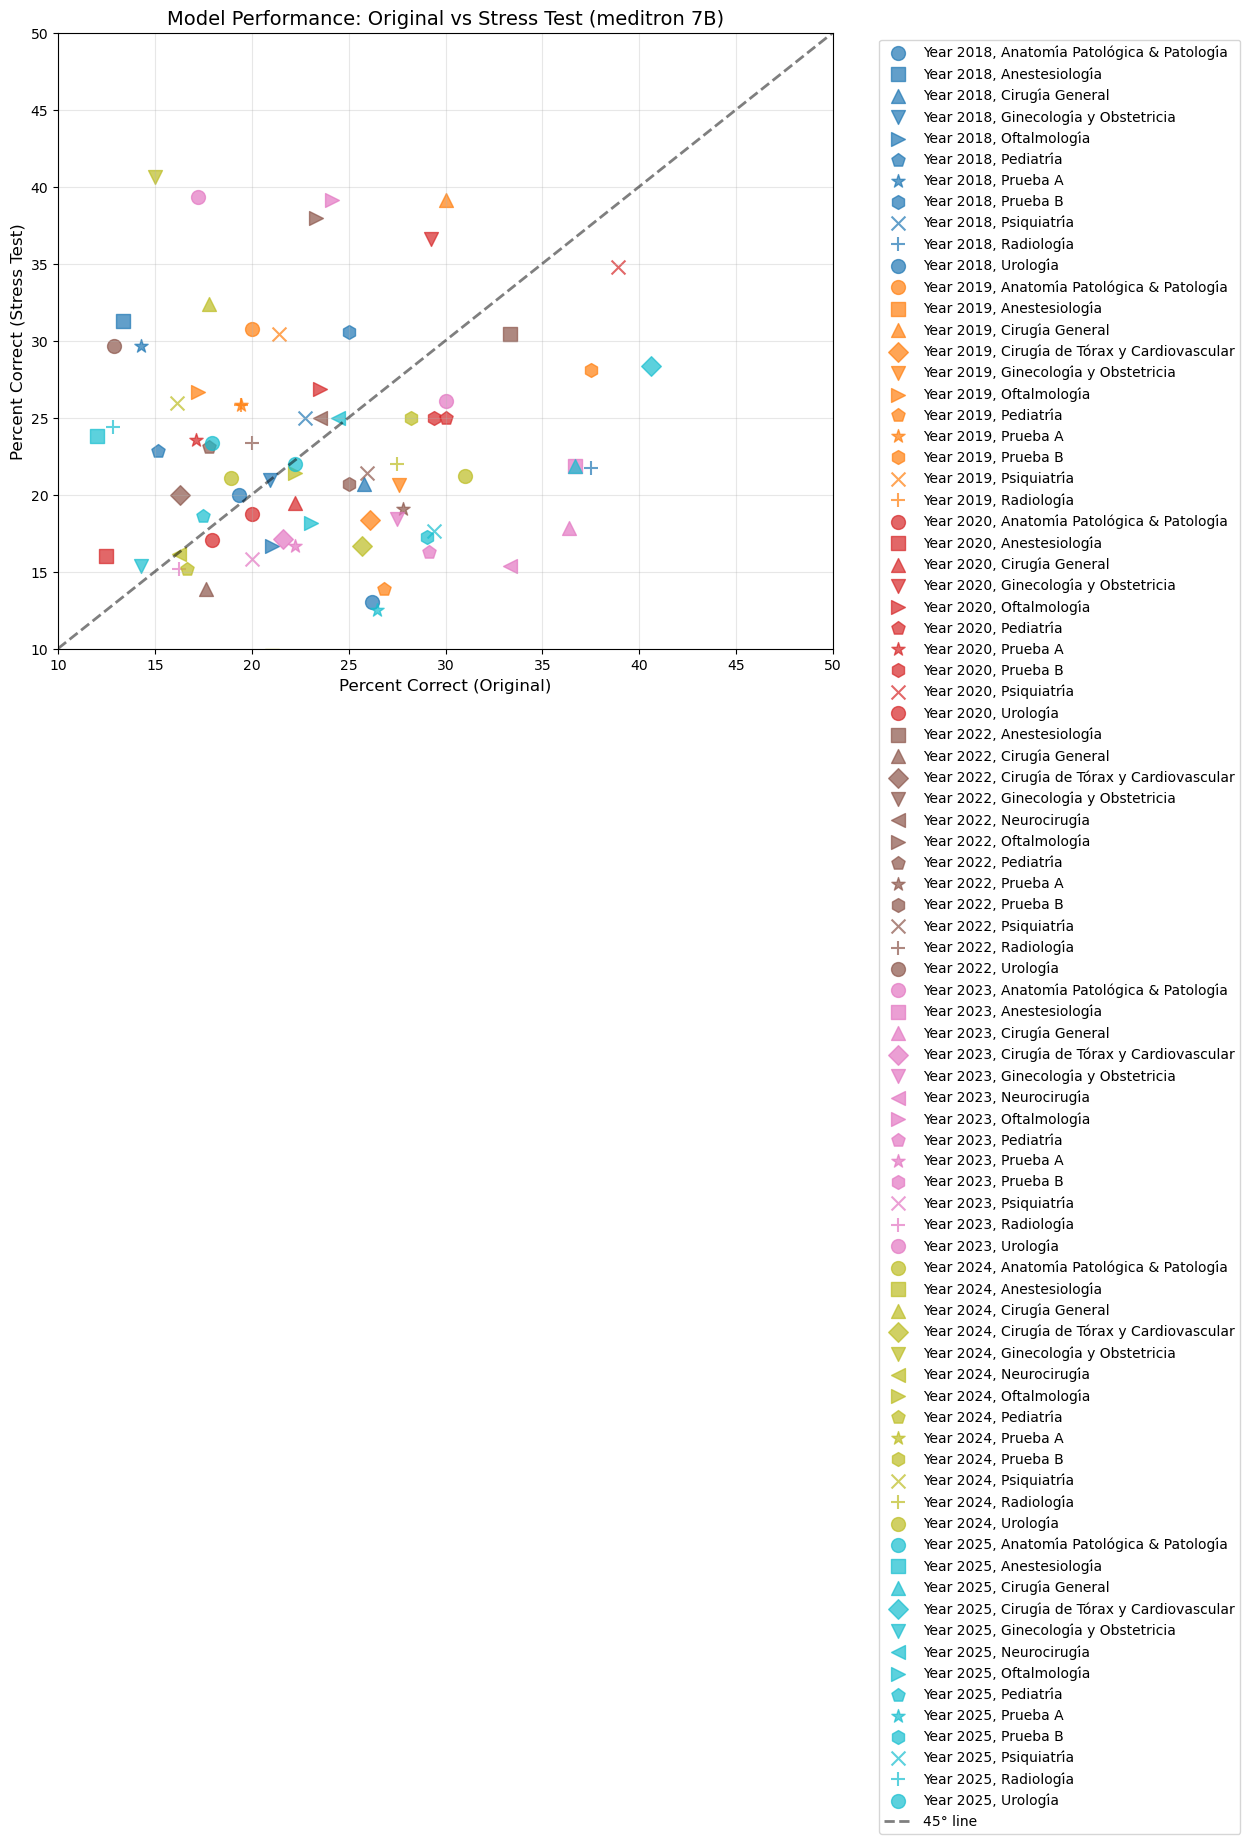

In [10]:
# Define marker styles for source_file
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h', 'x', '+']
marker_cycle = cycle(markers)
marker_map = {source: next(marker_cycle) for source in df_old_new_meditron7b['source_file'].unique()}

# Get unique years and source files
years = sorted(df_old_new_meditron7b['year'].unique())
source_files = sorted(df_old_new_meditron7b['source_file'].unique())

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 8))

# Create a color map for years
colors = plt.cm.tab10(np.linspace(0, 1, len(years)))
color_map = {year: colors[i] for i, year in enumerate(years)}

# Plot points colored by year with markers by source_file
for year in years:
    for source_file in source_files:
        mask = (df_old_new_meditron7b['year'] == year) & (df_old_new_meditron7b['source_file'] == source_file)
        data = df_old_new_meditron7b[mask]
        if len(data) > 0:
            ax.scatter(
                data['percentage_correct_old'],
                data['percentage_correct_new'],
                marker=marker_map[source_file],
                color=color_map[year],
                s=100,
                alpha=0.7,
                label=f"Year {year}, {source_file}"
            )

# Add 45-degree line
ax.plot([10, 100], [10, 100], 'k--', label='45° line', linewidth=2, alpha=0.5)

# Set axis limits and labels
ax.set_xlim(10, 50)
ax.set_ylim(10, 50)
ax.set_xlabel('Percent Correct (Original)', fontsize=12)
ax.set_ylabel('Percent Correct (Stress Test)', fontsize=12)
ax.set_title('Model Performance: Original vs Stress Test (meditron 7B)', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

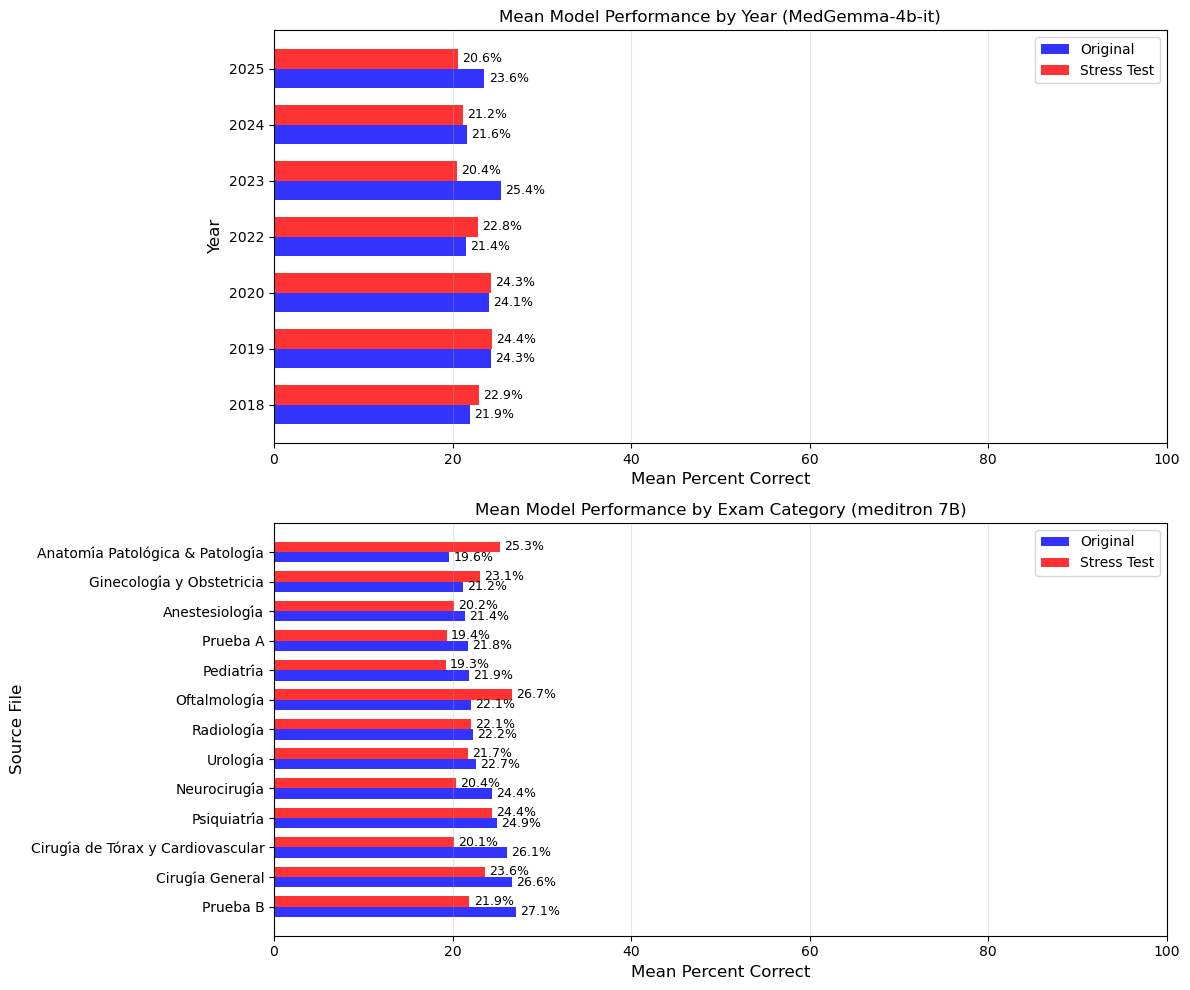

In [11]:
# Bar plot: Mean performance by year
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Group by year and calculate means
year_stats = df_old_new_meditron7b.groupby('year')[['percentage_correct_old', 'percentage_correct_new']].mean()

# Bar plot 1: Mean performance by year
x_pos = np.arange(len(year_stats.index))
width = 0.35

bars_old_year = axes[0].barh(
    x_pos - width/2,
    year_stats['percentage_correct_old'],
    height=width,
    label='Original',
    color='blue',
    alpha=0.8
)
bars_new_year = axes[0].barh(
    x_pos + width/2,
    year_stats['percentage_correct_new'],
    height=width,
    label='Stress Test',
    color='red',
    alpha=0.8
)
axes[0].bar_label(bars_old_year, fmt='%.1f%%', padding=3, fontsize=9)
axes[0].bar_label(bars_new_year, fmt='%.1f%%', padding=3, fontsize=9)
axes[0].set_ylabel('Year', fontsize=12)
axes[0].set_xlabel('Mean Percent Correct', fontsize=12)
axes[0].set_xlim(0, 100)
axes[0].set_title('Mean Model Performance by Year (MedGemma-4b-it)', fontsize=12)
axes[0].set_yticks(x_pos)
axes[0].set_yticklabels(year_stats.index)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='x')

# Bar plot 2: Mean performance by source_file
source_stats = df_old_new_meditron7b.groupby('source_file')[['percentage_correct_old', 'percentage_correct_new']].mean().sort_values('percentage_correct_old', ascending=False)

x_pos = np.arange(len(source_stats.index))
bars_old_source = axes[1].barh(
    x_pos - width/2,
    source_stats['percentage_correct_old'],
    height=width,
    label='Original',
    color='blue',
    alpha=0.8
)
bars_new_source = axes[1].barh(
    x_pos + width/2,
    source_stats['percentage_correct_new'],
    height=width,
    label='Stress Test',
    color='red',
    alpha=0.8
)
axes[1].bar_label(bars_old_source, fmt='%.1f%%', padding=3, fontsize=9)
axes[1].bar_label(bars_new_source, fmt='%.1f%%', padding=3, fontsize=9)
axes[1].set_ylabel('Source File', fontsize=12)
axes[1].set_xlabel('Mean Percent Correct', fontsize=12)
axes[1].set_xlim(0, 100)
axes[1].set_title('Mean Model Performance by Exam Category (meditron 7B)', fontsize=12)
axes[1].set_yticks(x_pos)
axes[1].set_yticklabels(source_stats.index)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

In [12]:
# Prepare data for paired tests
# Remove rows with missing values in either column
data_paired = df_old_new_meditron7b[['percentage_correct_old', 'percentage_correct_new']].dropna()

print("=" * 70)
print("STATISTICAL TESTS: Original vs Stress Test Performance")
print("=" * 70)

# 1. Check normality of differences
differences = data_paired['percentage_correct_new'] - data_paired['percentage_correct_old']
stat_shapiro, p_shapiro = stats.shapiro(differences)
print(f"\n1. NORMALITY TEST (Shapiro-Wilk on differences):")
print(f"   Test Statistic: {stat_shapiro:.4f}")
print(f"   p-value: {p_shapiro:.6f}")
print(f"   Result: {'Data is normally distributed' if p_shapiro > 0.05 else 'Data deviates from normality'} (α=0.05)")

# 2. Paired t-test (parametric)
t_stat, p_ttest = stats.ttest_rel(data_paired['percentage_correct_new'], 
                                   data_paired['percentage_correct_old'])
mean_diff = differences.mean()
std_diff = differences.std()

print(f"\n2. PAIRED T-TEST (parametric):")
print(f"   Mean difference (Stress Test - Original): {mean_diff:.4f}%")
print(f"   Std deviation of differences: {std_diff:.4f}%")
print(f"   t-statistic: {t_stat:.4f}")
print(f"   p-value: {p_ttest:.6f}")
print(f"   Result: {'SIGNIFICANT difference' if p_ttest < 0.05 else 'No significant difference'} (α=0.05)")

# 3. Wilcoxon Signed-Rank Test (non-parametric alternative)
w_stat, p_wilcox = stats.wilcoxon(data_paired['percentage_correct_new'], 
                                    data_paired['percentage_correct_old'])
print(f"\n3. WILCOXON SIGNED-RANK TEST (non-parametric alternative):")
print(f"   W-statistic: {w_stat:.4f}")
print(f"   p-value: {p_wilcox:.6f}")
print(f"   Result: {'SIGNIFICANT difference' if p_wilcox < 0.05 else 'No significant difference'} (α=0.05)")

# 4. Effect size (Cohen's d for paired samples)
cohens_d = mean_diff / std_diff
print(f"\n4. EFFECT SIZE (Cohen's d):")
print(f"   Cohen's d: {cohens_d:.4f}")
if abs(cohens_d) < 0.2:
    effect_interpretation = "negligible"
elif abs(cohens_d) < 0.5:
    effect_interpretation = "small"
elif abs(cohens_d) < 0.8:
    effect_interpretation = "medium"
else:
    effect_interpretation = "large"
print(f"   Interpretation: {effect_interpretation.upper()} effect")

# 5. Descriptive statistics
print(f"\n5. DESCRIPTIVE STATISTICS:")
print(f"   N (paired observations): {len(data_paired)}")
print(f"   Original - Mean: {data_paired['percentage_correct_old'].mean():.2f}%, Std: {data_paired['percentage_correct_old'].std():.2f}%")
print(f"   Stress Test - Mean: {data_paired['percentage_correct_new'].mean():.2f}%, Std: {data_paired['percentage_correct_new'].std():.2f}%")

# Count improvements/declines
improvements = (differences > 0).sum()
declines = (differences < 0).sum()
no_change = (differences == 0).sum()

print(f"\n6. DIRECTION OF CHANGE:")
print(f"   Improved (Stress Test > Original): {improvements} ({100*improvements/len(data_paired):.1f}%)")
print(f"   Declined (Stress Test < Original): {declines} ({100*declines/len(data_paired):.1f}%)")
print(f"   No change: {no_change} ({100*no_change/len(data_paired):.1f}%)")

print("\n" + "=" * 70)
print("RECOMMENDATION:")
print("=" * 70)
if p_shapiro > 0.05:
    print("✓ Data appears normally distributed, paired t-test is appropriate.")
else:
    print("✗ Data deviates from normality. Consider using the Wilcoxon test.")
    print("  Both tests are shown above for comparison.")
print("=" * 70)

STATISTICAL TESTS: Original vs Stress Test Performance

1. NORMALITY TEST (Shapiro-Wilk on differences):
   Test Statistic: 0.9795
   p-value: 0.206726
   Result: Data is normally distributed (α=0.05)

2. PAIRED T-TEST (parametric):
   Mean difference (Stress Test - Original): -0.9387%
   Std deviation of differences: 9.6891%
   t-statistic: -0.8826
   p-value: 0.380027
   Result: No significant difference (α=0.05)

3. WILCOXON SIGNED-RANK TEST (non-parametric alternative):
   W-statistic: 1454.0000
   p-value: 0.252549
   Result: No significant difference (α=0.05)

4. EFFECT SIZE (Cohen's d):
   Cohen's d: -0.0969
   Interpretation: NEGLIGIBLE effect

5. DESCRIPTIVE STATISTICS:
   N (paired observations): 83
   Original - Mean: 23.19%, Std: 6.90%
   Stress Test - Mean: 22.25%, Std: 7.45%

6. DIRECTION OF CHANGE:
   Improved (Stress Test > Original): 34 (41.0%)
   Declined (Stress Test < Original): 48 (57.8%)
   No change: 1 (1.2%)

RECOMMENDATION:
✓ Data appears normally distributed, 

In [13]:
# Stratified analysis by YEAR
print("\n" + "=" * 90)
print("STRATIFIED ANALYSIS BY YEAR")
print("=" * 90)

results_by_year = []

for year in sorted(df_old_new_meditron7b['year'].unique()):
    year_data = df_old_new_meditron7b[df_old_new_meditron7b['year'] == year][['percentage_correct_old', 'percentage_correct_new']].dropna()
    
    if len(year_data) < 2:
        continue
    
    year_diff = year_data['percentage_correct_new'] - year_data['percentage_correct_old']
    t_stat_y, p_ttest_y = stats.ttest_rel(year_data['percentage_correct_new'], year_data['percentage_correct_old'])
    w_stat_y, p_wilcox_y = stats.wilcoxon(year_data['percentage_correct_new'], year_data['percentage_correct_old'])
    cohens_d_y = year_diff.mean() / year_diff.std() if year_diff.std() > 0 else 0
    
    results_by_year.append({
        'Year': year,
        'N': len(year_data),
        'Mean_Diff': year_diff.mean(),
        'Std_Diff': year_diff.std(),
        'T_stat': t_stat_y,
        'P_ttest': p_ttest_y,
        'P_wilcox': p_wilcox_y,
        'Cohens_d': cohens_d_y,
        'Original_Mean': year_data['percentage_correct_old'].mean(),
        'Stress_Mean': year_data['percentage_correct_new'].mean()
    })

results_by_year_df = pd.DataFrame(results_by_year)

print("\nYear-by-Year Summary:")
print("-" * 90)
for idx, row in results_by_year_df.iterrows():
    sig_ttest = "***" if row['P_ttest'] < 0.05 else ""
    sig_wilcox = "***" if row['P_wilcox'] < 0.05 else ""
    print(f"Year {int(row['Year'])} (N={int(row['N'])}):")
    print(f"  Original: {row['Original_Mean']:.2f}% → Stress: {row['Stress_Mean']:.2f}% (Δ = {row['Mean_Diff']:+.2f}%)")
    print(f"  T-test p-value: {row['P_ttest']:.4f} {sig_ttest}  |  Wilcoxon p-value: {row['P_wilcox']:.4f} {sig_wilcox}")
    print(f"  Cohen's d: {row['Cohens_d']:.4f}")
    print()

# Stratified analysis by SOURCE FILE
print("=" * 90)
print("STRATIFIED ANALYSIS BY SOURCE FILE (EXAM CATEGORY)")
print("=" * 90)

results_by_source = []

for source_file in sorted(df_old_new_meditron7b['source_file'].unique()):
    source_data = df_old_new_meditron7b[df_old_new_meditron7b['source_file'] == source_file][['percentage_correct_old', 'percentage_correct_new']].dropna()
    
    if len(source_data) < 2:
        continue
    
    source_diff = source_data['percentage_correct_new'] - source_data['percentage_correct_old']
    t_stat_s, p_ttest_s = stats.ttest_rel(source_data['percentage_correct_new'], source_data['percentage_correct_old'])
    w_stat_s, p_wilcox_s = stats.wilcoxon(source_data['percentage_correct_new'], source_data['percentage_correct_old'])
    cohens_d_s = source_diff.mean() / source_diff.std() if source_diff.std() > 0 else 0
    
    results_by_source.append({
        'Source_File': source_file,
        'N': len(source_data),
        'Mean_Diff': source_diff.mean(),
        'Std_Diff': source_diff.std(),
        'T_stat': t_stat_s,
        'P_ttest': p_ttest_s,
        'P_wilcox': p_wilcox_s,
        'Cohens_d': cohens_d_s,
        'Original_Mean': source_data['percentage_correct_old'].mean(),
        'Stress_Mean': source_data['percentage_correct_new'].mean()
    })

results_by_source_df = pd.DataFrame(results_by_source).sort_values('Original_Mean', ascending=False)

print("\nSource File-by-Source File Summary:")
print("-" * 90)
for idx, row in results_by_source_df.iterrows():
    sig_ttest = "***" if row['P_ttest'] < 0.05 else ""
    sig_wilcox = "***" if row['P_wilcox'] < 0.05 else ""
    print(f"{row['Source_File']} (N={int(row['N'])}):")
    print(f"  Original: {row['Original_Mean']:.2f}% → Stress: {row['Stress_Mean']:.2f}% (Δ = {row['Mean_Diff']:+.2f}%)")
    print(f"  T-test p-value: {row['P_ttest']:.4f} {sig_ttest}  |  Wilcoxon p-value: {row['P_wilcox']:.4f} {sig_wilcox}")
    print(f"  Cohen's d: {row['Cohens_d']:.4f}")
    print()

print("=" * 90)
print("LEGEND: *** indicates p < 0.05 (statistically significant)")
print("=" * 90)


STRATIFIED ANALYSIS BY YEAR

Year-by-Year Summary:
------------------------------------------------------------------------------------------
Year 2018 (N=11):
  Original: 21.94% → Stress: 22.94% (Δ = +1.00%)
  T-test p-value: 0.7583   |  Wilcoxon p-value: 0.6953 
  Cohen's d: 0.0953

Year 2019 (N=11):
  Original: 24.25% → Stress: 24.38% (Δ = +0.13%)
  T-test p-value: 0.9670   |  Wilcoxon p-value: 0.8809 
  Cohen's d: 0.0128

Year 2020 (N=10):
  Original: 24.09% → Stress: 24.30% (Δ = +0.21%)
  T-test p-value: 0.8889   |  Wilcoxon p-value: 1.0000 
  Cohen's d: 0.0454

Year 2022 (N=12):
  Original: 21.45% → Stress: 22.80% (Δ = +1.35%)
  T-test p-value: 0.5672   |  Wilcoxon p-value: 0.9697 
  Cohen's d: 0.1703

Year 2023 (N=13):
  Original: 25.39% → Stress: 20.44% (Δ = -4.95%)
  T-test p-value: 0.1584   |  Wilcoxon p-value: 0.1272 
  Cohen's d: -0.4171

Year 2024 (N=13):
  Original: 21.65% → Stress: 21.18% (Δ = -0.47%)
  T-test p-value: 0.8868   |  Wilcoxon p-value: 0.5417 
  Cohen's d: 